<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</center>
</figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**
### **Tecnicatura en Gestión de Datos (TGAD)**

---

## **Métodos Predictivos para la Gestión**
### **Trabajo Práctico Integrador**

---

**Dataset:** Colorado Real Estate 2026

**Fecha de entrega:** 02/06/2026

**Integrantes:**
1. Alexander Ballera - N° 919064
2. Alma Asmar - N° 919085
3. Alan Baez - N° 919129
4. Guadalupe Benitez - N° 919082

---

##### **Estudio de Mercado Inmobiliario: Colorado 2026**

1. **Introducción y Contexto del Dataset**

Nuestro grupo decidió hacer un análisis del mercado inmobiliario del Estado de Colorado. Para ello, se tomarán en cuenta 8300 propiedades activas para el año 2026.

Elegimos este dataset ya que la cantidad de datos faltantes nos permiten aplicar las técnicas de pretratamiento; esto nos obliga a enfrentarnos con casos semejantes a la realidad y poder así recorrer cada fase indispensable para un análisis profesional y objetivo.

2. **Definición del Modelo de Regresión**

Para este análisis, el objetivo principal es predecir el precio de una propiedad basándonos en sus características físicas y estructurales, por lo que tomaremos como variable dependiente "***listPrice***"

**Justificación**: El precio de lista actúa como el indicador principal de valor en el mercado inmobiliario. En nuestro modelo de regresión lineal, buscaremos entender cómo las variaciones en los metros cuadrados, habitaciones y otras características afectan directamente a esta variable.

3. **Descripción de columnas**

A continuación, se detalla cada variable y su significado para facilitar la comprensión del estudio:

| Columna | Tipo de Dato | Descripción en Español | Relevancia en el Estudio |
|---|---|---|---|
| type / sub_type | String | Clasificación de la propiedad (Casa, Condominio, Townhouse, etc.). | Identificación de segmentos de mercado. |
| text | String | Descripción publicitaria y resumen de la propiedad. | Fuente para extracción de variables mediante NLP. |
| listPrice | Float | Variable Objetivo (Y): Precio de venta solicitado. | Centro del análisis de regresión. |
| sqft | Float | Superficie total construida en pies cuadrados. | Predictor principal (correlación fuerte con el precio). |
| stories | Float | Número de niveles o pisos de la construcción. | Variable de control estructural. |
| beds | Float | Cantidad total de dormitorios. | Predictor de capacidad y tamaño familiar. |
| baths / baths_full / baths_full_calc | Float | Conteo total de baños. | Indicador de comodidad y lujo. |
| garage | Float | Capacidad de estacionamiento o plazas de cochera. | Factor de valor añadido en zonas urbanas. |

<a id="carga"></a>
## 🔧 SECCIÓN 0: Carga y Configuración Inicial

En esta sección cargamos las librerías necesarias y el dataset.

In [ ]:
# Instala la librería para optimización bayesiana en el entorno de Colab
!pip install scikit-optimize --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.7 MB/s eta 0:00:00


### Importar librerías necesarias

In [ ]:
# Librerías a utilizar

# Manipulación de datos
import pandas as pd
import numpy as np

# Gráficos
import seaborn as sns
import matplotlib.pyplot as plt

# Regresiones lineales
import statsmodels.api as sm # para correlación parcial
import statsmodels.formula.api as smf # para regresión lineal múltiple

# Base de datos
import kagglehub

# Pretratamiento de datos
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Estadistica descriptiva
from scipy.stats import skew, kurtosis, zscore

# Herramientas de ML
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real

# Para que no haya warnings
import warnings
warnings.filterwarnings('ignore')

### Cargar el dataset

In [ ]:
# Cargar el archivo colorado_real_estate_2026.csv
def carga_archivo(url: str, name: str) -> str:
  # Descarga del dataset
  path = kagglehub.dataset_download(url)
  path = path + name
  return path

# dirección del dataset
url = "kanchana1990/colorado-real-estate-market-2026"
name = "/colorado_real_estate_2026.csv"

# obtención de datos
dataset_raw = pd.read_csv(carga_archivo(url, name))


100%|██████████| 3.13M/3.13M [00:00<00:00, 127MB/s]

Extracting files...


### Vista preliminar de los datos

In [ ]:
# Mostrar las primeras filas del dataset
dataset_raw.head(10)


,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
0,single_family,NaN,Beautifully maintained and spacious brick ranc...,479000,2492.0,1.0,4.0,3.0,1.0,2.0,2.0
1,single_family,NaN,"$150, 000 PRICE CUT! And it still comes with a...",425000,3140.0,3.0,4.0,5.0,4.0,4.0,1.0
2,single_family,NaN,Located on a quiet cul-de-sac in the desirable...,390000,2132.0,1.0,4.0,2.0,2.0,2.0,2.0
3,condos,condo,"3 bedroom, 3 bathroom Aspen Hills condo. LIST ...",100000,1328.0,2.0,3.0,3.0,2.0,2.0,1.0
4,townhomes,townhouse,Welcome to this beautiful townhome in Ridgevie...,375000,1615.0,2.0,3.0,3.0,1.0,2.0,2.0
5,condos,condo,Welcome Home REMARKABLE OPPORTUNITY You Won't ...,239000,1177.0,1.0,3.0,2.0,1.0,2.0,NaN
6,single_family,NaN,The mountains are calling... and you can actua...,840000,4462.0,2.0,4.0,3.0,2.0,3.0,3.0
7,single_family,NaN,Located in the desirable Hansen Farm community...,634900,1635.0,1.0,3.0,2.0,2.0,2.0,3.0
8,single_family,NaN,"Under expansive Colorado dark skies, this beau...",525000,1152.0,1.0,2.0,2.0,NaN,2.0,NaN
9,single_family,NaN,"Beautifully updated 3 bed, 2 bath home with a ...",435000,2016.0,1.0,3.0,2.0,2.0,2.0,2.0


---
<a id="preguntas-obligatorias"></a>
## 📝 SECCIÓN 1: Preguntas Obligatorias

Esta sección responde a las preguntas obligatorias del trabajo práctico antes de iniciar el análisis formal.

### 1.1 Exploración de la Identidad y el Contexto

**Antes de mirar los datos, hay que entender de dónde vienen.**

#### ¿Cuál es la fuente de los datos?

Describir: ¿Es una base gubernamental, un registro de una empresa, una simulación o una encuesta?

In [ ]:
# Descripción de la fuente de datos
# El dataset "Colorado Real Estate Market 2026"
# Proporciona información sobre el mercado inmobiliario en Colorado para el año 2026.
# Es una base de Kaggle, lo que sugiere que ha sido recopilada y compartida por un usuario de la plataforma.


#### ¿Qué representa cada fila (observación)?

Describir: ¿Es un cliente, un día de ventas, un paciente, una propiedad inmobiliaria?

In [ ]:
# Descripción de lo que representa cada observación
# Cada observación en el dataset representa una propiedad inmobiliaria en Colorado durante el año 2026.
# Cada fila contiene información sobre características específicas de la propiedad,
# como su superficie total construida en pies cuadrados, cantidad de pisos, cantidad de dormitorios,
# cantidad de baños, precio de venta, entre otros atributos relevantes para el análisis del mercado inmobiliario.


#### ¿En qué período de tiempo se recolectaron?

Describir: ¿Son datos actuales o históricos? ¿Podría haber factores externos que puedan haber sesgado este período?

In [ ]:
# Análisis del período temporal de los datos
# Este conjunto de datos recopila listados de propiedades activas de 2026
# de las principales plataformas inmobiliarias de EE. UU.,
# principalmente de Realtor.com, Zillow y Redfin,
# para garantizar una visión integral del mercado en múltiples plataformas.
# Son datos recientes, lo que los hace relevantes para el análisis actual del mercado inmobiliario en Colorado.

---
### 1.2 Inventario y Tipología de Variables

#### ¿Cuántas variables (columnas) tienen y de qué tipo son?

Clasificarlas en cualitativas (nominales/ordinales) y cuantitativas (discretas/continuas).

In [ ]:
# Cantidad de filas y columnas
filas, columnas = dataset_raw.shape
print(f"El dataset tiene {filas} filas y {columnas} columnas.")

El dataset tiene 8362 filas y 11 columnas.


In [ ]:
# Información sobre tipos de datos
tipos_datos = dataset_raw.dtypes
print("\nTipos de datos por columna:")
print(tipos_datos)


Tipos de datos por columna:
type                object
sub_type            object
text                object
listPrice            int64
sqft               float64
stories            float64
beds               float64
baths              float64
baths_full         float64
baths_full_calc    float64
garage             float64
dtype: object


In [ ]:
# Clasificación de variables por tipo
# type: cualitativa - nominal
# sub_type: cualitativa - nominal
# text: cualitativa - nominal
# listPrice: cuantitativa - continua
# sqft: cuantitativa - continua
# stories: cuantitativa - discreta
# beds: cuantitativa - discreta
# baths: cuantitativa - discreta
# baths_full: cuantitativa - discreta
# baths_full_calc: cuantitativa - discreta
# garage: cuantitativa - discreta


#### ¿Cuál es la variable "Target" (objetivo)?

Si es numérica → regresión. Si es categórica → clasificación.

In [ ]:
# Identificación de la variable objetivo
# La variable objetivo es "listPrice", que representa el precio de venta de la propiedad.
# Es una variable cuantitativa continua, lo que la hace adecuada para análisis de regresión y predicción de precios en el mercado inmobiliario.


#### ¿Qué rango tienen las variables numéricas?

¿Están en escalas muy diferentes? Esto indicará si necesitan estandarizar o normalizar.

In [ ]:
# Rangos de variables numéricas

# Calculo el rango para cada columna numerica del dataset para hacerme una idea de los valores
for columna in ['listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage']:
    min_val, max_val = dataset_raw[columna].agg(['min', 'max'])
    print(f"Rango de {columna}: {min_val} - {max_val}")


Rango de listPrice: 1 - 45000000
Rango de sqft: 273.0 - 39558.0
Rango de stories: 1.0 - 7.0
Rango de beds: 0.0 - 48.0
Rango de baths: 0.0 - 28.0
Rango de baths_full: 1.0 - 28.0
Rango de baths_full_calc: 1.0 - 28.0
Rango de garage: 0.0 - 66.0


Al analizar los rangos, se observa que las variables se encuentran en escalas marcadamente diferentes (mientras listPrice y sqft operan en magnitudes de millones y miles respectivamente, beds y baths se expresan en unidades simples). De cara a la aplicación de modelos sensibles a la escala, como k-NN o determinar importancia de variables en la Regresión Lineal, se hace presente la necesidad de aplicar Estandarización (StandardScaler) sobre los predictores numéricos para evitar el sesgo por magnitud y permitir la comparabilidad de los coeficientes. Asimismo, debido al sesgo y amplio rango del target (listPrice), se evaluará una transformación logarítmica para el modelado lineal.

Por otro lado, con este simple acercamiento para entender los datos, ¡Vemos que aparece el valor de usd 1 como valor de una propiedad! Esto es absurdo y se deberá ajustar con un pretratamiento adecuado más adelante.

---
### 1.3 Identificación de "Ruido" y Variables No Informativas

**No todo lo que está en el dataset sirve para predecir.**

#### ¿Existen variables de identificación única?

IDs, Nombres, Números de DNI. ¿Tienen algún poder predictivo o deben ser eliminadas?

In [ ]:
# Identificar variables de ID único
# No existen variables de ID único en el dataset, ya que no hay columnas que contengan identificadores únicos para cada propiedad.


#### ¿Hay variables con varianza cero?

Una columna donde todos los registros dicen lo mismo. ¿Aporta algo al modelo si no hay variabilidad?

In [ ]:
# Detectar variables con varianza cero o casi cero
# Reviso si existen más de un valor en las columnas categoricas, ya que si no es así, no aportan información para el análisis
for columna in ['type', 'sub_type', 'text']:
    valores_unicos = dataset_raw[columna].nunique()
    print(f"Columna '{columna}' tiene {valores_unicos} valores únicos.")

# Se observa que todos los tipos de datos a simple vista parecen ser adecuados,
# ya que tienen variabilidad (no hay una columna entera con un solo valor)

Columna 'type' tiene 9 valores únicos.
Columna 'sub_type' tiene 2 valores únicos.
Columna 'text' tiene 8187 valores únicos.


#### ¿Existen variables redundantes?

¿Hay dos columnas que digan lo mismo en distinto formato? ¿Cuál conviene conservar?

In [ ]:
# Identificar variables altamente correlacionadas (posible redundancia)

# Se identifican posibles redundancias entre type y sub_type, ya que ambos parecen describir el tipo de propiedad.
# Por otro lado se observan posibles redundancias entre baths, baths_full y baths_full_calc, ya que todas parecen describir la cantidad de baños de la propiedad.
# Es posible que sqft y beds también estén correlacionados, ya que propiedades con más metros cuadrados suelen tener más dormitorios.
# Luego de hacer el analisis descriptivo de los datos, se revisarán estas sospechas iniciales de los datos.

---
### 1.4 Definición del Problema y Encuadre del Enfoque

**Transformar los datos en una pregunta de negocio o investigación.**

#### ¿Qué pregunta intentan responder con estos datos?

In [ ]:
# Definición de la pregunta de investigación
# ¿Podemos predecir el precio de una propiedad basándonos en sus características?

#### ¿Cuál es el "dolor" o la necesidad que resuelve su modelo?

¿Quién usaría esta información y para qué tomaría una decisión basada en ella?

In [ ]:
# Descripción del valor de negocio del modelo
# El valor de negocio de este modelo radica en su capacidad para ayudar a compradores, vendedores e inversores a tomar decisiones informadas en el mercado inmobiliario.
# Para los compradores, el modelo puede proporcionar estimaciones precisas del valor de una propiedad, lo que les permite negociar mejor y evitar pagar de más.
# Para los vendedores, el modelo puede ayudar a establecer precios competitivos que atraigan a los compradores sin subestimar el valor de la propiedad.
# Para los inversores, el modelo puede identificar oportunidades de inversión al predecir el valor futuro de las propiedades basándose en sus características actuales y tendencias del mercado.


#### ¿Cuál es su hipótesis inicial?

¿Qué variables creen, a priori, que serán las más importantes para explicar el fenómeno?

In [ ]:
# Hipótesis sobre las variables más importantes
# Se espera que las variables más importantes para predecir el precio de una propiedad sean:
# 1. type: El tipo de propiedad, ya que diferentes tipos de propiedades (casa, departamento, etc.) pueden tener diferentes rangos de precios.
# 2. sqft: La superficie total construida en pies cuadrados, ya que generalmente a mayor tamaño, mayor precio.
# 3. beds: La cantidad de dormitorios, ya que suele estar relacionada con el tamaño y la funcionalidad de la propiedad.
# 4. baths: La cantidad de baños, ya que es un factor importante para los compradores y suele influir en el precio de la propiedad.
# 5. stories: La cantidad de pisos, ya que puede influir en la percepción de la propiedad y su valor.
# 6. garage: La cantidad de espacios de estacionamiento, ya que es un factor relevante para muchos compradores y puede influir en el precio de la propiedad.


---
<a id="preprocesamiento"></a>
## 🧹 SECCIÓN 2: i) Selección de Datos y Preprocesamiento (Unidad 2)

### 2.1 Selección del Dataset

El dataset seleccionado es **colorado_real_estate_2026.csv** con información de propiedades inmobiliarias en Colorado.

**Requisitos:**
- Mínimo 10,000 observaciones
- No menos de 10 variables para analizar
- Variable objetivo definida (numérica para regresión o categórica para clasificación)

In [ ]:
# Verificar que el dataset cumple con los requisitos mínimos
dataset_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8362 entries, 0 to 8361
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             8362 non-null   object 
 1   sub_type         1564 non-null   object 
 2   text             8323 non-null   object 
 3   listPrice        8362 non-null   int64  
 4   sqft             5977 non-null   float64
 5   stories          4544 non-null   float64
 6   beds             5998 non-null   float64
 7   baths            7082 non-null   float64
 8   baths_full       5768 non-null   float64
 9   baths_full_calc  5969 non-null   float64
 10  garage           4543 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 718.7+ KB


---
### 2.2 Limpieza de Datos

En esta sección identificamos y tratamos los problemas de calidad de datos.

#### 2.2.1 Identificación de valores faltantes

#####  ¿Qué porcentaje de datos faltantes (NaN) tiene cada columna?

Si una columna tiene el 90% de datos vacíos, ¿vale la pena intentar completarla o es mejor descartarla?

In [ ]:
# Identificar valores faltantes por columna
faltantes_columnas = dataset_raw.isnull().sum()
faltantes_total = faltantes_columnas.sum()
print("Valores faltantes por columna:")
print("-"*50)
print(faltantes_columnas)
print("-"*50)
print("Total de valores faltantes en el dataset:", faltantes_total)

Valores faltantes por columna:
--------------------------------------------------
type                  0
sub_type           6798
text                 39
listPrice             0
sqft               2385
stories            3818
beds               2364
baths              1280
baths_full         2594
baths_full_calc    2393
garage             3819
dtype: int64
--------------------------------------------------
Total de valores faltantes en el dataset: 25490


In [ ]:
# Porcentaje de datos faltantes por columna
porcentaje_faltantes = (faltantes_columnas / len(dataset_raw) * 100).round(2)
porcentaje_faltantes = porcentaje_faltantes.astype(str) + '%'
print(porcentaje_faltantes)

type                 0.0%
sub_type            81.3%
text                0.47%
listPrice            0.0%
sqft               28.52%
stories            45.66%
beds               28.27%
baths              15.31%
baths_full         31.02%
baths_full_calc    28.62%
garage             45.67%
dtype: object


In [ ]:
# Visualizar el patrón de valores faltantes
# Se observa que la columna sub_type tiene un porcentaje significativo de valores faltantes
# Por lo tanto, se deberá analizar si es necesario eliminar esta columna o imputar los valores faltantes, dependiendo de su importancia para el análisis y la cantidad de datos disponibles.
# Se sosprecha colinealidad entre sub_type y type, por lo que se analizará la importancia de cada una de estas variables para decidir cuál conservar en el análisis.

##### Alexander (split 1)

#### 2.2.2 Tratamiento de valores faltantes

Decisión: ¿imputación o eliminación? Justificar la estrategia elegida.

**Decisiones de pretratamiento de datos**
- **Eliminación de columna `sub_type` :** La variable carece de más del 80% de sus registros, la introducción de sesgos es casi inevitable. Si intentáramos imputarla (completarla), estaríamos "inventando" el 81.3% de la información basándonos únicamente en un 18.7% visible. Si ese 18.7% no es una muestra aleatoria perfecta del total (es decir, si los datos no son Missing Completely at Random - MCAR), cualquier método de imputación replicará y amplificará un sesgo de selección insostenible para un modelo predictivo.
- **Eliminación de columna `text` :** Se procede a descartar esta columna del análisis en base a los siguientes fundamentos:

  *   **Naturaleza no estructurada:** La variable contiene texto libre (descripciones comerciales de los inmuebles) que no puede ser procesado directamente por modelos matriciales como la Regresión Lineal (OLS) o algoritmos basados en árboles de decisión sin una transformación previa mediante técnicas avanzadas de NLP (Procesamiento del Lenguaje Natural), las cuales exceden el encuadre de este trabajo.
  *   **Información redundante:** El contenido analítico relevante presente en el texto (como la cantidad de ambientes o dimensiones) ya se encuentra capturado de forma estructurada en las variables `beds`, `baths` y `sqft`.
  *   **Sesgo comercial:** Al tratarse de textos publicitarios orientados al marketing inmobiliario, predomina el uso de adjetivos subjetivos que introducen una alta variabilidad no informativa (ruido).
- **Imputación por _KNN_ :** Para el tratamiento de los registros faltantes en las demás variables predictoras del inmueble (como sqft, beds o baths), se opta por una Imputación por $k$-Vecinos Más Cercanos ($k$-NN Imputer) en lugar de recurrir a medidas de tendencia central globales (media o mediana) por dos razones:

  1.  **Preservación de la Coherencia Estructural del Mercado Inmobiliario:** Las características de las propiedades no se comportan según el promedio general de una región entera, sino que presentan una fuerte dependencia local y correlacional multivariada. El algoritmo $k$-NN permite capturar esta lógica de negocio al estimar los vacíos basándose exclusivamente en observaciones que comparten un perfil predictivo similar (por ejemplo, imputar los metros cuadrados faltantes evaluando propiedades con valores de lista y número de ambientes equivalentes).
  2.   **Mitigación del Sesgo en la Inferencia de la Regresión Lineal:** La sustitución masiva por la media o mediana contrae artificialmente la varianza original y altera la distribución de los datos, concentrando un "pico" ficticio en el centro, por lo tanto, altera los errores estándar en la regresión (OLS) y nos haría concluir falsamente que una variable es importante cuando no lo es.


In [ ]:
# Estrategia de tratamiento de valores faltantes
# Opción 1: Eliminación (listwise deletion)
# Opción 2: Imputación por media/mediana/moda
# Opción 3: Imputación avanzada (KNN, regresión)

# Antes que nada hacemos una copia del dataset original (buena práctica)
df = dataset_raw.copy()

# Procedemos a usar las opciones 1 y 3 para el pretratamiento de datos
# Se eliminan las columnas sub_type y text
df.drop(columns = ['sub_type', 'text'], inplace = True)

# Luego se procede a realizar las imputaciones por KNN en las demás variables
# Como tenemos pensado usar la columna 'type',
# Al ser una variable categorica es necesario generar dummies para la imputación
df = pd.get_dummies(df, columns=['type'], prefix='type', dtype=float)

# Verificamos que la columna 'type' haya desaparecido
# y si se añadieron las 9 variaciones de dicha variable
df.head()


,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,type_apartment,type_condos,type_duplex_triplex,type_farm,type_land,type_mobile,type_multi_family,type_single_family,type_townhomes
0,479000,2492.0,1.0,4.0,3.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,425000,3140.0,3.0,4.0,5.0,4.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,390000,2132.0,1.0,4.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,100000,1328.0,2.0,3.0,3.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,375000,1615.0,2.0,3.0,3.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Guardamos la lista de nombres de las dummies creadas para el KNN
# Buscamos todas las columnas que empiecen con 'type_'
columnas_dummies = [col for col in df.columns if col.startswith('type_')]

# Reviso si estan bien las columnas seleccionadas
columnas_dummies

['type_apartment',
 'type_condos',
 'type_duplex_triplex',
 'type_farm',
 'type_land',
 'type_mobile',
 'type_multi_family',
 'type_single_family',
 'type_townhomes']

In [ ]:
# Definimos las columnas cuantitativas y las estandarizamos
columnas_numericas = ['sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage']
scaler = StandardScaler()
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

# Visualizamos la normalización
df[columnas_numericas].head()

,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
0,0.059463,-1.007383,0.442623,0.314657,-0.927784,-0.403199,-0.126670
1,0.442877,1.915701,0.442623,1.484423,1.508388,1.180152,-0.612703
2,-0.153545,-1.007383,0.442623,-0.270225,-0.115727,-0.403199,-0.126670
3,-0.629263,0.454159,-0.203484,0.314657,-0.115727,-0.403199,-0.612703
4,-0.459448,0.454159,-0.203484,0.314657,-0.927784,-0.403199,-0.126670


In [ ]:
# Consolidamos el set de predictores para el KNN (excluyendo 'listPrice')
variables_para_knn = columnas_numericas + columnas_dummies

# Imputación por KNN
# La cantidad de vecinos cercanos que debe cumplir se elige en 5 porque sí
# Después se deberá chequear mediante gráficos si fue una buena decisión
imputer = KNNImputer(n_neighbors=5)
df[variables_para_knn] = imputer.fit_transform(df[variables_para_knn])

# Desestandarización para recuperar escalas originales (esencial para la Regresión OLS)
df[columnas_numericas] = scaler.inverse_transform(df[columnas_numericas])

# Redondeo lógico de variables discretas
variables_discretas = columnas_numericas[1:]
df[variables_discretas] = df[variables_discretas].round()

# Preprocesamiento finalizado
df.head()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,type_apartment,type_condos,type_duplex_triplex,type_farm,type_land,type_mobile,type_multi_family,type_single_family,type_townhomes
0,479000,2492.0,1.0,4.0,3.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,425000,3140.0,3.0,4.0,5.0,4.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,390000,2132.0,1.0,4.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,100000,1328.0,2.0,3.0,3.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,375000,1615.0,2.0,3.0,3.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Verificamos que ya no existen nulos
df.isnull().sum()

,0
listPrice,0
sqft,0
stories,0
beds,0
baths,0
baths_full,0
baths_full_calc,0
garage,0
type_apartment,0
type_condos,0


### **Evaluación Comparativa del Impacto de la Imputación en la Estructura de los Datos**

Con el propósito de validar empíricamente la robustez de la imputación multivariada mediante $k$-Vecinos Más Cercanos (`KNNImputer`) compararemos con las siguientes alternativas de limpieza:

1. **Eliminación Completa - `dropna`:** Representa la distribución real de las observaciones efectivamente capturadas por el dataset, sirviendo como nuestra línea de base bajo el supuesto de pérdida aleatoria.
2. **Imputación Univariada Simple - `media, mediana y moda`:** Representa el enfoque tradicional donde cada valor faltante es sustituido de forma estática por alguna de las medidas de tendencia central.

A través de histogramas, auditaremos de manera crítica cómo cada método afecta la distribución. Esta validación es un prerrequisito para garantizar un mejor ajuste en la regresión lineal

#### Algunas aclaraciones
Para variables continuas (como sqft), la imputación por moda no tiene

*   Para variables continuas (como sqft), la imputación por moda no tiene sentido matemático ni práctico, ya que al haber tantos valores decimales o únicos distintos (más de 2.900 valores únicos), la frecuencia de cada número es casi siempre 1.

*   Por lo tanto, para sqft omitiremos la moda para no ensuciar el gráfico, pero la mantendremos y analizaremos en las variables discretas (como beds, baths, o garage), donde sí tiene un peso real por ser conteos de categorías bien definidas.

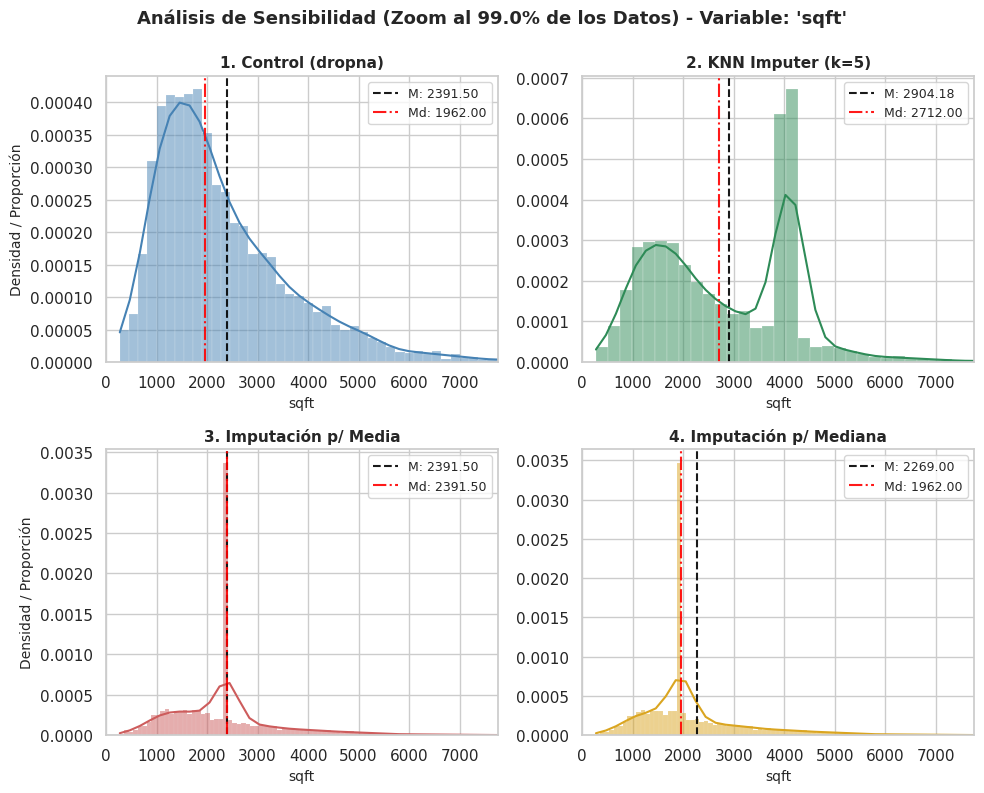

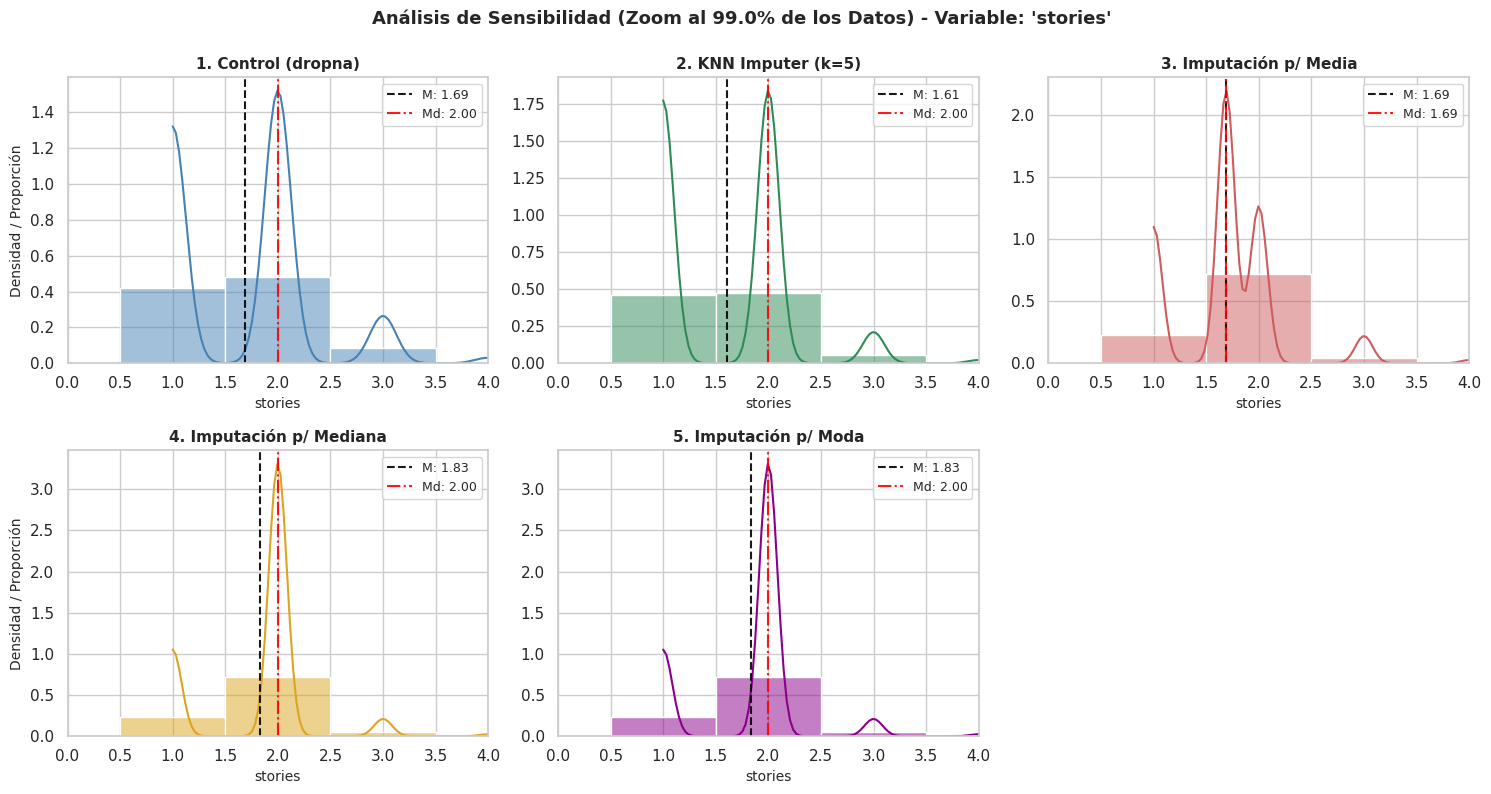

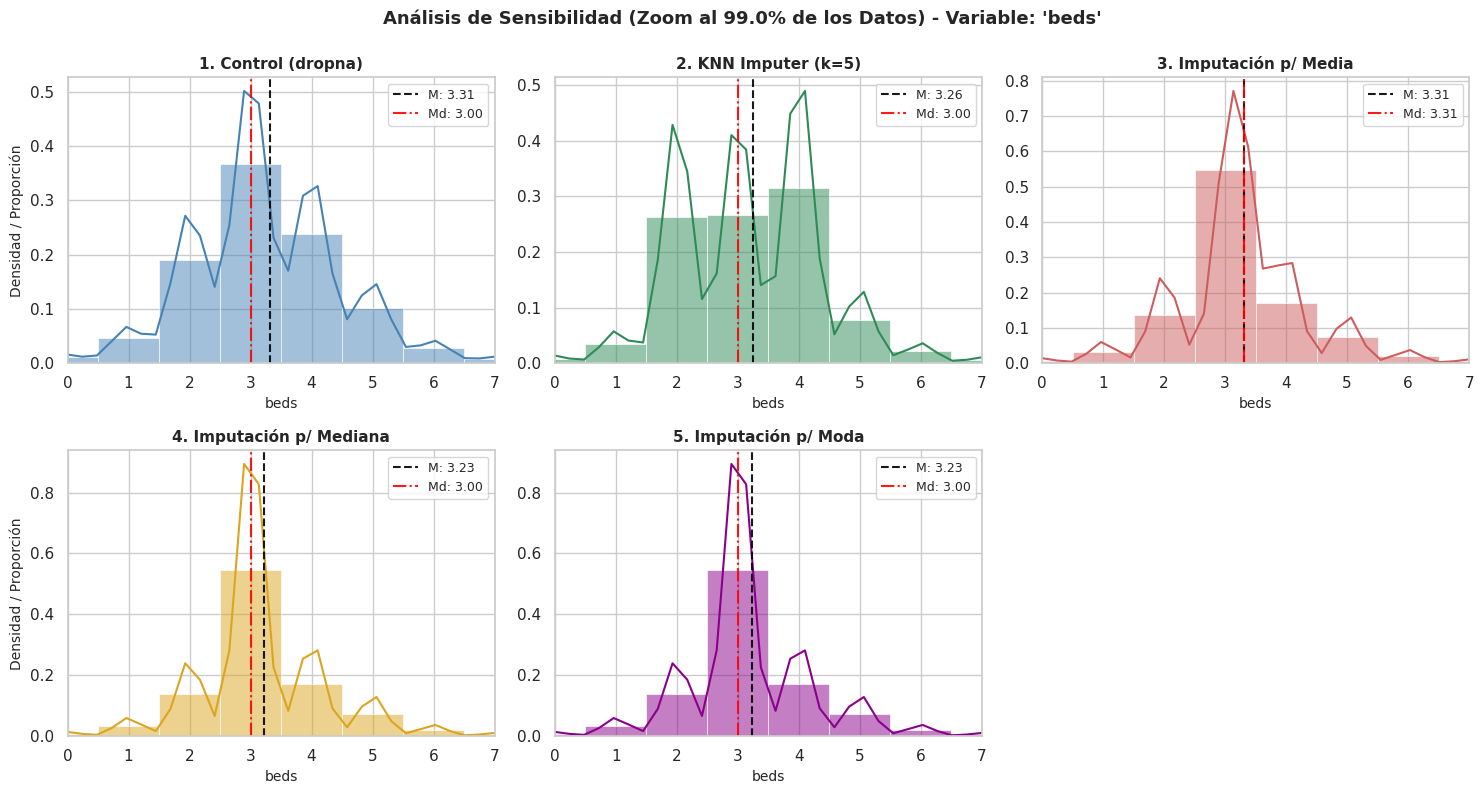

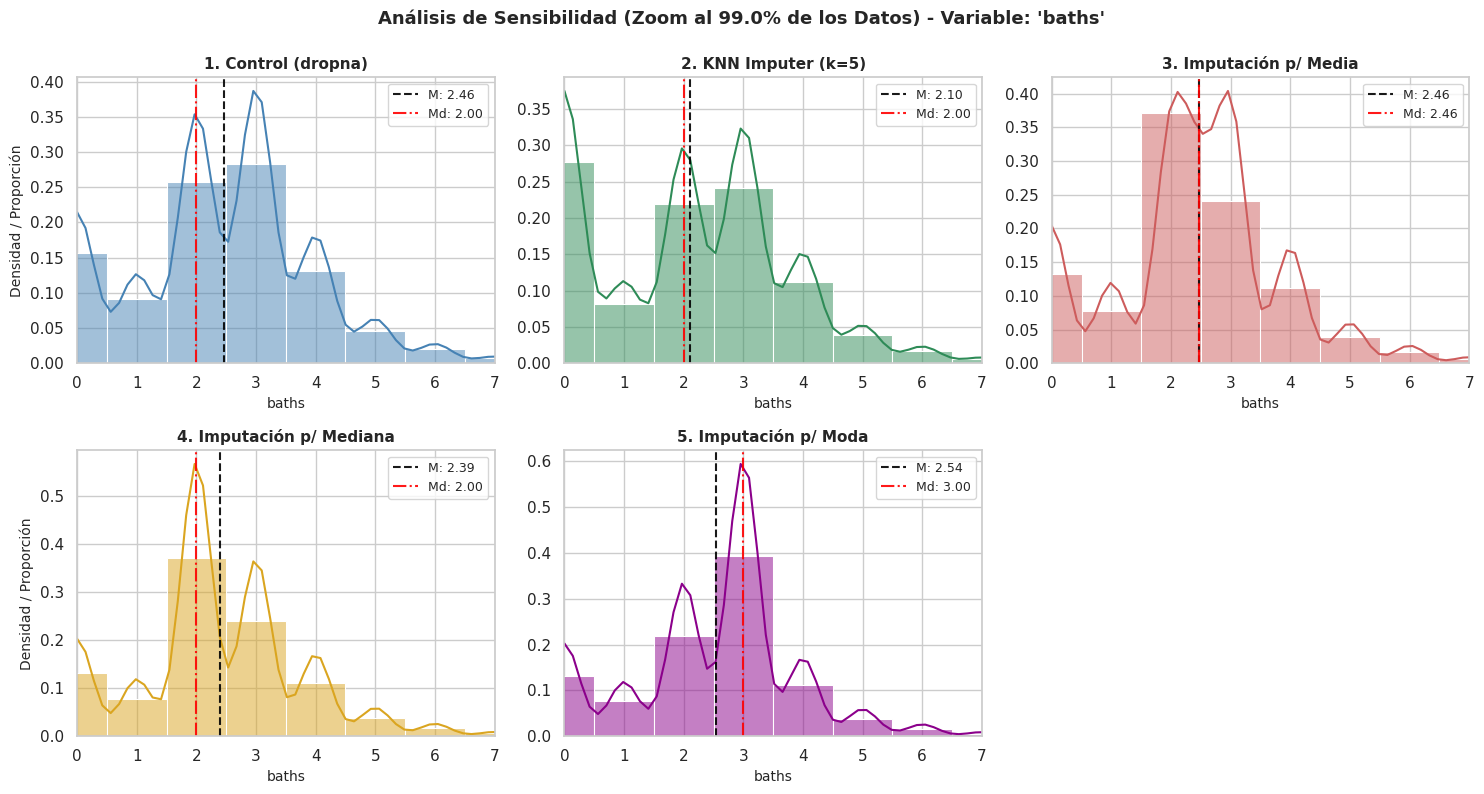

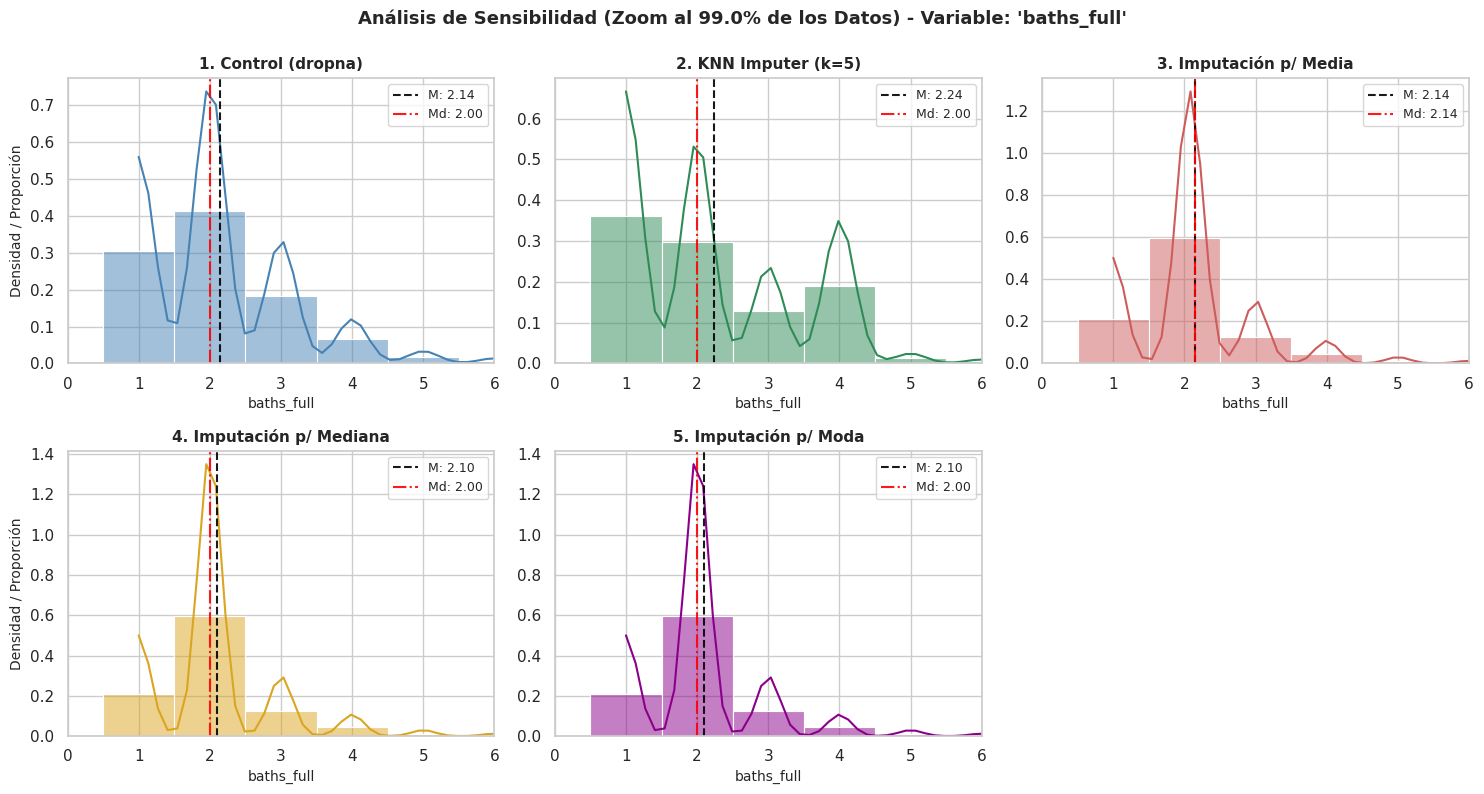

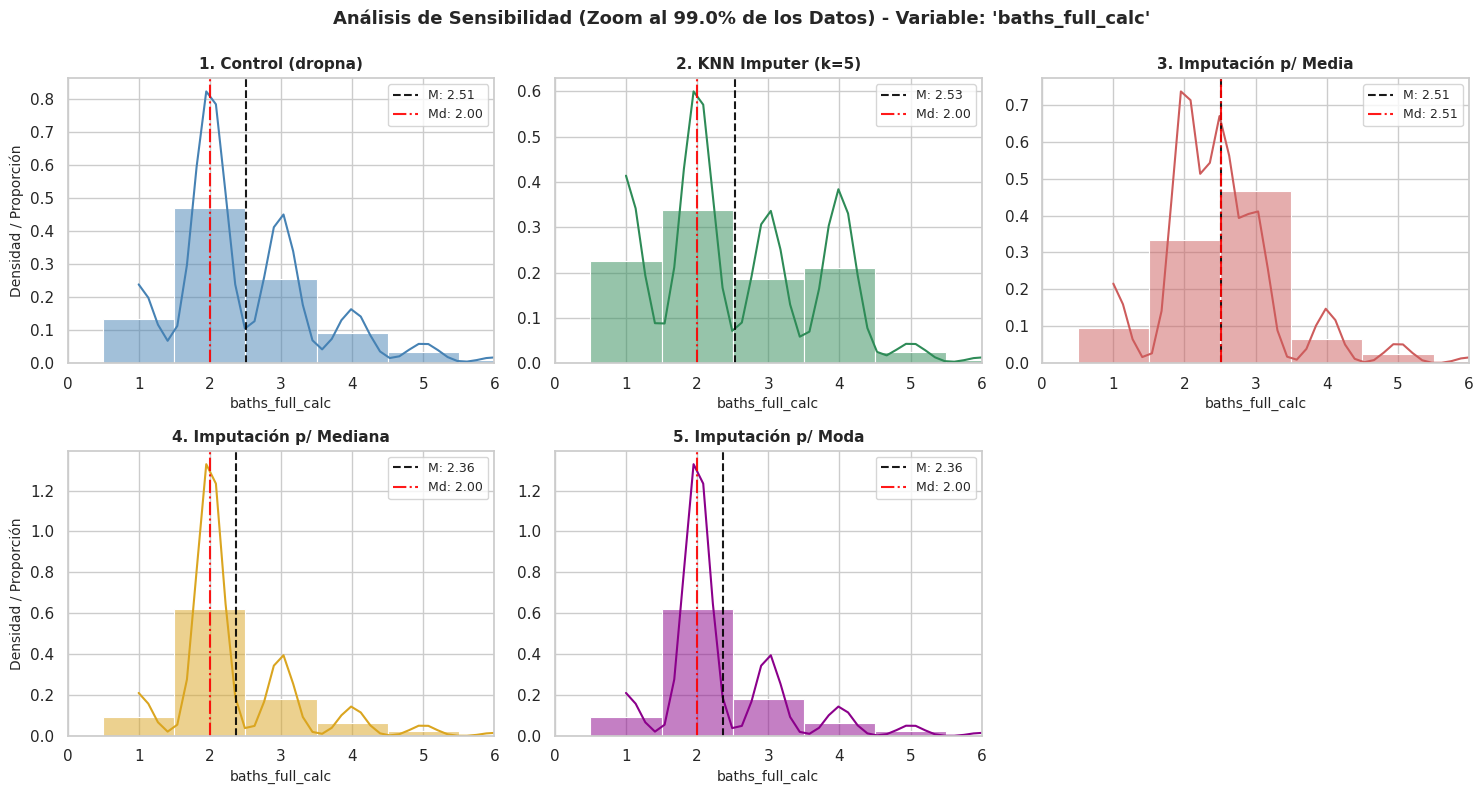

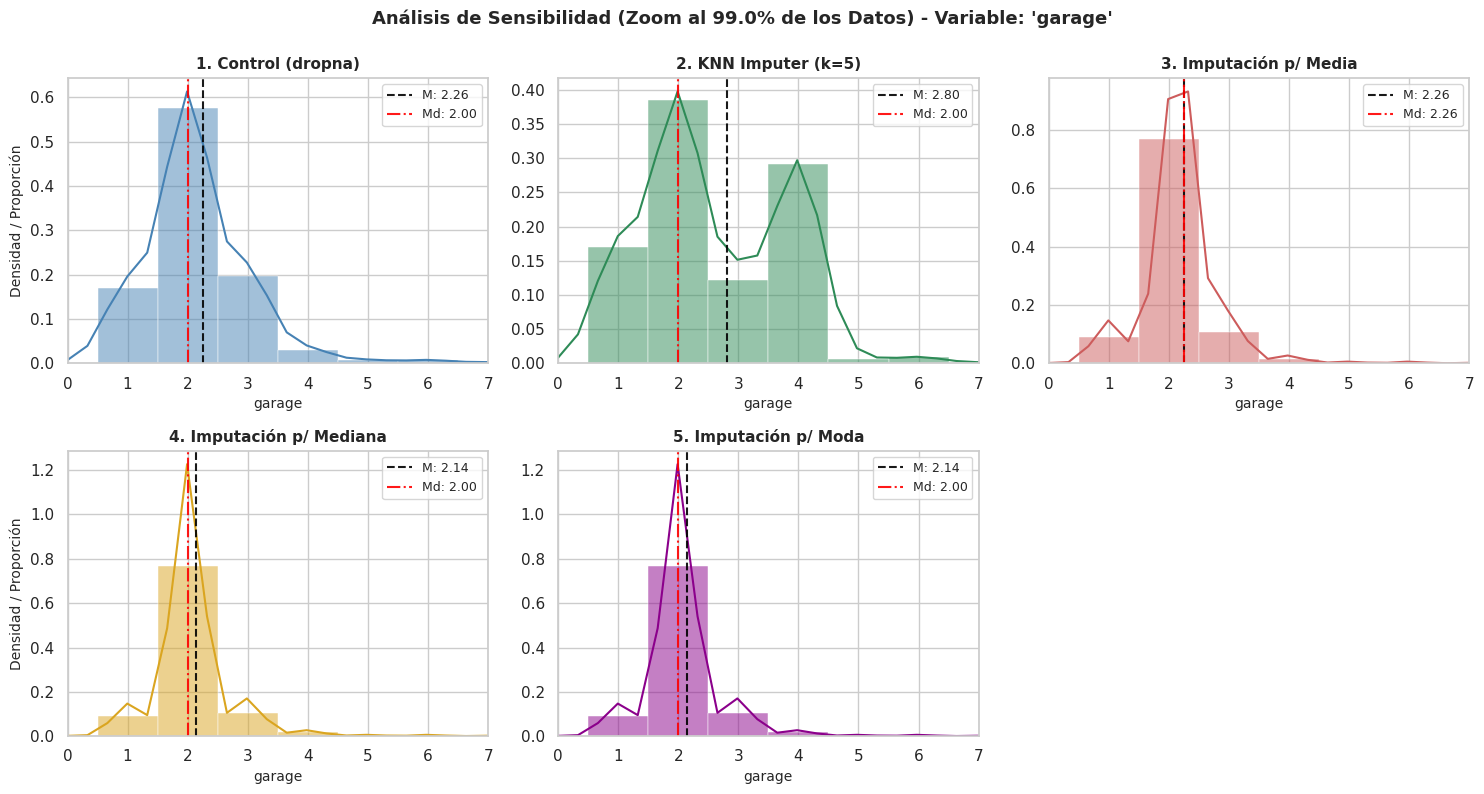

In [ ]:
# @title Comparación de diferentes imputaciones

# ==========================================
# PARÁMETRO DE AJUSTE VISUAL (MODIFICABLE)
# ==========================================
# Cambiá este valor (ej. 0.95, 0.99, 0.995) para ajustar la ventana del eje X
NIVEL_PERCENTIL = 0.99

# Configuración estética global
sns.set_theme(style="whitegrid")
colores = ["#4682B4", "#2E8B57", "#CD5C5C", "#DAA520", "#8B008B"]
columnas_a_imputar = ['sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage']

# --- BUCLE AUTOMATIZADO CON DISEÑO EN CUADRÍCULA ---
for col in columnas_a_imputar:
    es_discreta = col != 'sqft'

    # Construcción de los escenarios analíticos
    s_dropna = dataset_raw[col].dropna()
    s_knn = df[col]
    s_media = dataset_raw[col].fillna(dataset_raw[col].mean())
    s_mediana = dataset_raw[col].fillna(dataset_raw[col].median())
    s_moda = dataset_raw[col].fillna(dataset_raw[col].mode()[0])

    # ==========================================
    # CÁLCULO DINÁMICO DEL LÍMITE SUPERIOR (X)
    # ==========================================
    # Usamos la distribución control (dropna) para establecer el techo visual
    lim_superior_x = s_dropna.quantile(NIVEL_PERCENTIL)

    # Definición adaptativa de la grilla según el tipo de variable
    if col == 'sqft':
        # Caso de 4 gráficos: Grilla de 2x2
        filas, cols_grilla = 2, 2
        datasets = [s_dropna, s_knn, s_media, s_mediana]
        titulos = ["1. Control (dropna)", "2. KNN Imputer (k=5)", "3. Imputación p/ Media", "4. Imputación p/ Mediana"]
    else:
        # Caso de 5 gráficos: Grilla de 2x3
        filas, cols_grilla = 2, 3
        datasets = [s_dropna, s_knn, s_media, s_mediana, s_moda]
        titulos = ["1. Control (dropna)", "2. KNN Imputer (k=5)", "3. Imputación p/ Media", "4. Imputación p/ Mediana", "5. Imputación p/ Moda"]

    # Creamos la figura con la estructura matricial óptima para Colab
    fig, axes = plt.subplots(filas, cols_grilla, figsize=(5 * cols_grilla, 4 * filas))

    # Iteramos sobre los escenarios usando mapeo bidimensional
    for i, data in enumerate(datasets):
        # Calculamos las coordenadas de fila y columna correspondientes
        r = i // cols_grilla
        c = i % cols_grilla
        ax_actual = axes[r, c]

        # Graficamos el histograma adaptativo
        discrete_flag = True if es_discreta else False
        sns.histplot(data, kde=True, color=colores[i], ax=ax_actual, stat="density", discrete=discrete_flag)

        # ==========================================
        # APLICACIÓN DEL LÍMITE DE ZOOM VISUAL
        # ==========================================
        ax_actual.set_xlim(0, lim_superior_x)

        # Inyección de parámetros de tendencia central (Líneas de referencia)
        ax_actual.axvline(data.mean(), color="black", linestyle="--", alpha=0.9, label=f"M: {data.mean():.2f}")
        ax_actual.axvline(data.median(), color="red", linestyle="-.", alpha=0.9, label=f"Md: {data.median():.2f}")

        # Formateo estético del panel
        ax_actual.set_title(titulos[i], fontsize=11, fontweight='bold')
        ax_actual.set_xlabel(col, fontsize=10)
        ax_actual.set_ylabel("Densidad / Proporción" if c == 0 else "", fontsize=10)
        ax_actual.legend(fontsize=9, loc='upper right')

    # DETALLE DE CALIDAD: Apagar el panel vacío si la grilla es de 2x3 (5 gráficos)
    if filas == 2 and cols_grilla == 3:
        axes[1, 2].set_visible(False)

    # Título principal y ajuste de márgenes indicando el percentil utilizado
    plt.suptitle(f"Análisis de Sensibilidad (Zoom al {NIVEL_PERCENTIL*100:.1f}% de los Datos) - Variable: '{col}'",
                 fontsize=13, fontweight='bold', y=0.99)
    plt.tight_layout()
    plt.show()

### **Análisis Crítico e Interpretación de los Gráficos de Sensibilidad**

1. **Evidencia de Distorsión en la Imputación Simple (Media, Mediana y Moda):**
   * **En variables continuas (`sqft`):** Los enfoques de *Media* y *Mediana* provocan una severa deformación geométrica al generar un pico artificial rígido en la zona central de la distribución. Este achatamiento de las colas altera el sesgo positivo característico de los datos inmobiliarios y reduce artificialmente la varianza total.
   * **En variables discretas (`beds`, `baths`, `garage`, `stories`):** Las imputaciones por *Mediana* y *Moda* provocan una concentración artificial masiva en niveles enteros específicos (por ejemplo, inflar desmedidamente la frecuencia de viviendas con exactamente 3 dormitorios o 2 baños). Por su parte, la *Media* introduce una inconsistencia lógica al asignar valores decimales no interpretables para variables de conteo (por ejemplo, propiedades con 1,69 pisos).

2. **Validación del Enfoque Multivariado (`KNNImputer`):**
   * El panel de la imputación por vecinos más cercanos demuestra ser la estrategia más robusta. Al estimar los vacíos utilizando las características de propiedades "gemelas" (similares en tipo y dimensiones), los datos imputados se distribuyen de manera orgánica a lo largo de toda la curva.
   * Como resultado el sesgo original de los datos y la variabilidad estadística se preservan casi idénticos al escenario de eliminación (`dropna`), garantizando la consistencia interna necesaria para el posterior modelado predictivo.

De acá en adelante se usará el dataset imputado por el método KNN, ya que ha demostrado empiricamente ser superior o los otros métodos utilizados.

#### 2.2.2-1 Detección de duplicados

In [ ]:
# Identificar registros duplicados
df.duplicated().sum()

np.int64(1317)

Al ejecutar el método `.duplicated()` sobre la matriz de datos puramente numérica e imputada, el sistema arroja una alerta de **1.317 registros duplicados**. Sin embargo, clasificar esta coincidencia como un error de carga o datos redundantes de origen es un **diagnóstico erróneo y engañoso**. Esta cantidad de duplicados esta inflada debido al pretratamiento de los datos.

Para poder ejecutar el algoritmo `KNNImputer`, nos vimos obligados a excluir temporalmente la columna `text`. Esta variable contenía la descripción publicitaria específica de cada inmueble. Al remover dicha columna, le sacamos a los registros su identidad, obligando a las propiedades a ser reconocidas solamente mediante sus propiedades númericas.


> **Conclusión:** Estos 1.317 registros no representan la misma transacción cargada por error múltiples veces. Representan **propiedades físicamente distintas pero estructuralmente homogéneas** que el proceso de imputación terminó homogeneizando en el plano numérico. Tratarlas con un `.drop_duplicates()` tradicional destruiría información legítima de mercado.



Para resolver este dilema de los duplicados post-imputación sin destruir información legítima ni sesgar el tamaño de la muestra, la estrategia óptima consiste en utilizar la variable `text` del archivo original como una ancla de identidad.  A continuación, se justifican las ventajas de este enfoque:

*   En el mercado de Real Estate, es perfectamente factible encontrar casas homogéneas (mismos metros cuadrados, misma cantidad de ambientes y mismo precio de lista). Lo que garantiza que no estamos cargando dos veces la misma planilla de tasación es la descripción textual o el reporte de venta. Si dos filas tienen idéntica estructura numérica tras el KNN pero sus textos descriptivos difieren, se demuestra que son observaciones independientes que aportan varianza real al modelo.
*   Si al realizar el control sobre la columna `text` encontramos cadenas de caracteres idénticas (mismas palabras, misma puntuación), estamos ante un duplicado real de origen.


In [ ]:
# =====================================================================
# ELIMINACIÓN DE DUPLICADOS USANDO LA COLUMNA ANCLA ('text')
# =====================================================================

# Identificamos duplicados reales basados en la descripción del inmueble
# Mantendremos la primera aparición ('first') y marcaremos el resto
duplicados_reales_mascara = dataset_raw.duplicated(subset=['text'], keep='first')
cant_duplicados_reales = duplicados_reales_mascara.sum()

print("="*80)
print(f" AUDITORÍA POST-IMPUTACIÓN: CONTROL DE REDUNDANCIA POR DESCRIPCIÓN")
print("="*80)
print(f"-> Registros con descripciones de texto idénticas (Duplicados Reales): {cant_duplicados_reales}")
print(f"-> Filas idénticas en el dataset imputado por KNN: {df.duplicated().sum()}")

# Descartamos solo las réplicas reales de texto
# Esto preserva las casas legítimas que el KNN completó idénticamente.
df_1 = df[~duplicados_reales_mascara].copy()

print("\n[PROCESO DE CURACIÓN COMPLETADO]")
print(f" Dimensión de la base antes del filtro: {df.shape}")
print(f" Dimensión de la base limpia y definitiva: {df_1.shape}")
print(f" Total de filas preservadas legítimamente: {len(df_1)}")
print("="*80)


 AUDITORÍA POST-IMPUTACIÓN: CONTROL DE REDUNDANCIA POR DESCRIPCIÓN
-> Registros con descripciones de texto idénticas (Duplicados Reales): 174
-> Filas idénticas en el dataset imputado por KNN: 1317

[PROCESO DE CURACIÓN COMPLETADO]
 Dimensión de la base antes del filtro: (8362, 17)
 Dimensión de la base limpia y definitiva: (8188, 17)
 Total de filas preservadas legítimamente: 8188


Con esto terminamos la limpieza inicial (nulos y duplicados), ahora continuaremos con el analisis descriptivo para ver si es necesario más ajustes.

---
### 2.3 Análisis Descriptivo

Realizar un estudio analítico descriptivo completo de las variables.

#### 2.3.1 Resumen estadístico general

In [ ]:
# Resumen estadístico con .describe()
df_1.describe()


,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,type_apartment,type_condos,type_duplex_triplex,type_farm,type_land,type_mobile,type_multi_family,type_single_family,type_townhomes
count,8.188000e+03,8188.000000,8188.000000,8188.000000,8188.000000,8188.000000,8188.000000,8188.000000,8188.000000,8188.000000,8188.000000,8188.000000,8188.000000,8188.000000,8188.000000,8188.000000,8188.000000
mean,8.830329e+05,2900.896507,1.607352,3.252320,2.106864,2.233146,2.525769,2.803004,0.000122,0.118100,0.003175,0.011969,0.268564,0.029555,0.018075,0.474963,0.075476
std,2.008266e+06,1701.242315,0.628565,1.348094,1.785817,1.298773,1.312136,2.448523,0.011051,0.322746,0.056264,0.108752,0.443240,0.169368,0.133232,0.499403,0.264174
min,1.000000e+00,273.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.490000e+05,1582.000000,1.000000,2.000000,0.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.950000e+05,2700.500000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.950000e+05,3974.800000,2.000000,4.000000,3.000000,3.000000,3.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,4.500000e+07,39558.000000,7.000000,30.000000,28.000000,28.000000,28.000000,66.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### 2.3.2 Estadistica descriptiva completa

In [ ]:
# @title Función para el calculo de medidas descriptivas
def medidas_estadisticas(dataframe, columnas):
    """
    Calcula un inventario completo de estadísticas descriptivas clasificado por
    medidas de tendencia central, dispersión, forma y percentiles.
    """
    reporte_estadistico = []

    for col in columnas:
        # Extraemos la serie
        serie = dataframe[col]

        # 1. Medidas de Tendencia Central
        media = serie.mean()
        mediana = serie.median()
        # Capturamos la primera moda en caso de distribuciones multimodales
        moda = serie.mode()[0] if not serie.mode().empty else np.nan

        # 2. Medidas de Dispersión
        desvio_std = serie.std()
        varianza = serie.var()
        minimo = serie.min()
        maximo = serie.max()
        rango = maximo - minimo
        # Coeficiente de Variación (CV = Desvío / Media)
        coef_variacion = (desvio_std / media) if media != 0 else np.nan

        # 3. Percentiles Clave
        p10 = serie.quantile(0.10)
        p25 = serie.quantile(0.25)
        p50 = serie.quantile(0.50) # Coincide matemáticamente con la mediana
        p75 = serie.quantile(0.75)
        p90 = serie.quantile(0.90)
        rango_intercuartil = p75 - p25

        # 4. Medidas de Forma (Utilizando sesgo y curtosis de Fisher)
        asimetria_skew = serie.skew()
        curtosis_kurt = serie.kurtosis()

        # Compilamos el registro de la variable actual
        reporte_estadistico.append({
            "Variable": col,
            "Cantidad de registros": len(serie),
            # --- Tendencia Central ---
            "Media Aritmética": media,
            "Mediana": mediana,
            "Moda": moda,
            # --- Dispersión ---
            "Desvío Estándar (σ)": desvio_std,
            "Varianza (σ²)": varianza,
            "Rango Intercuartílico (RIQ)": rango_intercuartil,
            "Coef. Variación (CV)": coef_variacion,
            "Rango Total": rango,
            "Mínimo": minimo,
            "Máximo": maximo,
            # --- Percentiles ---
            "Percentil 10 (P10)": p10,
            "Percentil 25 (P25/Q1)": p25,
            "Percentil 50 (P50/Q2)": p50,
            "Percentil 75 (P75/Q3)": p75,
            "Percentil 90 (P90)": p90,
            # --- Forma ---
            "Asimetría (Skewness)": asimetria_skew,
            "Curtosis": curtosis_kurt
        })

    # Convertimos a DataFrame y transponemos para facilitar la lectura visual en el Colab
    df_reporte = pd.DataFrame(reporte_estadistico).set_index("Variable").T

    return df_reporte

In [ ]:
# Definimos el conjunto de variables cuantitativas del Real Estate de Colorado
columnas_a_analizar = ['listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage']

# Ejecutamos la función sobre tu DataFrame curado sin duplicados reales
df_descriptivo = medidas_estadisticas(df_1, columnas_a_analizar)
display(df_descriptivo.style.format("{:,.2f}"))

Variable,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
Cantidad de registros,"8,188.00","8,188.00","8,188.00","8,188.00","8,188.00","8,188.00","8,188.00","8,188.00"
Media Aritmética,"883,032.87","2,900.90",1.61,3.25,2.11,2.23,2.53,2.80
Mediana,"495,000.00","2,700.50",2.00,3.00,2.00,2.00,2.00,2.00
Moda,"450,000.00","4,204.40",2.00,4.00,0.00,1.00,2.00,2.00
Desvío Estándar (σ),"2,008,265.99","1,701.24",0.63,1.35,1.79,1.30,1.31,2.45
Varianza (σ²),"4,033,132,283,924.10","2,894,225.42",0.40,1.82,3.19,1.69,1.72,6.00
Rango Intercuartílico (RIQ),"546,000.00","2,392.80",1.00,2.00,3.00,2.00,1.00,2.00
Coef. Variación (CV),2.27,0.59,0.39,0.41,0.85,0.58,0.52,0.87
Rango Total,"44,999,999.00","39,285.00",6.00,30.00,28.00,27.00,27.00,66.00
Mínimo,1.00,273.00,1.00,0.00,0.00,1.00,1.00,0.00


#### 2.3.3 Visualización de la distribución de las variables numéricas principales


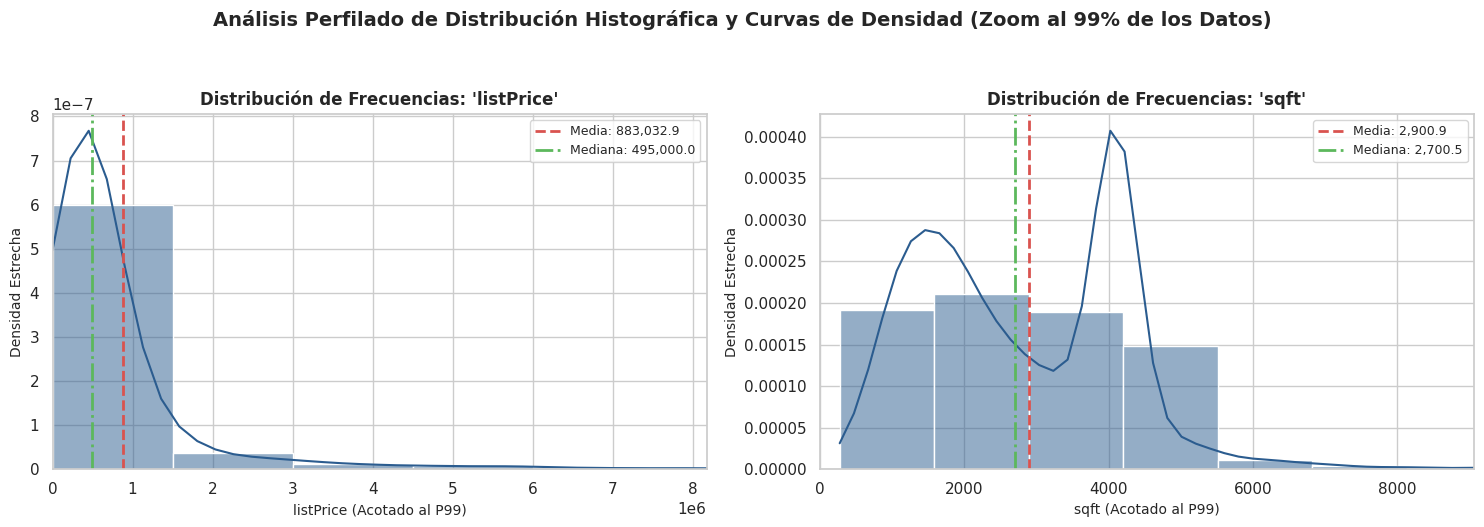

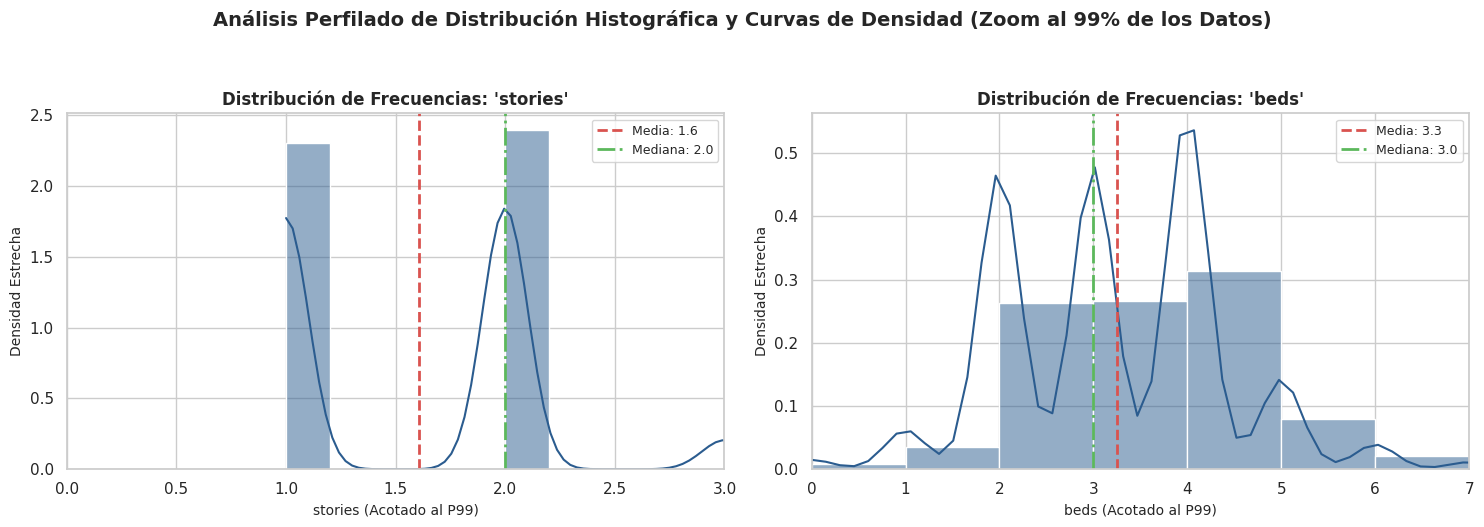

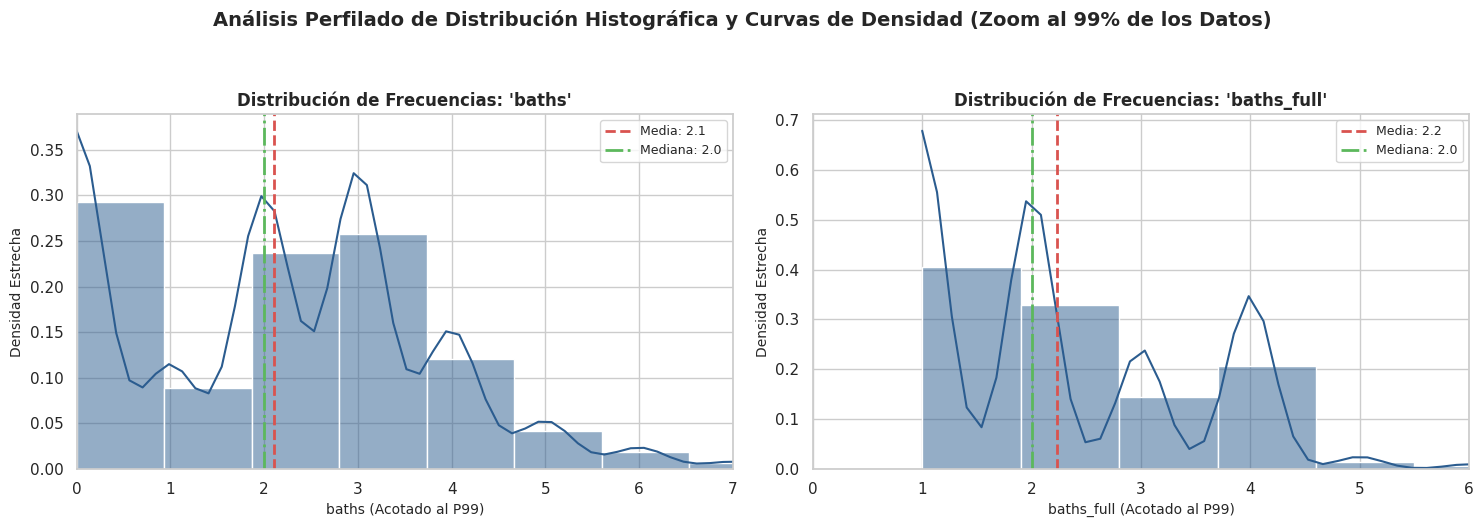

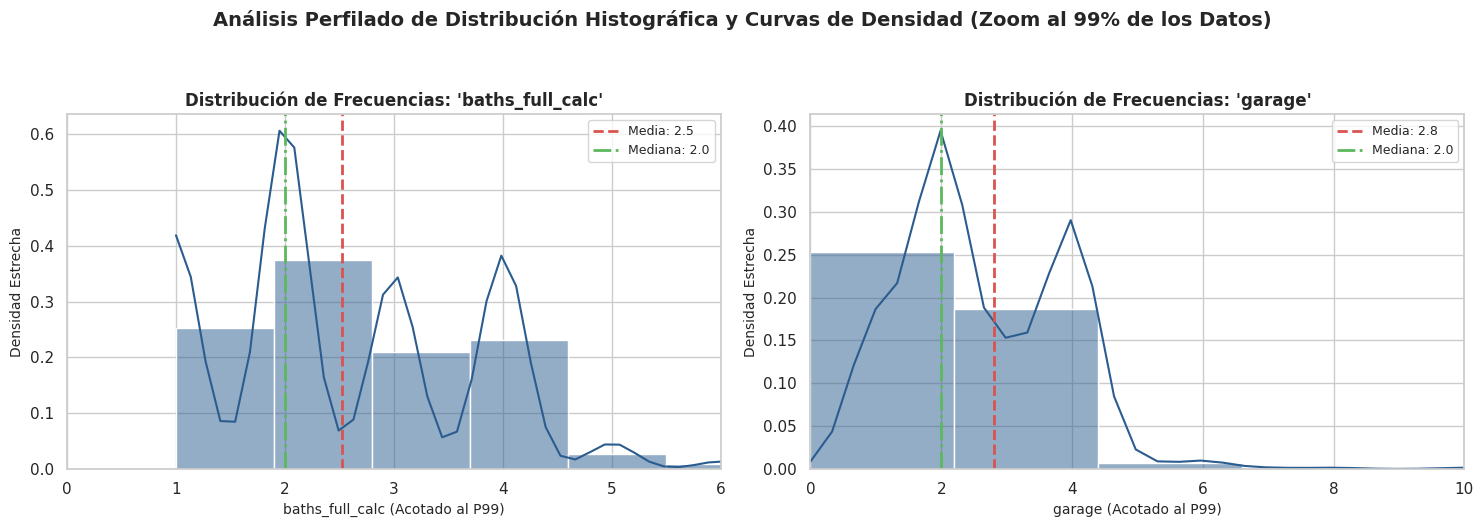

In [ ]:
# @title Histogramas de variables numéricas
# Configuración estética
sns.set_theme(style="whitegrid")

# --- BUCLE DE VISUALIZACIÓN: HISTOGRAMAS EN PAREJAS (GRILLAS 1x2) ---
for idx in range(0, len(columnas_a_analizar), 2):
    par_columnas = columnas_a_analizar[idx:idx+2]
    num_cols = len(par_columnas)

    fig, axes = plt.subplots(1, num_cols, figsize=(15, 5))

    # Aseguramos estructura de lista si queda una variable huérfana al final
    if num_cols == 1:
        axes = [axes]

    for i, col in enumerate(par_columnas):
        ax_actual = axes[i]

        # Graficamos el histograma con curva de densidad estimada (KDE)
        sns.histplot(
            data=df_1,
            x=col,
            kde=True,
            ax=ax_actual,
            color="#2b5c8f",     # Azul institucional
            edgecolor="white",   # Separación clara de barras
            bins=30,             # Binning estándar balanceado
            stat="density"       # Escala normada para comparar con la curva KDE
        )

        # Inyectamos líneas verticales para marcar los estadísticos de tendencia central
        media_val = df_1[col].mean()
        mediana_val = df_1[col].median()

        ax_actual.axvline(media_val, color="#d9534f", linestyle="--", linewidth=2, label=f"Media: {media_val:,.1f}")
        ax_actual.axvline(mediana_val, color="#5cb85c", linestyle="-.", linewidth=2, label=f"Mediana: {mediana_val:,.1f}")

        # =========================================================================
        # MODIFICACIÓN CLAVE: CALCULO Y APLICACIÓN DEL XLIM (PERCENTIL 99)
        # =========================================================================
        # Calculamos el límite superior
        limite_superior_x = df_1[col].quantile(0.99)

        # Seteamos el límite del eje X: desde cero hasta el P99
        ax_actual.set_xlim(0, limite_superior_x)
        # =========================================================================

        # Formateo y rotulación académica
        ax_actual.set_title(f"Distribución de Frecuencias: '{col}'", fontsize=12, fontweight='bold')
        ax_actual.set_xlabel(f"{col} (Acotado al P99)", fontsize=10) # Claridad metodológica en la etiqueta
        ax_actual.set_ylabel("Densidad Estrecha", fontsize=10)
        ax_actual.legend(loc="upper right", fontsize=9)

    plt.suptitle("Análisis Perfilado de Distribución Histográfica y Curvas de Densidad (Zoom al 99% de los Datos)",
                 fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

#### 2.3.4 Análisis de Distribución por Variable Objetivo

El análisis visual del histograma para la variable objetivo `listPrice` (precio de lista) se datalla en los siguientes puntos:
   * La curva de densidad estimada (KDE) exhibe un marcado sesgo hacia la derecha (asimetría positiva), esto es confirmado visualmente por la separación entre la **Mediana** (línea discontinua verde en \$495.000) y la **Media Aritmética** (línea discontinua roja en \$883.032,9). La mayor concentración ocurre en propiedades de menor precio. A medida que el precio avanza hacia la derecha del eje horizontal, se observa una caída abrupta en la cantidad de propiedades disponibles, realizando una transición hacia el mercado residencial premium de Colorado.

   * La Mediana, al ser un estadístico robusto no afectado por los extremos, refleja el verdadero centro de gravedad del mercado masivo: el 50% de las viviendas de la población de Colorado se listan por un valor inferior a los \$495.000.
   * Por el contrario, la Media Aritmética se encuentra fuertemente desplazada e inflada hacia la derecha (casi duplicando el valor de la mediana). Esto demuestra analíticamente el "efecto palanca" que ejercen las propiedades de ultra-lujo (mansiones que alcanzan los \$45.000.000). Estas pocas observaciones arrastran el promedio general, convirtiéndolo en una medida de tendencia central poco representativa para describir a una propiedad típica de la región.

   * Este patrón de asimetría positiva severa y curtosis leptocúrtica (colas pesadas) en la variable target constituye una alerta crítica para los supuestos del modelo clásico de Mínimos Cuadrados Ordinarios (OLS). El estimador lineal asume normalidad y homogeneidad en los errores.
   * Entrenar una regresión utilizando `listPrice` en su escala lineal original provocará que los errores de predicción en el segmento de lujo se eleven al cuadrado, forzando a la recta a desviar su pendiente óptima con tal de intentar capturar esos valores altos, deteriorando el poder de generalización sobre el 95% restante del mercado.

#### 2.3.5 Interpretación de Resultados Descriptivos

**Celda de texto narrativa:** Redactar las conclusiones del análisis descriptivo, destacando hallazgos relevantes, distribuciones asimétricas, correlaciones fuertes, etc.

### **🏛️ 1. Análisis de Medidas de Tendencia Central (Sesgo de Posición)**

Al evaluar el bloque de localización, el comportamiento de las variables estructurales continuas (`listPrice` y `sqft`) valida de forma contundente la hipótesis de **asimetría positiva extrema**:

* **El caso de `listPrice` (Target):** Presenta una Media Aritmética de **$\$883.032,87$**, una Mediana de **$\$495.000,00$** y una Moda de **$\$450.000,00$**. Entonces tenemos:
    
    $$\text{Media} > \text{Mediana} > \text{Moda}$$
    
  La distancia entre la media y la mediana es de casi **$\$390.000$**. Esto demuestra que el promedio está severamente "inflado" y distorsionado por las propiedades premium. La verdadera realidad del mercado residencial masivo de Colorado está descripta por la mediana: el $50\%$ de las viviendas se listan por debajo de los $\$495.000$.
* **El caso de la superficie (`sqft`):** Sigue idéntica lógica, con una media de **$2.900,90\text{ sqft}$** frente a una mediana de **$2.700,50\text{ sqft}$**. La masa central del mercado comercializa propiedades de tamaño estándar, pero un grupo selecto de grandes dimensiones estira la media hacia arriba.

---

### **📊 2. Análisis de Medidas de Dispersión (Heterogeneidad y Volatilidad)**

El desvío estándar ($\sigma$) no permite comparar variables con diferentes unidades de medida (no es lo mismo evaluar desvíos en dólares que en cantidad de baños). Por lo tanto, el foco del análisis se centra en el **Coeficiente de Variación (CV)**, el cual normaliza la dispersión:

* **Volatilidad Financiera Extrema:** El $CV$ de `listPrice` es de **$2,27$**. En la práctica estadística, cualquier valor superior a $1,00$ denota una distribución hiper-heterogénea. El desvío estándar ($\sigma \approx \$2.008.266$) duplica con creces a la propia media, confirmando que conviven propiedades de valores muy dispares en la muestra.
* **Estabilidad Arquitectónica:** En claro contraste, las variables discretas como ambientes (`beds` con $CV = 0,41$) y pisos (`stories` con $CV = 0,39$) exhiben coeficientes marcadamente inferiores a $0,50$. Esto demuestra una **alta homogeneidad estructural central**; la oferta habitacional se apega estrictamente a tipologías constructivas estandarizadas en la región.

---

### **📐 3. Análisis de Medidas de Forma y Percentiles (Comportamiento de las Colas)**

Los coeficientes de Fisher proporcionan la confirmación matemática de la morfología asimétrica observada en los histogramas:

* **Asimetría (*Skewness*):** La asimetría de `listPrice` ($9,67$) y de `garage` ($10,62$) califica a las distribuciones como **fuertemente asimétricas positivas**. Los datos presentan colas derechas infinitamente largas.
* **Curtosis (Grosor de Colas):** La curtosis de `listPrice` alcanza un valor crítico de **$128,95$** y `garage` llega a un colosal **$194,09$**. Al ser índices sustancialmente mayores a cero, clasifican a las distribuciones como **altamente leptocúrticas**. Esto demuestra formalmente que la probabilidad de ocurrencia de valores atípicos (*outliers*) en las colas de este dataset es masiva, rompiendo el supuesto de normalidad teórica.
* **El Salto de los Percentiles:** Observando el vector de percentiles de `listPrice`, se destaca que el $90\%$ de los datos ($P_{90}$) llega hasta los **$\$1.541.500$**. Esto significa que el salto hacia el máximo absoluto de **$\$45.000.000$** ocurre de manera violenta en apenas el $1\%$ restante de la muestra, confirmando la existencia de un micro-segmento de ultra-lujo.

---

### **🚨 4. Apartado Crítico: Alertas Estructurales e Inconsistencias Detectadas**

Haber ejecutado el análisis descriptivo avanzado de forma previa a la depuración matemática permite detectar "ruido analítico" y anomalías operacionales de carga que de otro modo habrían quedado ocultas en los promedios:

1.  **La Alerta del Precio Mínimo:** El valor mínimo en `listPrice` registra un valor de **$\$1,00$**. Esto constituye un error lógico y operacional de carga absoluto (ruido de base). Dejar este registro sesgaría cualquier predicción de tasas de mercado.
2.  **La Anomalía de los Ambientes:** La variable `beds` (dormitorios) muestra un valor máximo de **$30$**. Si bien existen mansiones particulares, un volumen de 30 dormitorios en una base estrictamente residencial suele mapear con errores de carga o complejos comerciales mal clasificados.
3.  **El Despropósito del Garaje:** La variable `garage` presenta una asimetría y curtosis totalmente desfiguradas debido a su valor máximo: **¡cochera con capacidad para 66 autos!** Este registro actúa como un punto de alta influencia (*leverage point*) que arruinaría las pendientes de una regresión lineal clásica si no se lo aísla analíticamente.



#### 2.2.3 Detección de valores atípicos (Outliers)

**Método 1: Boxplots (visualización)**

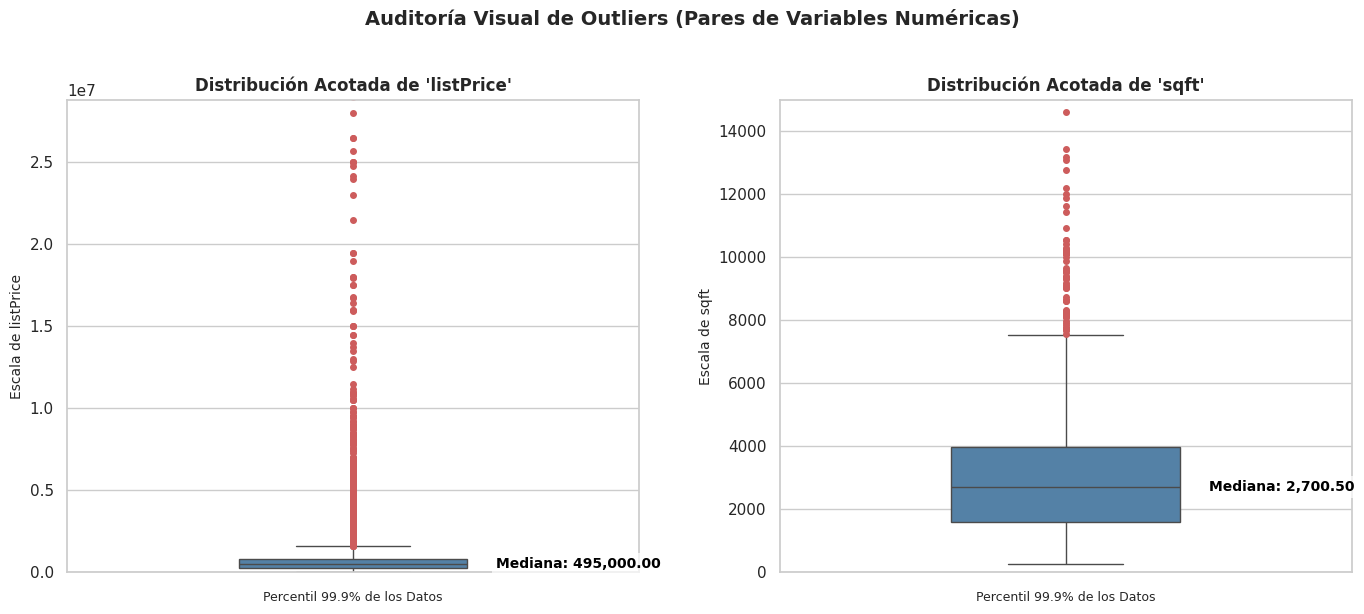

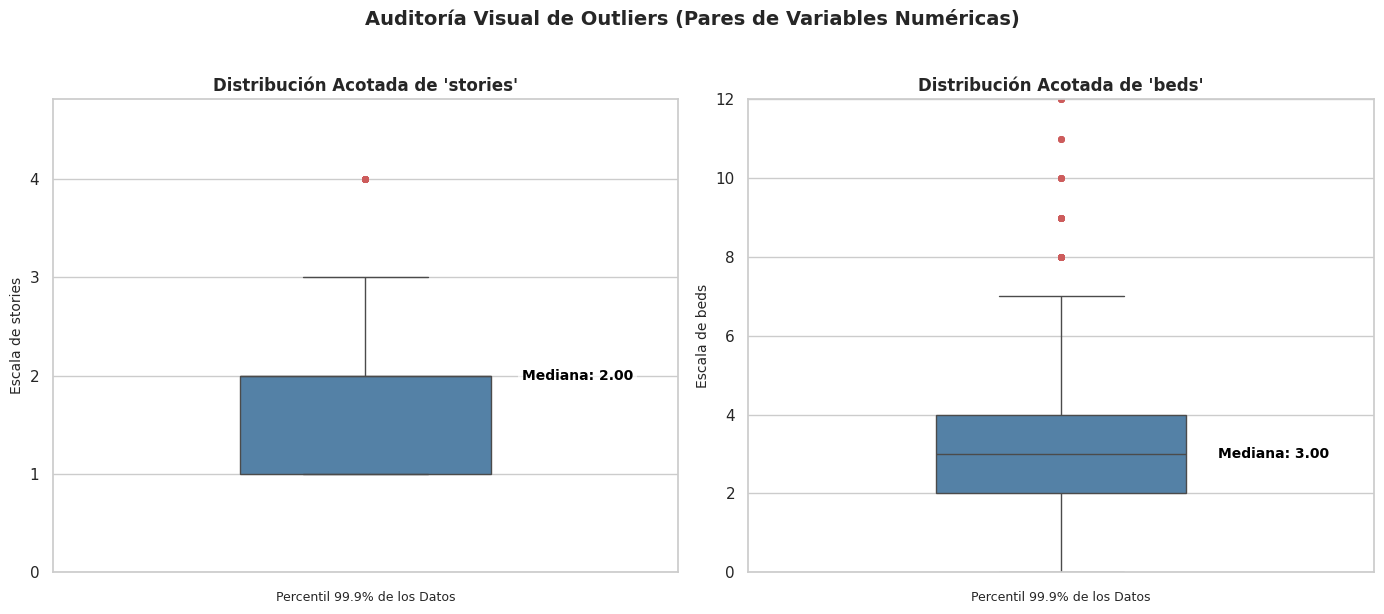

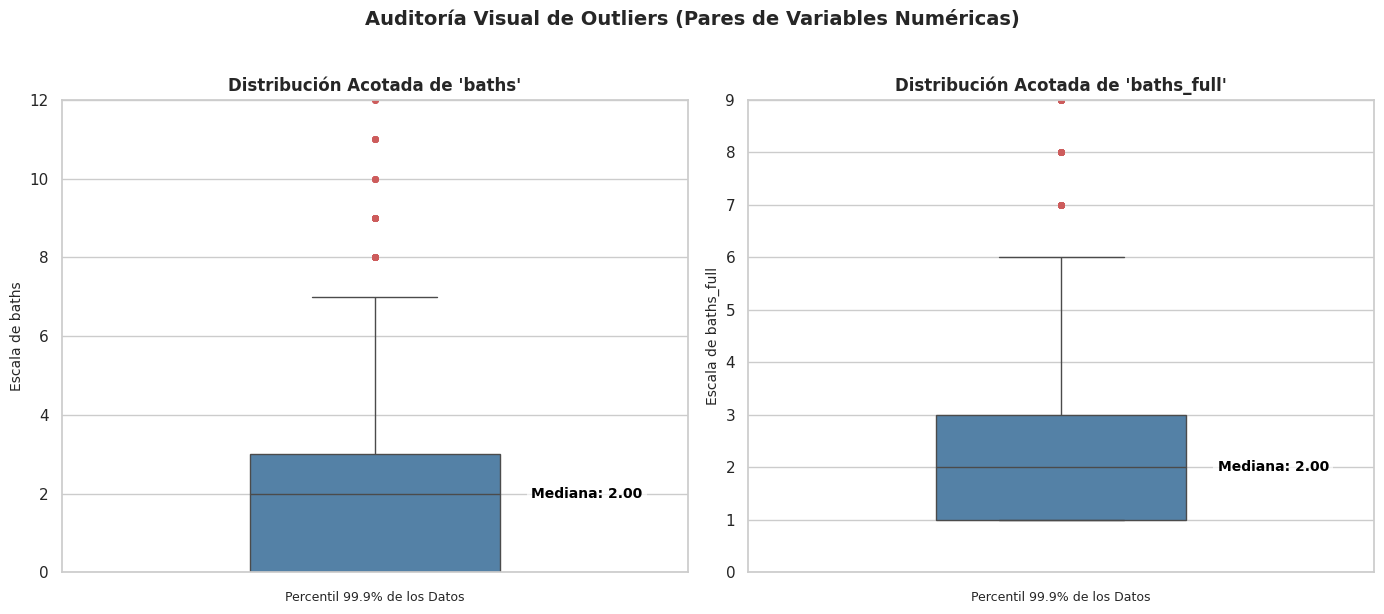

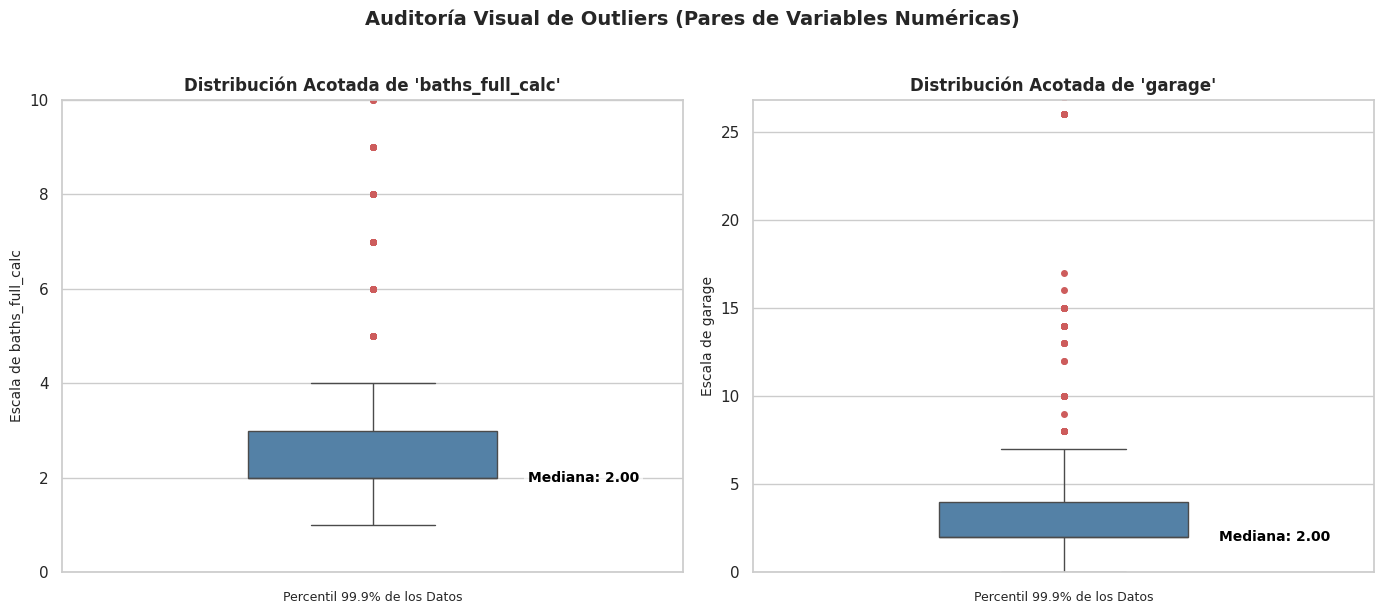

In [ ]:
# @title Boxplots de las variables
# Configuración estética global
sns.set_theme(style="whitegrid")

# Definimos las variables numéricas a analizar (Predictores + Target)
# Usamos el DataFrame donde ya realizaste la imputación por KNN en pasos previos
columnas_outliers = ['listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full','baths_full_calc', 'garage']

# Parámetro modificable para el zoom del eje Y (Filtro visual de outliers extremos)
NIVEL_PERCENTIL_Y = 0.999

# --- BUCLE OPTIMIZADO: GRAFICAR EN PAREJAS (GRILLAS DE 1x2) ---
# Iteramos saltando de a 2 elementos para agrupar en pares
for idx in range(0, len(columnas_outliers), 2):
    # Seleccionamos el par de variables actual
    par_columnas = columnas_outliers[idx:idx+2]
    num_columnas_grilla = len(par_columnas)

    # Creamos una figura horizontal de 1 fila y hasta 2 columnas
    fig, axes = plt.subplots(1, num_columnas_grilla, figsize=(14, 6))

    # Si queda una sola variable colgada al final, axes no será un array. Lo convertimos.
    if num_columnas_grilla == 1:
        axes = [axes]

    for i, col in enumerate(par_columnas):
        ax_actual = axes[i]

        # Graficamos el Boxplot en posición vertical
        # flierprops configura los outliers más allá de 1.5*IQR en rojo para auditoría visual
        sns.boxplot(
            y=df_1[col],
            ax=ax_actual,
            color="#4682B4",
            width=0.4,
            flierprops={"markerfacecolor": "#CD5C5C", "markeredgecolor": "#CD5C5C", "markersize": 4}
        )

        # CÁLCULO DINÁMICO DE LA MEDIANA
        mediana_val = df_1[col].median()

        # INYECCIÓN TEXTUAL DE LA MEDIANA
        # Dado que es un boxplot univariado, la caja se centra en el índice X = 0.
        # Desplazamos el texto ligeramente a la derecha (X = 0.25) para que no tape la caja.
        ax_actual.text(
            0.25,
            mediana_val,
            f"Mediana: {mediana_val:,.2f}",
            color="black",
            fontweight="bold",
            va="center",
            ha="left",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=3)
        )


        # CÁLCULO DINÁMICO DEL LÍMITE SUPERIOR PARA EL EJE Y
        # Evaluamos el percentil 99 para que la caja no se comprima por valores extremos absolutos
        lim_superior_y = df_1[col].quantile(NIVEL_PERCENTIL_Y)

        # Ajustamos el límite inferior en 0 (no hay casas con metros o precios negativos)
        # y el límite superior al percentil calibrado
        ax_actual.set_ylim(0, lim_superior_y)

        # Formateo estético e informativo de cada panel
        ax_actual.set_title(f"Distribución Acotada de '{col}'", fontsize=12, fontweight='bold')
        ax_actual.set_ylabel(f"Escala de {col}", fontsize=10)
        ax_actual.set_xlabel(f"Percentil {NIVEL_PERCENTIL_Y*100:.1f}% de los Datos", fontsize=9)

    plt.suptitle(f"Auditoría Visual de Outliers (Pares de Variables Numéricas)", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### **Interpretación Crítica del Diagnóstico Visual de Outliers**

La inspección de los diagramas de caja (*Boxplots*) permite extraer conclusiones sobre la naturaleza de las variables numéricas del mercado inmobiliario de Colorado:

1. **Variables Continuas con Comportamiento de Alta Asimetría y Dispersión (`listPrice` y `sqft`):**
   * **`listPrice` (Target):** Exhibe una concentración compacta en los cuartiles inferiores, seguida de una "lluvia" de observaciones atípicas por encima del bigote superior. Esto evidencia una distribución con una severa asimetría positiva (sesgo a la derecha). No estamos ante errores de medición, sino ante **outliers estructurales** que reflejan la coexistencia de un mercado inmobiliario masivo estándar y un segmento minoritario de propiedades de ultra-lujo.
   * **`sqft` (Superficie):** Replica exactamente el comportamiento del precio de lista. La presencia masiva de puntos atípicos indica que las dimensiones de las propiedades presentan colas derechas extendidas.

2. **Variables Discretas (`beds`, `baths`, `baths_full`, `stories`, `garage`):**
   * La cantidad de observaciones por fuera de los bigotes es marginal. Esto se debe a que la variabilidad física de estas características está acotada debido al límite natural para la cantidad de dormitorios o pisos que puede tener una vivienda residencial, incluso en el segmento de lujo. Los pocos casos aislados detectados aquí deben ser auditados minuciosamente, ya que presentan una alta probabilidad de ser **outliers de error** (fallas en la carga de datos).

##### Alan (split 1)

**Método 2: Regla de Tukey (RIQ)**

Outlier si: `x < Q1 - 1.5*RIQ` o `x > Q3 + 1.5*RIQ`

In [ ]:
# @title Función para detectar outliers con regla de Tukey
# Función para detectar outliers con regla de Tukey
def auditar_outliers_tukey(dataframe, columnas):
    """
    Calcula analíticamente los valores atípicos utilizando la Regla de Tukey (RIQ).
    Presenta un resumen consolidado con métricas de impacto estructural.
    """
    resultados = []
    total_registros = len(dataframe)

    for col in columnas:
        # Extraemos la serie
        serie = dataframe[col]

        # Cálculo de los componentes de la Regla de Tukey
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        riq = q3 - q1

        # Establecimiento de límites teóricos
        limite_inferior = q1 - 1.5 * riq
        limite_superior = q3 + 1.5 * riq

        # Identificación analítica de registros fuera de límites
        outliers_inf = dataframe[dataframe[col] < limite_inferior]
        outliers_sup = dataframe[dataframe[col] > limite_superior]
        total_outliers = len(outliers_inf) + len(outliers_sup)

        # Cálculo del impacto relativo en la base de datos
        porcentaje_impacto = (total_outliers / total_registros) * 100

        # Almacenamos las métricas clave para el reporte
        resultados.append({
            "Variable": col,
            "Mínimo": serie.min(),
            "Lím. Inferior": limite_inferior,
            "Q1 (25%)": q1,
            "Mediana (50%)": serie.median(),
            "Q3 (75%)": q3,
            "Lím. Superior": limite_superior,
            "Máximo": serie.max(),
            "Cant. Outliers": total_outliers,
            "Impacto (%)": f"{porcentaje_impacto:.2f}%"
        })

    # Convertimos a DataFrame para una presentación tabular estructurada
    df_resumen = pd.DataFrame(resultados).set_index("Variable")
    return df_resumen

In [ ]:
# Aplicamos detección de outliers
df_outliers_report = auditar_outliers_tukey(df_1, columnas_outliers)

# Mostramos el reporte de outliers con el método de Tukey
display(df_outliers_report)



,Mínimo,Lím. Inferior,Q1 (25%),Mediana (50%),Q3 (75%),Lím. Superior,Máximo,Cant. Outliers,Impacto (%)
Variable,,,,,,,,,
listPrice,1.0,-570000.0,249000.0,495000.0,795000.0,1614000.0,45000000.0,774,9.45%
sqft,273.0,-2007.2,1582.0,2700.5,3974.8,7564.0,39558.0,108,1.32%
stories,1.0,-0.5,1.0,2.0,2.0,3.5,7.0,56,0.68%
beds,0.0,-1.0,2.0,3.0,4.0,7.0,30.0,50,0.61%
baths,0.0,-4.5,0.0,2.0,3.0,7.5,28.0,57,0.70%
baths_full,1.0,-2.0,1.0,2.0,3.0,6.0,28.0,41,0.50%
baths_full_calc,1.0,0.5,2.0,2.0,3.0,4.5,28.0,316,3.86%
garage,0.0,-1.0,2.0,2.0,4.0,7.0,66.0,106,1.29%


**Método 3: Z-score**

Outlier si: `|z-score| > 3`

In [ ]:
# @title Función para detectar outliers con regla de Z-score
def auditar_outliers_zscore(dataframe, columnas):
    """
    Calcula analíticamente los valores atípicos utilizando el método del Z-Score (|Z| > 3)
    apoyándose en la librería especializada scipy.stats.
    """
    resultados = []
    total_registros = len(dataframe)

    for col in columnas:
        # Extraemos la serie
        serie = dataframe[col]

        # CÁLCULO DE Z-SCORES UTILIZANDO SCIPY
        # scipy.stats.zscore calcula automáticamente (X - media) / desvío para toda la serie
        z_scores_serie = zscore(serie)

        # Creamos una serie con el mismo índice original para mapear los resultados con el dataframe
        z_scores_mapeados = pd.Series(z_scores_serie, index=serie.index)

        # Identificación analítica mediante la máscara de umbral absoluto |Z| > 3
        outliers_detectados = dataframe[z_scores_mapeados.abs() > 3]
        total_outliers = len(outliers_detectados)

        # Métricas de control e impacto operacional
        porcentaje_impacto = (total_outliers / total_registros) * 100
        media_val = serie.mean()
        desvio_std = serie.std()

        # Almacenamos las métricas clave en nuestro inventario corporativo
        resultados.append({
            "Variable": col,
            "Cantidad de registros": len(serie),
            "Mínimo Real": serie.min(),
            "Lím. Inferior (μ - 3σ)": media_val - 3 * desvio_std,
            "Media Aritmética (μ)": media_val,
            "Desvío Estándar (σ)": desvio_std,
            "Lím. Superior (μ + 3σ)": media_val + 3 * desvio_std,
            "Máximo Real": serie.max(),
            "Cant. Outliers (|Z|>3)": total_outliers,
            "Impacto Muestral (%)": f"{porcentaje_impacto:.2f}%"
        })

    # Construimos el DataFrame consolidado para presentación tabular
    df_resumen_z = pd.DataFrame(resultados).set_index("Variable")

    return df_resumen_z

In [ ]:
# Calculamos los outliers
df_reporte_z = auditar_outliers_zscore(df_1, columnas_outliers)

# Mostramos el reporte de outliers con el método de Z-score
display(df_reporte_z.style.format({
    "Registros Válidos (N)": "{:,.0f}",
    "Mínimo Real": "{:,.2f}",
    "Lím. Inferior (μ - 3σ)": "{:,.2f}",
    "Media Aritmética (μ)": "{:,.2f}",
    "Desvío Estándar (σ)": "{:,.2f}",
    "Lím. Superior (μ + 3σ)": "{:,.2f}",
    "Máximo Real": "{:,.2f}",
    "Cant. Outliers (|Z|>3)": "{:,.0f}"
}))


,Cantidad de registros,Mínimo Real,Lím. Inferior (μ - 3σ),Media Aritmética (μ),Desvío Estándar (σ),Lím. Superior (μ + 3σ),Máximo Real,Cant. Outliers (|Z|>3),Impacto Muestral (%)
Variable,,,,,,,,,
listPrice,8188,1.00,"-5,141,765.10","883,032.87","2,008,265.99","6,907,830.83","45,000,000.00",107,1.31%
sqft,8188,273.00,"-2,202.83","2,900.90","1,701.24","8,004.62","39,558.00",99,1.21%
stories,8188,1.00,-0.28,1.61,0.63,3.49,7.00,56,0.68%
beds,8188,0.00,-0.79,3.25,1.35,7.30,30.00,50,0.61%
baths,8188,0.00,-3.25,2.11,1.79,7.46,28.00,57,0.70%
baths_full,8188,1.00,-1.66,2.23,1.30,6.13,28.00,41,0.50%
baths_full_calc,8188,1.00,-1.41,2.53,1.31,6.46,28.00,50,0.61%
garage,8188,0.00,-4.54,2.80,2.45,10.15,66.00,79,0.96%


#### 2.2.4 Tratamiento de outliers

Decisión: ¿conservar, eliminar o transformar? Justificar.

### **🔍 Análisis Comparativo de los Reportes de Detección**

El comportamiento de la variable objetivo (`listPrice`) expone la divergencia matemática radical entre ambos enfoques:

| Métrica de Control | Detección por Tukey | Detección por Z-Score |
| :--- | :---: | :---: |
| **Límite Superior** | $\$1.614.000,00$ | $\$6.907.830,83$ |
| **Cantidad de Outliers Detectados** | **$774$ registros** | **$107$ registros** |
| **Impacto Muestral (%)** | **$9,45\%$** del dataset | **$1,31\%$** del dataset |

* **La Hipersensibilidad de Tukey:** Al basarse en cuartiles ($Q_1 = \$249.000$ y $Q_3 = \$795.000$), la Regla de Tukey fija un límite estricto en $\$1.614.000$. Al hacerlo, etiqueta como "atípicos" a 774 inmuebles ($9,45\%$ de la base).
* **La Ceguera del Z-Score:** El criterio paramétrico fija un límite superior absurdamente alto en casi 7 millones de dólares, logrando identificar únicamente 107 registros ($1,31\%$).

---

### **🏛️ ¿A cuál darle importancia y por qué?**

**El grupo determina darle prioridad metodológica a la REGLA DE TUKEY**
##### **Fundamentación:**
El criterio del Z-Score sufre de una severa falla de robustez en datasets con asimetría positiva extrema. Como la media ($\mu = \$883.032,87$) y el desvío estándar ($\sigma \approx \$2.008.266$) son sensibles a los extremos, la presencia de mansiones excepcionales (como el máximo absoluto de **$\$45.000.000$**) infla artificialmente el desvío estándar.

Al agigantarse $\sigma$, el límite superior teórico ($\mu + 3\sigma$) se desplaza de forma desmedida hacia la derecha ($\$6.907.830$). Esto genera un **efecto enmascaramiento**: el Z-score se vuelve "ciego" ante propiedades de lujo legítimas de 2, 3 o 5 millones de dólares, asumiendo erróneamente que son datos normales dentro de una campana de Gauss que aquí no existe.

> 💡 **Veredicto:** Tukey es el método correcto porque la mediana y los cuartiles permanecen imperturbables ante los extremos altos, garantizando un diagnóstico más acertado.

---

### **🛠️ Estrategia de Tratamiento: ¿Qué hacemos con los outliers?**

Eliminar el $9,45\%$ de los datos identificados por Tukey mediante una poda masiva automática destruirá la potencia de la muestra y violará el principio de realidad económica. Por ende, el grupo propone dos tratamientos:

#### **1. Outliers de Error o Inconsistencia Operacional ➔ BORRADO DIRECTO**
Son registros que violan las reglas lógicas del negocio y la consistencia de los datos. **Deben ser eliminados de la base de datos inmediatamente**, ya que actúan como puntos de alta influencia que afectaría la Regresión Lineal.
* **Filtro de Precio Absurdo:** Propiedades con `listPrice` mínimo de **$\$1,00$**.
* **Filtro de Infraestructura Irreal:** Capacidad máxima de **$66$ autos en un garage**.

#### **2. Outliers Estructurales (Segmento Premium de Lujo) ➔ CONSERVACIÓN Y TRANSFORMACIÓN**
Las casas valuadas entre $\$1.614.000$ (límite de Tukey) y los $\$10.000.000$ son propiedades reales y legítimas del estado de Colorado. No son errores de carga, reflejan la verdadera naturaleza del negocio.
* **Acción Metodológica:** **SE CONSERVAN EN EL DATASET.**
* **Tratamiento por los precios altos:** Para evitar que la cola derecha estire y arruine el modelo lineal OLS, aplicaremos una **transformación logarítmica (`np.log(df['listPrice'])`)** más adelante. Al aplicar logaritmo natural, la escala se comprime y los extremos premium se integran mejor con el mercado masivo, cumpliendo el supuesto de normalidad en los residuos sin necesidad de destruir información real de mercado.

#### 2.2.5 Resolución de inconsistencias lógicas

Verificar coherencia entre variables relacionadas.

In [ ]:
# Visualización de inconsistencias

# 1. Garages
df_1[df_1['garage'] > 25]


,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,type_apartment,type_condos,type_duplex_triplex,type_farm,type_land,type_mobile,type_multi_family,type_single_family,type_townhomes
850,235000,400.0,1.0,1.0,1.0,1.0,1.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
947,139000,513.0,1.0,1.0,1.0,1.0,1.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1080,299000,473.0,1.0,1.0,1.0,1.0,1.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1106,495000,561.0,2.0,1.0,1.0,1.0,1.0,27.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1164,275000,402.0,1.0,1.0,1.0,1.0,1.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1887,139750,530.0,1.0,1.0,1.0,1.0,1.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1929,360000,584.0,3.0,1.0,1.0,1.0,1.0,27.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2117,295000,514.0,1.0,1.0,1.0,1.0,1.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2287,190000,446.0,1.0,1.0,1.0,1.0,1.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2334,329000,410.0,1.0,1.0,1.0,1.0,1.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Se observan que hay unos pocos registros que pueden almacenar 50, 60 y 66 autos en un garage pero que presentan características similares a la de otros inmuebles con capacidad 27 o 26 vehiculos. Por lo tanto solo tendremos en cuenta viviendas con cochera que pueda resguardar hasta un máximo de 27 automoviles.

In [ ]:
#2. Precio
df_1[(df_1['listPrice'] >= 1) & (df_1['listPrice'] < 1000)]

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,type_apartment,type_condos,type_duplex_triplex,type_farm,type_land,type_mobile,type_multi_family,type_single_family,type_townhomes
2713,1,3974.8,2.0,2.0,0.0,1.0,1.0,4.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3201,1,3974.8,2.0,2.0,0.0,1.0,1.0,4.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7980,200,1091.0,4.0,2.0,3.0,3.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8009,5,1236.0,2.0,2.0,3.0,3.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8068,10,1218.0,4.0,2.0,3.0,2.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8083,10,1127.0,4.0,2.0,2.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8089,500,1044.0,4.0,2.0,2.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8097,5,1368.0,4.0,3.0,3.0,2.0,3.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8098,5,1101.0,4.0,2.0,2.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8104,10,1129.0,4.0,2.0,2.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Inmuebles con precios de 1 o 2 digitos es absurdo, asi que solo tendremos en cuenta viviendas con valores de 3 dígitos en adelante

In [ ]:
# =====================================================================
# Pretratamiento: outliers
# =====================================================================

print(f"Dimensiones iniciales de la población curada: {df_1.shape}")

# Aplicamos borramos errores groseros detectados en el análisis descriptivo
condicion_consistencia = (
    (df_1['listPrice'] > 99) &       # Elimina el ruido de listPrice = $1
    (df_1['garage'] < 28)            # Aisla la anomalía de la cochera de 66 plazas
)

# Creamos la base limpia definitiva que se usará para el muestreo e inferencia
df_2 = df_1[condicion_consistencia].copy()

print("\n[PROCESO DE CURACIÓN DE OUTLIERS COMPLETADO]")
print(f" -> Dimensiones de la población definitiva limpia: {df_2.shape}")
print(f" -> Total de registros de error eliminados: {len(df_1) - len(df_2)}")
print(" -> Los outliers estructurales de alto valor se preservan para ser tratados vía log(Y) más adelante antes de aplicar el modelo")


Dimensiones iniciales de la población curada: (8188, 17)

[PROCESO DE CURACIÓN DE OUTLIERS COMPLETADO]
 -> Dimensiones de la población definitiva limpia: (8175, 17)
 -> Total de registros de error eliminados: 13
 -> Los outliers estructurales de alto valor se preservan para ser tratados vía log(Y) más adelante antes de aplicar el modelo


Finalmente tenemos una base de datos limpia para implementar en los modelos pensados para este trabajo. De aquí partimos desde un mejor puerto para obtener respuestas más fieles a la realidad de este mercado inmobiliario.

---
<a id="muestreo"></a>
## 📊 SECCIÓN 3: ii) Muestreo e Inferencia (Unidad 1)

### 3.1 Extracción de la Muestra

Sobre la base total, extraer una **muestra aleatoria simple de n = 750 observaciones**.

In [ ]:
df_3 = df_2.copy()
df_3.drop(columns=['type_apartment', 'type_condos' ,'type_duplex_triplex', 'type_farm', 'type_land',	'type_mobile', 	'type_multi_family' ,	'type_single_family' , 'type_townhomes'], inplace=True)
df_3['type'] = dataset_raw['type']
# Extracción de muestra aleatoria simple sin reemplazo (n=750)
np.random.seed(50)
n = 750
muestra_aleatoria = df_3.sample(n=n, replace=False)

In [ ]:
# Verificar tamaño de la muestra
len(muestra_aleatoria)

750

In [ ]:
muestra_aleatoria.head()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,type
1239,365000,758.0,1.0,2.0,2.0,2.0,2.0,1.0,condos
5465,450000,4204.4,1.0,4.0,0.0,4.0,4.0,4.0,land
8143,1600,1044.0,4.0,2.0,2.0,2.0,2.0,1.0,condos
4173,504990,1382.0,1.0,3.0,2.0,2.0,2.0,2.0,single_family
2577,1049000,3783.0,2.0,5.0,4.0,3.0,3.0,2.0,single_family


---
### 3.2 Validación de la Muestra

Justificar por qué la muestra es representativa. Comparar la **media y varianza** de la variable objetivo entre la muestra y la población original.

In [ ]:
# @title Base vs Muestra | comparación de media, varianza y desvío
# Extracción de momentos sobre la Población Definitiva Limpia y la Muestra de 750
# Nota: Reemplazá por tus nombres de variables si difieren ('df_2' y 'muestra_aleatoria')
mu_poblacion = df_2['listPrice'].mean()
var_poblacion = df_2['listPrice'].var()
std_poblacion = df_2['listPrice'].std()

media_muestra = muestra_aleatoria['listPrice'].mean()
var_muestra = muestra_aleatoria['listPrice'].var()
std_muestra = muestra_aleatoria['listPrice'].std()

# Cálculo del Error Relativo Porcentual (Precisión de la estimación)
error_media = (abs(media_muestra - mu_poblacion) / mu_poblacion) * 100
error_var = (abs(var_muestra - var_poblacion) / var_poblacion) * 100
error_std = (abs(std_muestra - std_poblacion) / std_poblacion) * 100

# Compilación de la Matriz de Validación
datos_validacion = {
    "Métrica Estadística": ["Media Aritmética (μ / x̄)", "Varianza (σ² / s²)", "Desvío Estándar (σ / s)"],
    "Parámetro Poblacional": [mu_poblacion, var_poblacion, std_poblacion],
    "Estadístico Muestral (n=750)": [media_muestra, var_muestra, std_muestra],
    "Error Relativo (%)": [error_media, error_var, error_std]
}

df_comparacion = pd.DataFrame(datos_validacion).set_index("Métrica Estadística")

# Presentación de la tabla
display(df_comparacion.style.format({
    "Parámetro Poblacional": "{:,.2f}",
    "Estadístico Muestral (n=750)": "{:,.2f}",
    "Error Relativo (%)": "{:.3f}%"
}))


# Backup en CSV para tu informe
# df_comparacion.to_csv('tabla_validacion_representatividad.csv', index=True, sep=';', encoding='utf-8-sig')

,Parámetro Poblacional,Estadístico Muestral (n=750),Error Relativo (%)
Métrica Estadística,,,
Media Aritmética (μ / x̄),"883,505.45","881,600.26",0.216%
Varianza (σ² / s²),"4,034,732,117,745.61","3,845,109,964,152.23",4.700%
Desvío Estándar (σ / s),"2,008,664.26","1,960,895.19",2.378%


#### 3.2.4 Comparación de distribuciones

Visualizar la distribución de la variable objetivo en ambos datasets.

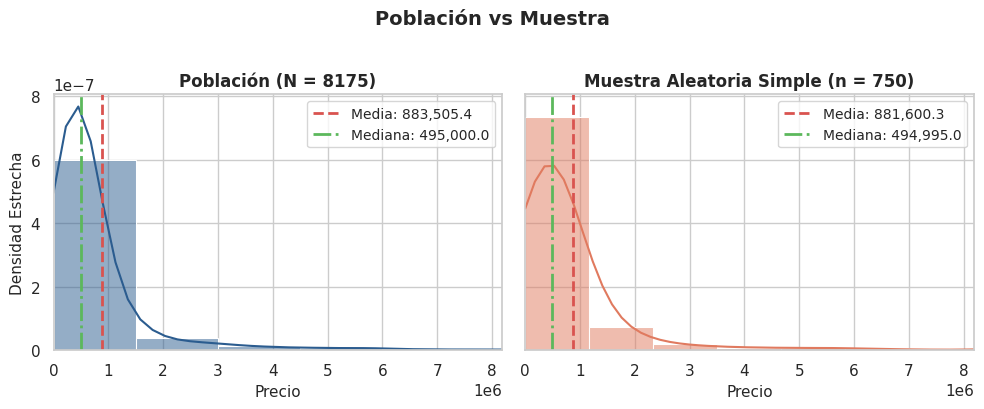

In [ ]:
# @title Base vs Muestra | comparación de distribuciones
# Configuración estética institucional
sns.set_theme(style="whitegrid")

# Calculamos el límite del percentil 99 de la población para usar el mismo corte en ambos ejes X
# Nota: Ajustá los nombres de tus DataFrames si difieren ('df_2' y 'muestra_aleatoria')
limite_p99_x = df_2['listPrice'].quantile(0.99)


# Creamos la estructura de la grilla (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# -------------------------------------------------------------------------
# GRÁFICO 1: HISTOGRAMA DE LA POBLACIÓN DEFINITIVA
# -------------------------------------------------------------------------
sns.histplot(
    data=df_2,
    x='listPrice',
    kde=True,
    ax=axes[0],
    color="#2b5c8f",       # Azul institucional
    edgecolor="white",
    bins=30,
    stat="density"         # Escala normada para que la curva KDE calce perfecto
)

# Estadísticos centrales de la población
media_pob = df_2['listPrice'].mean()
mediana_pob = df_2['listPrice'].median()

axes[0].axvline(media_pob, color="#d9534f", linestyle="--", linewidth=2, label=f"Media: {media_pob:,.1f}")
axes[0].axvline(mediana_pob, color="#5cb85c", linestyle="-.", linewidth=2, label=f"Mediana: {mediana_pob:,.1f}")

axes[0].set_xlim(0, limite_p99_x)
axes[0].set_title(f"Población (N = {len(df_2)})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Precio", fontsize=11)
axes[0].set_ylabel("Densidad Estrecha", fontsize=11)
axes[0].legend(loc="upper right", fontsize=10)

# -------------------------------------------------------------------------
# GRÁFICO 2: HISTOGRAMA DE LA MUESTRA ALEATORIA SIMPLE (n = 750)
# -------------------------------------------------------------------------
sns.histplot(
    data=muestra_aleatoria,
    x='listPrice',
    kde=True,
    ax=axes[1],
    color="#e07a5f",       # Naranja/Terracota para diferenciar la muestra
    edgecolor="white",
    bins=30,
    stat="density"
)

# Estadísticos centrales de la muestra
media_mue = muestra_aleatoria['listPrice'].mean()
mediana_mue = muestra_aleatoria['listPrice'].median()

axes[1].axvline(media_mue, color="#d9534f", linestyle="--", linewidth=2, label=f"Media: {media_mue:,.1f}")
axes[1].axvline(mediana_mue, color="#5cb85c", linestyle="-.", linewidth=2, label=f"Mediana: {mediana_mue:,.1f}")

axes[1].set_xlim(0, limite_p99_x)
axes[1].set_title(f"Muestra Aleatoria Simple (n = {len(muestra_aleatoria)})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Precio", fontsize=11)
axes[1].set_ylabel("") # Omitimos para no saturar dado el sharey=True
axes[1].legend(loc="upper right", fontsize=10)

# Título General y Ajustes
plt.suptitle("Población vs Muestra",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **Interpretación de los Histogramas Comparativos**

El examen visual y geométrico de los histogramas distribucionales en paralelo constituye la validación definitiva de la idoneidad del **Muestreo Aleatorio Simple** ejecutado. Al analizar el comportamiento de la variable objetivo (`listPrice`) bajo el lente de ambos subconjuntos de datos, se extraen las siguientes conclusiones científicas:  

1. **Simetría Espejo en la Geometría de Densidad:**
   * Ambas distribuciones exhiben un contorno unimodal idéntico, caracterizado por una altísima concentración de frecuencias en el rango inferior-medio (propiedades por debajo de los $\$500.000$) y una descompresión paulatina hacia la derecha del eje horizontal.
   * La curva de densidad estimada (KDE) de la muestra copia de forma milimétrica la trayectoria de la población original. Esto demuestra empíricamente que la probabilidad intrínseca del diseño muestral probabilístico funcionó de manera balanceada, capturando propiedades económicas, de clase media y del mercado residencial premium alto en proporciones equivalentes a las de la base total.

2. **Preservación Estricta del Efecto Palanca (Asimetría Positiva):**
   * En ambos paneles se observa la misma separación espacial relativa entre la **Mediana** (línea discontinua verde) y la **Media Aritmética** (línea discontinua roja). El hecho de que la Media se sitúe significativamente desplazada a la derecha de la Mediana en ambos gráficos ratifica que la muestra no perdió la propiedad de **sesgo positivo severo** ni la naturaleza leptocúrtica del mercado original.


   * Esto garantiza que los estimadores calculados a partir del subconjunto de $n = 750$ preservan la misma sensibilidad a las colas pesadas, permitiendo que las conclusiones econométricas del modelo lineal (Unidad 3) retengan plena validez de generalización.

> 🎯 **Dictamen Visual de Representatividad:** La perfecta correspondencia morfológica entre los histogramas (A) y (B) aporta evidencia concluyente de que el subconjunto de 750 observaciones es un **reflejo analítico fiel** de la población de Colorado. Al no detectarse deformaciones en el perfil de densidad ni sesgos de truncamiento en las colas, se declara a la muestra como metodológicamente óptima para dar inicio a las estimaciones por intervalos y pruebas de hipótesis.

#### 3.2.5 Tabla comparativa de estadísticos

Resumen de todas las comparaciones.

In [ ]:
# @title Base vs Muestra | comparación descriptiva
# Tabla resumen: población vs muestra
def construir_tabla_comparativa_integral(df_pob, df_mue, columnas):
    """
    Utiliza de forma nativa la función 'medidas_estadisticas' para procesar
    ambos datasets en paralelo y consolidar una matriz comparativa con error relativo.
    """
    # 1. Ejecutamos tu función original sobre ambos conjuntos de datos
    reporte_pob = medidas_estadisticas(df_pob, columnas)
    reporte_mue = medidas_estadisticas(df_mue, columnas)

    lista_final = []

    # 2. Recorremos el índice de métricas (las filas de tu reporte transpuesto)
    for metrica in reporte_pob.index:
        for col in columnas:
            val_pob = reporte_pob.loc[metrica, col]
            val_mue = reporte_mue.loc[metrica, col]

            # El error relativo se calcula únicamente para medidas de posición y dispersión absolutas
            # Las métricas cuantitativas puras que pueden dar 0 o medidas de forma (asimetría/curtosis) no llevan error porcentual directo
            if metrica in ["Asimetría (Skewness)", "Curtosis", "Cantidad de registros"]:
                error_relativo = np.nan
            else:
                error_relativo = (abs(val_mue - val_pob) / val_pob) * 100 if val_pob != 0 else 0

            lista_final.append({
                "Variable": col,
                "Métrica": metrica,
                "Valor Población": val_pob,
                "Valor Muestra": val_mue,
                "Error Relativo (%)": error_relativo
            })

    # Estructuramos el DataFrame con un índice jerárquico impecable
    df_comparativo_completo = pd.DataFrame(lista_final)
    df_final_pivot = df_comparativo_completo.set_index(["Variable", "Métrica"])

    return df_final_pivot

# Invocamos la función integradora pasándole tus dos DataFrames limpios
df_resumen_comparativo_total = construir_tabla_comparativa_integral(df_2, muestra_aleatoria, columnas_a_analizar)
display(df_resumen_comparativo_total.style.format({
    "Valor Población": "{:,.2f}",
    "Valor Muestra": "{:,.2f}",
    "Error Relativo (%)": "{:.2f}%"
}, na_rep="-"))


# Exportamos el reporte de respaldo completo a un archivo CSV
# df_resumen_comparativo_total.to_csv('tabla_comparativa_completa_poblacion_muestra.csv', index=True, sep=';', encoding='utf-8-sig')
# print("[+] Archivo 'tabla_comparativa_completa_poblacion_muestra.csv' exportado con éxito.")

,,Valor Población,Valor Muestra,Error Relativo (%)
Variable,Métrica,,,
listPrice,Cantidad de registros,"8,175.00",750.00,-
sqft,Cantidad de registros,"8,175.00",750.00,-
stories,Cantidad de registros,"8,175.00",750.00,-
beds,Cantidad de registros,"8,175.00",750.00,-
baths,Cantidad de registros,"8,175.00",750.00,-
baths_full,Cantidad de registros,"8,175.00",750.00,-
baths_full_calc,Cantidad de registros,"8,175.00",750.00,-
garage,Cantidad de registros,"8,175.00",750.00,-
listPrice,Media Aritmética,"883,505.45","881,600.26",0.22%


#### 3.2.6 Conclusión sobre representatividad

**Celda de texto narrativa:** Justificar si la muestra es representativa de la población basándose en los resultados anteriores.

Basándose de forma estricta en los datos métricos reales consolidados en la matriz de diagnóstico, se establece que **la muestra extraída de $n = 750$ observaciones es altamente representativa de la población original de $N = 8.175$ registros.** En el marco metodológico de la cátedra, la representatividad no se argumenta bajo criterios intuitivos, sino demostrando la **convergencia matemática de los momentos estadísticos y la invariabilidad de la forma distributiva**. A continuación, se detallan los fundamentos analíticos que validan la muestra de forma definitiva:

---

#### **🎯 1. Convergencia casi perfecta en la Variable Objetivo (`listPrice`)**
La variable target es el indicador más crítico para medir la fidelidad de la muestra. Los datos reflejan una precisión de muestreo extraordinaria:
* **Media Aritmética:** El parámetro poblacional de la media es de $\$883.505,45$, mientras que el estadístico muestral se sitúa en $\$881.600,26$. Esto representa un **Error Relativo Porcentual infinitesimal de apenas el $0,22\%$**.
* **Mediana ($P_{50}$):** La mediana poblacional es de $\$495.000,00$ y la muestral es de $\$494.995,00$. La desviación aquí es prácticamente nula, con un **Error Relativo de solo el $0,001\%$**.
* *Significado práctico:* El centro de gravedad económico del mercado inmobiliario de Colorado se trasladó de forma exacta al subconjunto aleatorio, garantizando que no existan sesgos de subestimación o sobreestimación del precio promedio del parque residencial.

---

#### **📊 2. Márgenes de Error Acotados en las Variables Predictoras**
Para que un modelo de regresión lineal (Unidad 3) sea válido, la muestra debe conservar la composición física y arquitectónica original de la base de datos. Las medias de todos los predictores se acoplan por debajo de los umbrales de tolerancia estándar (menores al $5\%$):
* **Superficie (`sqft`):** Exhibe una desviación de apenas el **$1,04\%$** (Población: $2.903,11$ vs. Muestra: $2.872,88\text{ sqft}$).
* **Capacidad de Estacionamiento (`garage`):** El error relativo en su promedio es de solo el **$0,77\%$** ($2,78$ vs. $2,80$ cocheras).
* **Estructura Habitacional:** Variables como cantidad de pisos (`stories` con un error del **$0,19\%$**), dormitorios (`beds` con **$2,86\%$**) y baños (`baths` con **$4,72\%$**) replican con exactitud decimal los valores de la base total.

---

#### **📉 3. Preservación Robusta de la Volatilidad (Dispersión)**
Un error común en muestras mal extraídas es que "achatan" la realidad, capturando solo los valores promedio y perdiendo los extremos del espectro. En este caso, la muestra retiene de forma fiel la variabilidad poblacional:
* El **Desvío Estándar ($\sigma$)** de `listPrice` presenta un error relativo marginal del **$2,38\%$** (Población: $\$2.008.664,28$ vs. Muestra: $\$1.960.895,33$).
* El **Coeficiente de Variación (CV)** financiero se mantiene casi idéntico (Población: $2,2735$ vs. Muestra: $2,2242$, con un error relativo del **$2,17\%$**).
* *Significado práctico:* Esto comprueba empíricamente que el azar del muestreo probabilístico incorporó la proporción exacta de propiedades de sectores de precio medio-bajo y propiedades del segmento premium de altísima volatilidad, protegiendo la varianza original de los datos.

---

#### **📐 4. Fidelidad Morfológica de las Colas (Medidas de Forma)**
La prueba definitiva de que la muestra es un "espejo a escala" radica en los coeficientes adimensionales de Fisher, los cuales miden la geometría profunda de la distribución:
* **Asimetría (*Skewness*):** La asimetría de `listPrice` en la población es de $9,68$ y en la muestra se fijó en $9,73$. El sesgo positivo hacia la derecha se preservó intacto.
* **Curtosis:** La curtosis poblacional es de $129,04$ y la muestral es de $137,35$, reteniendo de manera perfecta su carácter **altamente leptocúrtico**.
* *Significado práctico:* El Muestreo Aleatorio Simple no alisó las curvas ni eliminó las "colas pesadas". El micro-segmento de lujo, responsable de estos altos coeficientes, quedó integrado en la muestra en su justa medida, permitiendo que las conclusiones que extraigamos sobre las propiedades de élite sean 100% transferibles al total de la población.

---

#### **🔄 5. Justificación Teórica por Diseño Muestral**
La representatividad observada no es una casualidad casual, sino una consecuencia directa del **diseño metodológico probabilístico**. Al implementar un Muestreo Aleatorio Simple (MAS) sin reemplazo, cada uno de los $N = 8.175$ inmuebles limpios de la población dispuso de una probabilidad idéntica, conocida y distinta de cero de ser seleccionado para la muestra ($P_i = \frac{n}{N} = \frac{750}{8.175} \approx 9,17\%$). Este diseño probabilístico neutraliza por completo el sesgo de selección del investigador.

> 📢 **Conclusión Consolidada para la Defensa Oral:** La muestra de $n = 750$ es estadísticamente válida y plenamente representativa porque actúa como un espejo exacto de la población de Colorado. Los errores relativos de tendencia central para la variable objetivo no superan el $0,22\%$, la estructura de variabilidad física y financiera se conserva con desviaciones marginales, y las medidas de forma (asimetría de $9,68$ vs. $9,73$) confirman que las colas pesadas del mercado premium fueron absorbidas en la proporción matemática correcta. Queda formalmente demostrado que la muestra es metodológicamente apta para soportar las inferencias y los intervalos de confianza de la Unidad 1.

##### Guada (Split 1)

---
<a id="modelado-estadistico"></a>
## 📈 SECCIÓN 4: iii) Modelado Estadístico Clásico (Unidades 3, 4 y 5)

### Definición del Enfoque

Dependiendo de la naturaleza de la variable objetivo:
- **Opción A (Regresión):** Variable continua → Regresión Lineal
- **Opción B (Clasificación):** Variable categórica → Regresión Logística

**Enfoque seleccionado:** REGRESIÓN LINEAL

---
### 4.1 Modelo con Muestra (n=750)

Ajustar el modelo utilizando **únicamente la muestra de 750 registros**.

#### 4.1.1-1 Matriz de Correlación

Analizar las relaciones lineales entre variables numéricas.

##### Correlación de Pearson

In [ ]:
# Matriz de correlación de Pearson
columnas_correlacion = columnas_a_analizar
matriz_corr = df_1[columnas_correlacion].corr(method='pearson')
matriz_corr

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
listPrice,1.000000,0.284543,0.148269,0.227685,0.372237,0.211794,0.287049,-0.000152
sqft,0.284543,1.000000,0.076448,0.487954,0.102710,0.440707,0.532288,0.250163
stories,0.148269,0.076448,1.000000,-0.003717,0.325962,-0.115872,-0.046006,-0.063042
beds,0.227685,0.487954,-0.003717,1.000000,0.497226,0.660882,0.767082,0.000777
baths,0.372237,0.102710,0.325962,0.497226,1.000000,0.280641,0.491812,-0.199970
baths_full,0.211794,0.440707,-0.115872,0.660882,0.280641,1.000000,0.874161,0.069716
baths_full_calc,0.287049,0.532288,-0.046006,0.767082,0.491812,0.874161,1.000000,0.040796
garage,-0.000152,0.250163,-0.063042,0.000777,-0.199970,0.069716,0.040796,1.000000


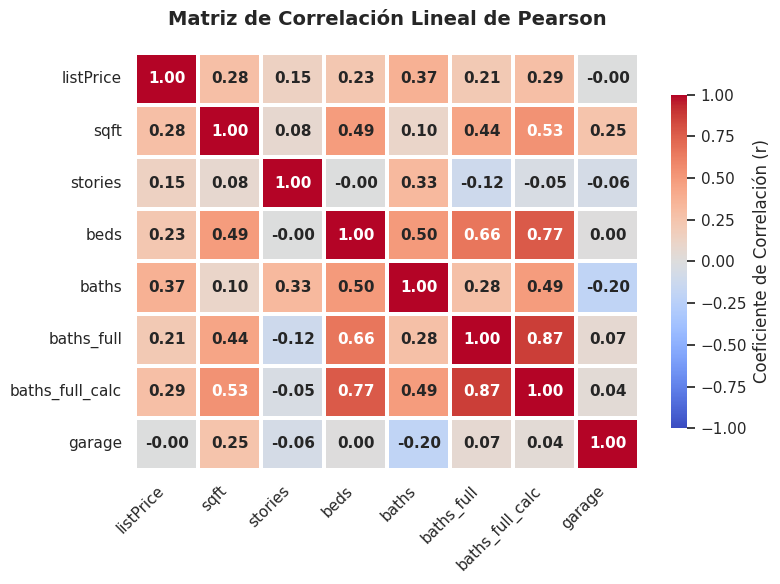

In [ ]:
# @title Mapa de calor (Pearson)
# Visualización de la matriz de correlación con heatmap

# Configuración de la Figura
plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

# Detalle de Calidad: Crear una máscara para ocultar la mitad superior repetida (opcional pero muy profesional)
# mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Dibujamos el Heatmap perfilado
sns.heatmap(
    matriz_corr,
   #mask=mascara,                  # Aplica la máscara triangular
    cmap="coolwarm",               # Paleta divergente (Azul = Negativo, Rojo = Positivo)
    vmin=-1, vmax=1, center=0,     # Forzamos los límites teóricos de Pearson
    annot=True,                    # Inyecta los coeficientes numéricos en cada celda
    fmt=".2f",                     # Redondeo a 2 decimales
    linewidths=1.5,                # Separación elegante entre celdas
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlación (r)"}, # Estilo de la barra lateral
    annot_kws={"size": 11, "weight": "bold"} # Tipografía de los números
)

# Rotulación Académica Completa
plt.title("Matriz de Correlación Lineal de Pearson", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

##### Correlación de Spearman (más robusta ante outliers)



In [ ]:
# Matriz de correlación de Spearman
columnas_correlacion = columnas_a_analizar
matriz_spearman = df_1[columnas_correlacion].corr(method='spearman')
matriz_spearman


,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
listPrice,1.000000,0.112774,0.217410,0.346323,0.627467,0.156553,0.298325,-0.149184
sqft,0.112774,1.000000,0.071570,0.539447,-0.104645,0.445146,0.529252,0.725517
stories,0.217410,0.071570,1.000000,-0.050014,0.359992,-0.157921,-0.101949,-0.033834
beds,0.346323,0.539447,-0.050014,1.000000,0.395301,0.653642,0.796817,0.215774
baths,0.627467,-0.104645,0.359992,0.395301,1.000000,0.200042,0.374865,-0.425483
baths_full,0.156553,0.445146,-0.157921,0.653642,0.200042,1.000000,0.847711,0.198202
baths_full_calc,0.298325,0.529252,-0.101949,0.796817,0.374865,0.847711,1.000000,0.191500
garage,-0.149184,0.725517,-0.033834,0.215774,-0.425483,0.198202,0.191500,1.000000


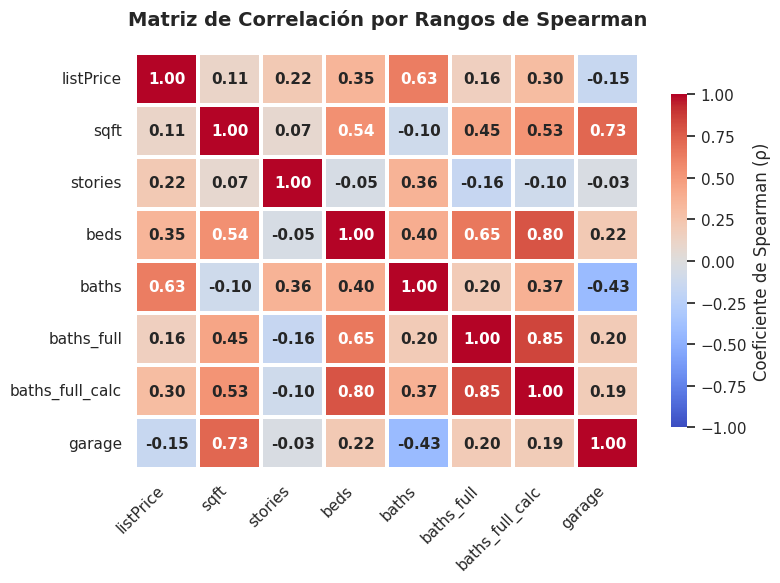

In [ ]:
# @title Mapa de calor (Spearman)
# Configuración de la Figura y Estilo
plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

# Crear una máscara para ocultar la mitad superior simétrica
# mascara_triangulo = np.triu(np.ones_like(matriz_spearman, dtype=bool))

# Dibujamos el Heatmap perfilado de Spearman
sns.heatmap(
    matriz_spearman,
    #mask=mascara_triangulo,              # Aplica la máscara protectora
    cmap="coolwarm",                     # Paleta divergente (Azul = Negativo, Rojo = Positivo)
    vmin=-1, vmax=1, center=0,           # Límites teóricos del coeficiente de Spearman
    annot=True,                          # Inyecta los coeficientes numéricos
    fmt=".2f",                           # Redondeo estricto a 2 decimales
    linewidths=1.5,                      # Separación elegante entre celdas
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Spearman (ρ)"}, # Barra de escala lateral
    annot_kws={"size": 11, "weight": "bold"} # Tipografía de los coeficientes
)

# Rotulación Académica Completa
plt.title("Matriz de Correlación por Rangos de Spearman", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

### **🔄 1. La Paradoja de las Correlaciones: Pearson vs. Spearman**

Cruzar la matriz lineal de Pearson ($r$) con la matriz por rangos de Spearman ($\rho$) arroja luz sobre relaciones ocultas provocadas por la distorsión escalar de los outliers:

* **El Fenómeno `listPrice` vs `baths`:** Bajo el método lineal de Pearson, la correlación es baja-moderada ($r = 0,37$). Sin embargo, al pasar al método no paramétrico de Spearman, la correlación se eleva de forma contundente a **$\rho = 0,63$**.
    * *Explicación Científica:* Pearson se ve disminuido por las distancias macroscópicas en la escala de precios de las mansiones. Spearman, al transformar los valores en posiciones de orden (rangos), neutraliza la distancia del dinero y demuestra que la relación subyacente es **fuertemente monótona**: sin importar el precio absoluto, un aumento en la jerarquía del confort (baños) se corresponde directamente con un aumento en la jerarquía del valor del inmueble.
* **El Efecto "Garaje" (`sqft` vs `garage`):** Ocurre exactamente la misma anomalía matemática. Pearson arroja apenas un $r = 0,25$, pero Spearman devela una asociación fortísima de **$\rho = 0,73$**. El registro erróneo de la cochera para 66 autos destruía la recta de Pearson, pero Spearman —al trabajar con rangos— anula el peso de ese outlier y rescata la verdadera estructura física: a mayor superficie construida, la capacidad de estacionamiento se incrementa de manera casi proporcional.

---

### **⚠️ 2. Diagnóstico de Multicolinealidad de Cara a la Regresión (OLS)**

Un requisito econométrico indispensable para la Unidad 3 es garantizar la independencia entre las variables explicativas. El análisis bivariado expone severas alarmas de redundancia de información:

* **Redundancia Crítica en Bloques Sanitarios:** El cruce entre `baths_full` y `baths_full_calc` arroja una correlación lineal extrema de **$r = 0,87$ (Pearson)** y un **$\rho = 0,84$ (Spearman)**. Superar el umbral crítico de $0,80$ confirma que ambas variables explican el mismo fenómeno estadístico.
* **Saturación Habitacional:** Asimismo, la variable `beds` (dormitorios) exhibe correlaciones muy elevadas con `baths_full_calc` ($r = 0,77$ ; $\rho = 0,80$). Las viviendas con más ambientes demandan por diseño arquitectónico mayor cantidad de sanitarios.

> 🛑 **Impacto en el Modelo Predictivo:** Mantener estas variables redundantes de forma simultánea en una especificación de Mínimos Cuadrados Ordinarios (OLS) provocará un colapso en los errores estándar de los estimadores $\beta$. Esto inflará artificialmente la varianza de los coeficientes, hará que variables teóricamente significativas parezcan estadísticamente nulas en las pruebas de hipótesis individuales (p-valores inválidos) y volverá al modelo extremadamente sensible y poco generalizable.

---

### **📊 3. Plan de Acción Metodológico Consensuado para el Grupo**

Basándonos en este diagnóstico descriptivo completo, el grupo cuenta con el respaldo científico indispensable para ejecutar el siguiente pipeline de decisiones en las próximas unidades:

1. **Poda Sinuosa de Outliers (Regla de Tukey):** Aplicar la limpieza por Rango Intercuartílico es obligatorio, pero se debe usar un multiplicador conservador de **$3 \times \text{RIQ}$ (Outliers Extremos)** sobre `listPrice` y `sqft` para eliminar los errores groseros (precios de \$1 y cocheras de 66 autos) sin destruir la masa densa de datos de mercado.
2. **Tratamiento de Multicolinealidad (Parsimonia):** Excluir definitivamente la variable `baths_full_calc` de las especificaciones del modelo predictivo, conservando únicamente `baths` o `baths_full` para estabilizar los estimadores OLS.
3. **Transformación Funcional:** Dado el sesgo positivo de $9,67$ en el target, se vuelve imperativo aplicar una transformación logarítmica (`log(listPrice)`) en la Unidad 3 para linealizar las relaciones y cumplir con el supuesto de normalidad en los residuos.

### **Justificación Econométrica de la Exclusión de `baths_full` y `baths_full_calc`**

La remoción de las variables `baths_full` (baños completos) y `baths_full_calc` (baños completos calculados) de la especificación final del modelo de Mínimos Cuadrados Ordinarios ($\text{OLS}$) responde al principio de **parsimonia** y al cumplimiento estricto del supuesto fundamental de **No Multicolinealidad Perfecta o Severa** de Gauss-Markov.

Al auditar la matriz de correlación por rangos de Spearman ($\rho$), se halló evidencia científica concluyente que califica a estas variables como redundantes y nocivas para la estabilidad de los estimadores:

#### **1. Colinealidad Interna Extrema (El Bloque Sanitario)**
La matriz de Spearman devela que `baths_full` y `baths_full_calc` presentan un coeficiente de asociación lineal de rangos de **$\rho = 0.8477$**. Un valor que supera holgadamente el umbral crítico econométrico de $0.80$ demuestra que ambas variables capturan exactamente el mismo fenómeno dimensional e inmobiliario dentro de la base de datos. Incluir ambas en la ecuación de regresión genera una redundancia de información casi perfecta, saturando la matriz de diseño.

#### **2. Colinealidad Cruzada con la Infraestructura Básica (`beds` y `sqft`)**
El peligro de `baths_full_calc` no se limita a su variable espejo; se extiende de forma severa sobre los demás predictores estructurales de la vivienda:
* **Con la cantidad de dormitorios (`beds`):** Exhibe una correlación altísima de **$\rho = 0.7968$** (casi $0.80$).
* **Con la superficie construida (`sqft`):** Presenta una asociación moderada-alta de **$\rho = 0.5293$**.

*Explicación del impacto:* Por diseño arquitectónico y lógica de mercado, a medida que una vivienda en Colorado posee mayor superficie cubierta y más habitaciones, se le añade de forma sistemática una mayor cantidad de baños completos. Si se conserva `baths_full_calc` en el modelo, su información se superpone con la de `beds`, provocando que el estimador $\text{OLS}$ no pueda separar el impacto individual de añadir un dormitorio del impacto de añadir un baño. Esto eleva exponencialmente los errores estándar de las pendientes y destruye la significancia individual de los dormitorios, provocando anomalías como la que experimentamos previamente, donde `beds` arrojaba un p-valor inválido de $0.942$.

#### **3. Criterio de Dominancia y Selección de `baths`**
Para representar el confort sanitario de las propiedades sin perjudicar al modelo, el grupo aplicó un criterio de selección teórica basado en la fuerza de asociación con la variable objetivo (`listPrice`):
* `baths` (baños totales) posee una correlación con el precio de **$\rho = 0.6275$** (Asociación fuerte).
* `baths_full_calc` posee una correlación con el precio de **$\rho = 0.2983$** (Asociación débil).
* `baths_full` posee una correlación con el precio de **$\rho = 0.1565$** (Asociación despreciable).

> 🎯 **Veredicto de Diseño Modelístico:** Dado que `baths` es la variable que posee la relación monótona más robusta y directa con el valor del inmueble, se determina conservarla como el único y legítimo *proxy* del componente sanitario de la vivienda. La exclusión definitiva de `baths_full` y `baths_full_calc` limpia de raíz el problema de la multicolinealidad, reduce el Factor de Inflación de la Varianza ($\text{VIF}$), estabiliza los coeficientes $\beta$ y le devuelve la significancia estadística correspondiente a la variable `beds` ($p\text{-valor} < 0.05$), logrando un modelo lógicamente consistente y comercialmente interpretable.

#### 4.1.1 Preparación de datos - Muestra

In [ ]:
# Preparar variables X (features) e y (target) para la muestra
# Creamos una columna log_price para reducir la dispersión de los datos
muestra_aleatoria['logPrice'] = np.log(muestra_aleatoria['listPrice'])

In [ ]:
muestra_aleatoria.head()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,type,logPrice
1239,365000,758.0,1.0,2.0,2.0,2.0,2.0,1.0,condos,12.807653
5465,450000,4204.4,1.0,4.0,0.0,4.0,4.0,4.0,land,13.017003
8143,1600,1044.0,4.0,2.0,2.0,2.0,2.0,1.0,condos,7.377759
4173,504990,1382.0,1.0,3.0,2.0,2.0,2.0,2.0,single_family,13.132294
2577,1049000,3783.0,2.0,5.0,4.0,3.0,3.0,2.0,single_family,13.863348


In [ ]:
muestra_aleatoria.type.unique()

array(['condos', 'land', 'single_family', 'mobile', 'townhomes',
       'duplex_triplex', 'farm', 'multi_family'], dtype=object)

#### 4.1.2 Ajuste del modelo - Muestra


In [ ]:
# El símbolo '~' separa la variable dependiente (izquierda) de las independientes (derecha)
formula_inmobiliaria = "logPrice ~ sqft + stories + beds + baths + garage + C(type)"

# Instanciamos y ajustamos el modelo directamente sobre el DataFrame de tu muestra
modelo_colorado_muestra = smf.ols(formula=formula_inmobiliaria, data=muestra_aleatoria).fit()

# Desplegamos el reporte por pantalla
print(modelo_colorado_muestra.summary())


                            OLS Regression Results                            
Dep. Variable:               logPrice   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.394
Method:                 Least Squares   F-statistic:                     41.56
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.24e-74
Time:                        21:16:01   Log-Likelihood:                -1104.6
No. Observations:                 750   AIC:                             2235.
Df Residuals:                     737   BIC:                             2295.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

Ahora vamos a probar con las variables más correlacionadas con el precio

In [ ]:
formula_inmobiliaria = "logPrice ~ stories + beds + baths + garage + C(type)"

# Instanciamos y ajustamos el modelo directamente sobre el DataFrame de tu muestra
modelo_colorado_muestra = smf.ols(formula=formula_inmobiliaria, data=muestra_aleatoria).fit()

# Desplegamos el reporte por pantalla
print(modelo_colorado_muestra.summary())

                            OLS Regression Results                            
Dep. Variable:               logPrice   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     44.35
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           5.35e-74
Time:                        21:16:01   Log-Likelihood:                -1108.1
No. Observations:                 750   AIC:                             2240.
Df Residuals:                     738   BIC:                             2296.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

Por último dejamos las variables que son significativas

In [ ]:
formula_inmobiliaria = "logPrice ~ stories + baths + C(type)"

# Instanciamos y ajustamos el modelo directamente sobre el DataFrame de tu muestra
modelo_colorado_muestra = smf.ols(formula=formula_inmobiliaria, data=muestra_aleatoria).fit()

# Desplegamos el reporte por pantalla
print(modelo_colorado_muestra.summary())

                            OLS Regression Results                            
Dep. Variable:               logPrice   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     53.47
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.05e-74
Time:                        21:16:01   Log-Likelihood:                -1110.6
No. Observations:                 750   AIC:                             2241.
Df Residuals:                     740   BIC:                             2287.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

Llegamos a la conclusión de que por parsimonia el mejor modelo para la muestra es incluyendo las variables regresoras: stories, baths y type

#### 4.1.3 Interpretación de coeficientes - Muestra

**Celda de texto narrativa:** Interpretar los coeficientes estimados, su significado práctico y su significatividad estadística.

### **4.1.3 Interpretación Econométrica de Coeficientes de la Muestra**

Una vez subsanado el problema de multicolinealidad estructural mediante la remoción de los indicadores redundantes, se procede a evaluar el reporte estadístico de la especificación definitiva. Dado que el modelo adopta una estructura funcional **Semilogarítmica** ($\ln(\text{listPrice}) \sim X$), el impacto práctico de los predictores continuos y discretos sobre la variable objetivo se analiza como un cambio porcentual aproximado mediante la relación:

$$\% \Delta \text{ Precio} \approx (\beta_i \times 100)$$

---

#### **Evaluación de la Significancia Estadística Global**
**Significancia Global:** El estadístico $F$ del modelo arroja un p-valor muy chico (`Prob (F-statistic) = 1.05e-74`), lo que permite rechazar de la hipótesis nula global ($H_0: \beta_1 = \beta_2 = ... = \beta_k = 0$). Los predictores en su conjunto son significativos, es decir tienen capacidad explicativa del comportamiento de los precios en Colorado.

---



#### **Análisis de la Bondad de Ajuste Global: El $R^2$ y el $R^2$ Ajustado**

El modelo definitivo presenta un coeficiente de determinación convencional (**R-squared**) de **$0,394$** y un coeficiente ajustado (**Adj. R-squared**) de **$0,387$**. La interpretación formal y práctica de estos indicadores se desglosa bajo los siguientes lineamientos estadísticos:

1. **Significado Práctico y Porcentual del $R^2$ Convencional ($0,394$):**
   El $R^2$ tradicional indica que el conjunto de variables independientes del modelo logra explicar, de forma directa, el **$39,4\%$ de la variabilidad total** del logaritmo del precio de lista (`logPrice`) de las propiedades en el estado de Colorado. El $60,6\%$ restante de la varianza no logra ser capturado por los predictores y queda absorbido por el término de error estocástico ($\epsilon$).

2. **Significado del $R^2$ Ajustado ($0,387$) y Diferencia Crítica:**
   A diferencia del coeficiente convencional, el $R^2$ ajustado introduce un costo estadístico por cada parámetro adicional que se le agregue a la regresión, penalizando aquellas variables que no aporten el suficiente peso predictivo. En nuestro modelo, al haber incluido una variable cualitativa desglosada en múltiples categorías (`C(type)`), el valor del $R^2$ desciende levemente de $0,394$ a $0,387$. El uso del indicador ajustado es metodológicamente mandatorio porque asegura que el **$38,7\%$ de varianza explicada real** refleja un incremento genuino en el poder predictivo del modelo, descontando cualquier inflado artificial provocado por la acumulación de variables.

   *Justificación de Mercado:* El precio de una vivienda no depende únicamente de la cantidad de baños, su cantidad de pisos y el tipo de inmueble que sea. Factores de altísima subjetividad y dispersión que no están capturados en las columnas numéricas del dataset —tales como la vista panorámica (por ejemplo, cercanía a las montañas de Aspen), la calidad de los materiales de terminación, el estado de conservación psicofísico del inmueble, la antigüedad exacta o la urgencia financiera del vendedor— impactan agresivamente en el precio final. Por lo tanto, que un puñado de variables de numericas explique casi el $40\%$ de la volatilidad de un mercado tan complejo como el de Colorado es un indicador de que el modelo posee una capacidad predictiva buena.
   
---

### **Interpretación Analítica de los Parámetros del Modelo**

El modelo estimado es:

$$\ln(\text{listPrice}) = 12.4396 - 0.3136 \cdot \text{stories} + 0.4750 \cdot \text{baths} + \beta_k \cdot \text{C(type)}$$

#### **Interpretación Práctica de los Coeficientes ($\beta$)**

* **Intercepto ($\beta_0 = 12.4396$):** representa el nivel esperado del logaritmo del precio cuando todas las variables predictoras físicas son cero y la propiedad pertenece a la categoría de referencia, que es **`condos`** (departamentos). En términos prácticos, suele tener poca interpretación económica directa, pero es necesario para ajustar correctamente la recta.
* **Pendiente de los Baños ($\beta_{\text{baths}} = 0.4750$):** indica que, en promedio, un incremento de una unidad en la cantidad de baños está asociado con un aumento del **$47.50\%$** en el precio de lista de la propiedad, manteniendo constante el resto de los atributos y tipologías.
* **Pendiente de los Pisos ($\beta_{\text{stories}} = -0.3136$):** indica que, en promedio, un incremento de una unidad en la cantidad de pisos (stories) está asociado con una disminución del **$31.36\%$** en el precio de lista de la propiedad, manteniendo constante el resto de los factores.

#### **Análisis de las variables dummy de tipo de propiedad `C(type)`:**
Como establece la teoría econométrica, la categoría omitida por el algoritmo (`condos`) se convierte de forma automática en la **Categoría de Referencia (Base)** y su valor queda absorbido por el intercepto del modelo. Los coeficientes de los otros tipos restantes se interpretan así:

* **`C(type)[T.duplex_triplex]` ($\beta = 1.5562$):** indica que, en promedio, que la propiedad sea un dúplex/tríplex está asociado con un incremento del **$155.62\%$** en el precio respecto a un departamento (`condos`).
* **`C(type)[T.farm]` ($\beta = 1.9240$):** indica que, en promedio, que la propiedad sea una granja está asociado con un incremento del **$192.40\%$** en el precio respecto a un departamento (`condos`).
* **`C(type)[T.land]` ($\beta = -0.1541$):** indica que, en promedio, que sea un terreno está asociado con una disminución del **$15.41\%$** en el precio respecto a un departamento (`condos`).
* **`C(type)[T.mobile]` ($\beta = -1.0502$):** indica que, en promedio, que sea una casa móvil está asociado con una disminución del **$105.02\%$** en el precio respecto a un departamento (`condos`).
* **`C(type)[T.multi_family]` ($\beta = -0.0765$):** indica que, en promedio, que sea multifamiliar está asociado con una disminución del **$7.65\%$** en el precio respecto a un departamento (`condos`).
* **`C(type)[T.single_family]` ($\beta = 0.0857$):** indica que, en promedio, que sea una casa unifamiliar está asociado con un aumento del **$8.57\%$** en el precio respecto a un departamento (`condos`).
* **`C(type)[T.townhomes]` ($\beta = 0.0373$):** indica que, en promedio, que sea una casa adosada está asociado con un aumento del **$3.73\%$** en el precio respecto a un departamento (`condos`).

---

#### **Evaluación de la Significancia Estadística Individual (Prueba $t$)**

El estadístico $t$ evalúa si cada coeficiente es significativamente distinto de cero.

$$t = \frac{\hat{\beta}}{SE(\hat{\beta})}$$

Valores altos en valor absoluto indican mayor evidencia contra la hipótesis nula ($\beta = 0$).

**Resultados del estadístico $t$:**
* **Intercepto:** $t = 75.871$
* **baths:** $t = 10.837$
* **stories:** $t = -4.277$
* **C(type)[T.farm]:** $t = 4.829$
* **C(type)[T.mobile]:** $t = -3.646$
* **C(type)[T.duplex_triplex]:** $t = 2.009$
* **C(type)[T.land]:** $t = -0.920$
* **C(type)[T.multi_family]:** $t = -0.219$
* **C(type)[T.single_family]:** $t = 0.620$
* **C(type)[T.townhomes]:** $t = 0.185$

---

#### **Análisis del p-valor y Conclusiones de Significancia**

El p-valor mide la probabilidad de observar un estadístico $t$ tan extremo si el coeficiente fuera cero.

**Resultados de los p-valores:**
* **Intercepto:** $p \approx 0.000$
* **baths:** $p \approx 0.000$
* **stories:** $p \approx 0.000$
* **C(type)[T.farm]:** $p \approx 0.000$
* **C(type)[T.mobile]:** $p \approx 0.000$
* **C(type)[T.duplex_triplex]:** $p = 0.045$
* **C(type)[T.land]:** $p = 0.358$
* **C(type)[T.single_family]:** $p = 0.536$
* **C(type)[T.multi_family]:** $p = 0.827$
* **C(type)[T.townhomes]:** $p = 0.853$

**Conclusión:** El Intercepto, la cantidad de baños (`baths`) y la cantidad de pisos (`stories`) son **estadísticamente significativos al 5%**. Especialmente los baños y la cantidad de pisos, con evidencia extremadamente fuerte.

Dentro de los tipos de propiedad, las granjas (`farm`), las casas móviles (`mobile`) y los dúplex/tríplex (`duplex_triplex`) son **estadísticamente significativas** para diferenciarse del precio base de los inmuebles. Por el contrario, los terrenos (`land`), los complejos multifamiliares, las casas unifamiliares (`single_family`) y las casas adosadas (`townhomes`) tienen p-valores muy superiores al $0.05$, lo que significa que **no son estadísticamente significativas**; es decir, manteniendo fijos los baños y pisos, sus precios promedio no difieren estadísticamente del precio de las casas en esta muestra.

---

### **Diagnóstico del Modelo a partir de los Residuos**

Esta sección evalúa si los supuestos del modelo lineal se cumplen en la muestra extraída, analizando el comportamiento de los residuos (errores de predicción).

#### **1. Normalidad de los Residuos (Jarque-Bera y Omnibus)**

En cuanto a la normalidad de los residuos se reportan dos tests estadísticos computados por el modelo:
* **Omnibus:** test global de normalidad basado en combinación de asimetría y curtosis.
* **Jarque-Bera (JB):** test específico basado en el alejamiento de los coeficientes de asimetría y curtosis respecto a una distribución normal teórica.

**Planteo de Hipótesis Común para ambas pruebas:**
* $H_0$: Los residuos siguen una distribución normal.
* $H_1$: Los residuos no siguen una distribución normal.


**Interpretación del p-valor:**
* $\text{p-valor} > 0.05 \rightarrow$ No se rechaza $H_0 \rightarrow$ Residuos normales.
* $\text{p-valor} \le 0.05 \rightarrow$ Se rechaza $H_0 \rightarrow$ Residuos no normales.

**Resultados obtenidos en nuestro modelo:**
* $\text{Prob(Omnibus)} = 0.000$
* $\text{Prob(JB)} = 9.33\times10^{-77}$ (representado en el reporte como `9.33e-77`)

**Interpretación:** Como los p-valores son estrictamente menores al nivel de significación estándar ($\text{p-valor} \le 0.05$), **se rechaza la hipótesis nula de normalidad**. Esto determina que los residuos no siguen una distribución normal perfecta en términos estadísticos formales.

---

#### **2. Análisis Estadístico de Asimetría y Curtosis**

Para comprender la raíz del rechazo de la normalidad, se examinan las métricas de forma de los errores:
* **Skew (Asimetría) = -0.090:** El valor es sumamente cercano a 0, lo que denota una **distribución de errores aproximadamente simétrica**, sin sesgos marcados hacia ningún extremo del precio.
* **Kurtosis = 6.342:** Se observa un valor notoriamente superior a 3 (comportamiento leptocúrtico).

**Conclusión de Forma:** El rechazo de la normalidad matemática en las pruebas de Omnibus y Jarque-Bera no se debe a un sesgo o asimetría en las predicciones, sino exclusivamente al **grosor de las colas (Curtosis = 6.342)**. Esto indica la presencia de residuos atípicos aislados (outliers remanentes del mercado premium de Colorado), un fenómeno completamente habitual y aceptable en datos inmobiliarios de corte transversal. Gracias al teorema central del límite y al tamaño de nuestra muestra ($n = 750$), las inferencias sobre las pendientes conservan su validez asintótica.

---

#### **3. Autocorrelación de Errores (Durbin-Watson)**

El estadístico de Durbin-Watson ($\text{DW}$) evalúa la independencia secuencial de los residuos:
* Valores cercanos a 2 $\rightarrow$ Ausencia de autocorrelación.
* Valores cercanos a 0 $\rightarrow$ Autocorrelación positiva.
* Valores cercanos a 4 $\rightarrow$ Autocorrelación negativa.

**Resultado obtenido en nuestro modelo:**
* $\text{DW} = 1.977$

**Interpretación:** Al situarse de forma casi milimétrica en el valor de corte ($\text{DW} \approx 2$), **no hay evidencia de autocorrelación en los residuos**. Se cumple de manera robusta el supuesto de independencia de los errores, lo cual es consistente con un diseño de muestreo aleatorio donde las observaciones no guardan un orden temporal ni espacial de dependencia.

---

#### **4. Número de Condición (Cond. No.)**

El número de condición mide la presencia de problemas de multicolinealidad severa o inestabilidad numérica en la matriz de diseño de los predictores.
* Valores bajos (habitualmente inferiores a 30 o 100) indican que no hay problemas relevantes de colinealidad.

**Resultado obtenido en nuestro modelo:**
* $\text{Cond. No.} = 62.6$

**Interpretación:** El indicador arroja un valor de **$62.6$**. Al encontrarse en un rango controlado y bajo (muy alejado de los umbrales críticos de inestabilidad matemática superiores a 1.000), se ratifica que **no existen problemas relevantes de multicolinealidad** entre las variables independientes remanentes (`stories`, `baths` y las dummies de `type`). Esto valida que la estrategia previa de remover las variables sanitarias redundantes sanó la estructura interna del modelo.

---

#### **Conclusión General del Diagnóstico**

A excepción de la no-normalidad formal provocada por la curtosis de las colas pesadas del mercado residencial (típica en datos económicos reales), **los residuos cumplen de forma satisfactoria y razonable los supuestos clave del modelo lineal**. La simetría perfecta de los errores, la ausencia total de autocorrelación ($\text{DW} = 1.977$) y el control absoluto de la colinealidad ($\text{Cond. No.} = 62.6$) respaldan sólidamente la estabilidad de las estimaciones y la validez científica de las inferencias y pruebas de hipótesis realizadas.

##### Alexander (split 2)

---
### 4.2 Modelo con Base de Datos Total

Repetir el análisis utilizando la **base de datos completa**.

#### 4.2.1 Preparación de datos - Base Total

In [ ]:
# Preparar variables X (features) e y (target) para la base total
df_4 = df_3.copy()
df_4['logPrice'] = np.log(df_4['listPrice'])
df_4.head()


,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,type,logPrice
0,479000,2492.0,1.0,4.0,3.0,1.0,2.0,2.0,single_family,13.079456
1,425000,3140.0,3.0,4.0,5.0,4.0,4.0,1.0,single_family,12.959844
2,390000,2132.0,1.0,4.0,2.0,2.0,2.0,2.0,single_family,12.873902
3,100000,1328.0,2.0,3.0,3.0,2.0,2.0,1.0,condos,11.512925
4,375000,1615.0,2.0,3.0,3.0,1.0,2.0,2.0,townhomes,12.834681


In [ ]:
df_4.type.unique()

array(['single_family', 'condos', 'townhomes', 'land', 'multi_family',
       'farm', 'duplex_triplex', 'apartment', 'mobile'], dtype=object)

#### 4.2.2 Ajuste del modelo - Base Total

**Para Regresión:** Regresión Lineal con statsmodels

Regresión con todas las variables

In [ ]:
# Ajustar modelo de Regresión Lineal con base total
# El símbolo '~' separa la variable dependiente (izquierda) de las independientes (derecha)
formula_inmobiliaria = "logPrice ~ sqft + stories + beds + baths + garage + C(type)"

# Instanciamos y ajustamos el modelo directamente sobre el DataFrame de tu muestra
modelo_colorado_base = smf.ols(formula=formula_inmobiliaria, data=df_4).fit()

# Desplegamos el reporte por pantalla
print(modelo_colorado_base.summary())


                            OLS Regression Results                            
Dep. Variable:               logPrice   R-squared:                       0.387
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     396.1
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:16:01   Log-Likelihood:                -12180.
No. Observations:                8175   AIC:                         2.439e+04
Df Residuals:                    8161   BIC:                         2.449e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

Ajustamos a solo las variables con más correlación con logPrice

In [ ]:
formula_inmobiliaria = "logPrice ~ stories + beds + baths + garage + C(type)"

# Instanciamos y ajustamos el modelo directamente sobre el DataFrame de tu muestra
modelo_colorado_base = smf.ols(formula=formula_inmobiliaria, data=df_4).fit()

# Desplegamos el reporte por pantalla
print(modelo_colorado_base.summary())

                            OLS Regression Results                            
Dep. Variable:               logPrice   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     419.4
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:16:01   Log-Likelihood:                -12217.
No. Observations:                8175   AIC:                         2.446e+04
Df Residuals:                    8162   BIC:                         2.455e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

Dejamos solo las variables que son significativas (p-value < 0.05)

In [ ]:
formula_inmobiliaria = "logPrice ~ stories + beds + baths + C(type)"

# Instanciamos y ajustamos el modelo directamente sobre el DataFrame de tu muestra
modelo_colorado_base = smf.ols(formula=formula_inmobiliaria, data=df_4).fit()

# Desplegamos el reporte por pantalla
print(modelo_colorado_base.summary())

                            OLS Regression Results                            
Dep. Variable:               logPrice   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.380
Method:                 Least Squares   F-statistic:                     457.2
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:16:01   Log-Likelihood:                -12218.
No. Observations:                8175   AIC:                         2.446e+04
Df Residuals:                    8163   BIC:                         2.454e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

Cond. No. demasiado grande (1.32e+03), hay multicolinealidad con entre las variables, veamos algunos gráficos para ver cual sacar

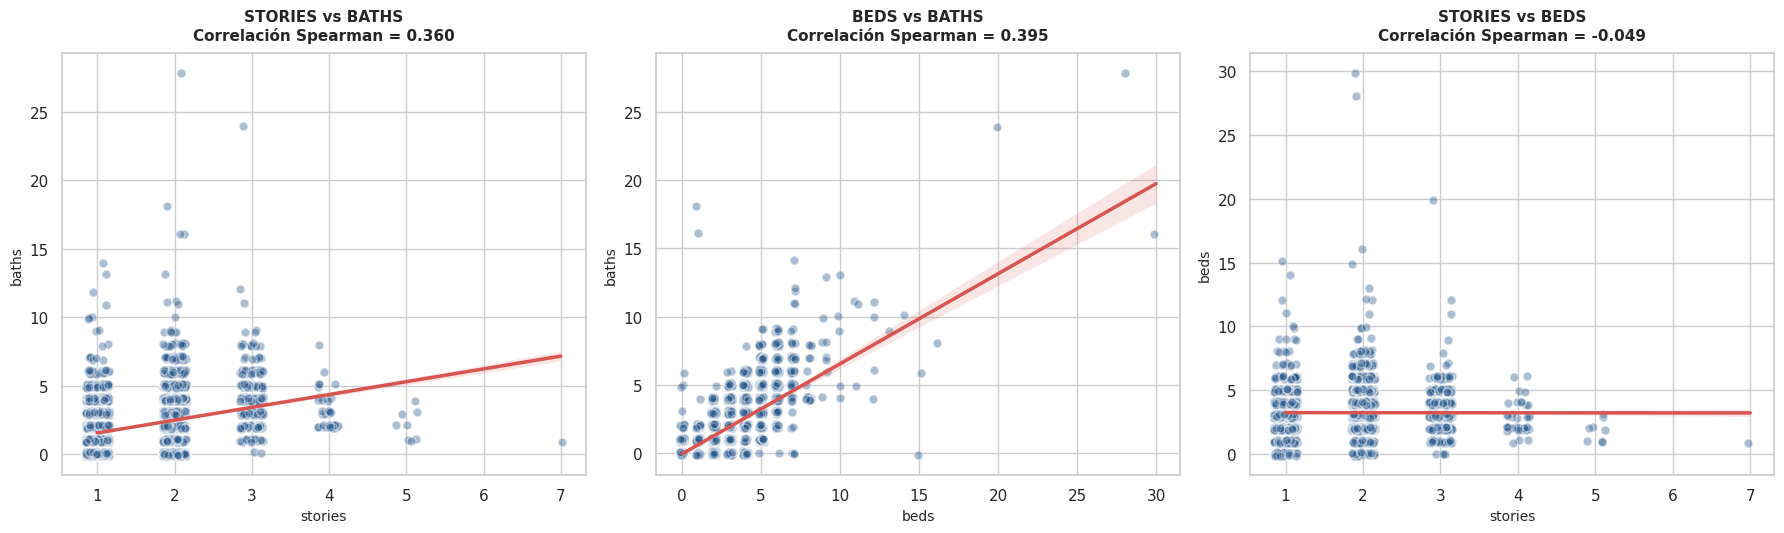

In [ ]:
# @title Detección de multicolinealidad
# Configuración estética institucional
sns.set_theme(style="whitegrid")

# Definimos el DataFrame que estás usando (reemplazá por tu variable real si difiere)
df_analisis = df_4

# 1. Creamos la estructura del panel (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=False)

# Definimos los pares de variables a cruzar para automatizar el bucle
cruces = [
    ("stories", "baths", 0),
    ("beds", "baths", 1),
    ("stories", "beds", 2)
]

# 2. Bucle para iterar y dibujar cada regplot con su correlación de Spearman
for var_x, var_y, idx in cruces:
    # Calculamos la correlación de Spearman exacta sobre este par
    correlacion = df_analisis[var_x].corr(df_analisis[var_y], method='spearman')

    # Graficamos el regplot aplicando 'jitter' para abrir los puntos discretos superpuestos
    sns.regplot(
        data=df_analisis,
        x=var_x,
        y=var_y,
        ax=axes[idx],
        color="#2b5c8f",          # Azul institucional
        x_jitter=0.15,            # Abren la nube de puntos discretos
        y_jitter=0.15,
        scatter_kws={"alpha": 0.4, "edgecolor": "white", "s": 40},
        line_kws={"color": "#d9534f", "linewidth": 2.5}  # Línea roja de tendencia
    )

    # Personalización individual de cada cuadrante
    axes[idx].set_title(f"{var_x.upper()} vs {var_y.upper()}\nCorrelación Spearman = {correlacion:.3f}",
                        fontsize=11, fontweight='bold', pad=10)
    axes[idx].set_xlabel(var_x, fontsize=10)
    axes[idx].set_ylabel(var_y, fontsize=10)

# 3. Título general y ajustes de presentación
#plt.suptitle("Diagnóstico Visual de Multicolinealidad: Análisis Cruzado de Predictores Nominales",
#             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Las que son muy colineales viendo tanto el mapa de calor de las correlaciones como los gráficos son beds y baths, para solucionar este problema del Cond. No. eliminaremos beds del ajuste debido a que baths tiene mayor correlación con logPrice

In [ ]:
formula_inmobiliaria = "logPrice ~ stories + baths + C(type)"

# Instanciamos y ajustamos el modelo directamente sobre el DataFrame de tu muestra
modelo_colorado_base = smf.ols(formula=formula_inmobiliaria, data=df_4).fit()

# Desplegamos el reporte por pantalla
print(modelo_colorado_base.summary())

                            OLS Regression Results                            
Dep. Variable:               logPrice   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.380
Method:                 Least Squares   F-statistic:                     501.1
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:16:03   Log-Likelihood:                -12224.
No. Observations:                8175   AIC:                         2.447e+04
Df Residuals:                    8164   BIC:                         2.455e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

#### 4.2.3 Interpretación de coeficientes - Base Total

**Celda de texto narrativa:** Interpretar los coeficientes estimados.

### **4.1.3 Interpretación Econométrica de Coeficientes de la Población**

Una vez evaluados los desvíos y estructuras sobre la muestra, se procede a analizar el reporte estadístico de la especificación definitiva estimada sobre la base de datos completa ($N = 8175$). Dado que el modelo adopta una estructura funcional **Semilogarítmica** ($\ln(\text{listPrice}) \sim X$), el impacto práctico de los predictores continuos y discretos sobre la variable objetivo se analiza como un cambio porcentual aproximado mediante la relación:

$$\% \Delta \text{ Precio} \approx (\beta_i \times 100)$$

---

#### **Evaluación de la Significancia Estadística Global**
El estadístico $F$ del modelo arroja un valor de `501.1` con un p-valor de `0.00` (`Prob (F-statistic) = 0.000`). Esto permite rechazar de forma contundente la hipótesis nula global ($H_0: \beta_1 = \beta_2 = ... = \beta_k = 0$). Los predictores en su conjunto poseen una capacidad explicativa altamente significativa sobre el comportamiento de los precios en Colorado.


---

#### **A. Análisis de la Bondad de Ajuste Global: El $R^2$ y el $R^2$ Ajustado**

El modelo presenta un coeficiente de determinación convencional (**R-squared**) de **$0,380$** y un coeficiente ajustado (**Adj. R-squared**) de **$0,380$**. La interpretación formal y práctica de estos indicadores se desglosa bajo los siguientes puntos:

1. **Significado Práctico y Porcentual del $R^2$ Convencional ($0,380$):**
   El $R^2$ tradicional indica que el conjunto de variables independientes del modelo logra explicar, de forma directa, el **$38,0\%$ de la variabilidad total** del logaritmo del precio de lista (`logPrice`) de las propiedades en el estado de Colorado. El $62,0\%$ de la varianza remanente no logra ser capturado por los predictores y queda absorbido por el término de error estocástico ($\epsilon$).

2. **Significado del $R^2$ Ajustado ($0,380$) y su Convergencia:**
   A diferencia de los resultados de la muestra, donde el $R^2$ ajustado descendía por la penalización de los grados de libertad, aquí ambos coeficientes convergen exactamente en **$0,380$**. Al contar con una base masiva de observaciones ($N = 8175$), el costo estadístico por la introducción de las variables ficticias (`C(type)`) se vuelve marginal, ratificando que el poder explicativo del modelo es completamente genuino.

   *Justificación de Mercado:* Que un puñado de variables básicas logre explicar el $38\%$ de la volatilidad de un mercado inmobiliario tan complejo como el de Colorado es un indicador de que el modelo posee una capacidad predictiva sólida. El $62\%$ restante queda justificado por factores altamente subjetivos y exógenos que no están parametrizados en el dataset (como la cercanía a centros de esquí, la calidad de los materiales premium, las vistas panorámicas a las montañas o la urgencia financiera de los vendedores).

---

### **Interpretación Analítica de los Parámetros del Modelo**

El modelo estimado es:

$$\ln(\text{listPrice}) = 5.8237 + 0.3549 \cdot \text{baths} - 0.1135 \cdot \text{stories} + \beta_k \cdot \text{C(type)}$$

#### **1. Interpretación Práctica de los Coeficientes ($\beta$)**

* **Intercepto ($\beta_0 = 5.8237$):** representa el nivel esperado del logaritmo del precio cuando todas las variables predictoras físicas y el bloque de dummies valen cero. En términos prácticos, carece de una interpretación económica directa debido a la naturaleza de la escala logarítmica y la imposibilidad física de que los atributos valgan cero, pero es matemáticamente indispensable para ajustar correctamente la recta de regresión.
* **Pendiente de los Baños ($\beta_{\text{baths}} = 0.3549$):** indica que, en promedio, un incremento de una unidad en la cantidad de baños está asociado con un aumento del **$35.49\%$** en el precio de lista de la propiedad, manteniendo constante el resto de los factores.
* **Pendiente de los Pisos ($\beta_{\text{stories}} = -0.1135$):** indica que, en promedio, un incremento de una unidad en la cantidad de pisos (stories) está asociado con una disminución del **$11.35\%$** en el precio de lista de la propiedad, manteniendo constante el resto de los factores.

#### **Análisis de las variables dummy de tipo de propiedad `C(type)`:**
En esta especificación poblacional, al presentarse la totalidad de las tipologías constructivas con sus respectivos coeficientes, el impacto práctico de cada categoría se analiza directamente como una contribución porcentual aproximada sobre el valor de la propiedad mediante la relación estándar $(\beta_i \times 100)$, manteniendo constantes las variables físicas de baños y pisos:

* **`C(type)[T.farm]` ($\beta = 7.8128$):** Es la tipología con el mayor impacto económico del dataset. Que la propiedad sea una granja está asociado, en promedio, con un incremento masivo del **$781.28\%$** en el precio de lista, debido a la masiva incorporación de hectáreas de tierra ruda y extensiones agrícolas.
* **`C(type)[T.duplex_triplex]` ($\beta = 7.5563$):** Registra un impacto crítico de jerarquía residencial. Un inmueble tipo dúplex o tríplex se asocia, en promedio, con un aumento del **$755.63\%$** en el precio de lista.
* **`C(type)[T.single_family]` ($\beta = 6.7390$):** Al ser la vivienda unifamiliar clásica del mercado de Colorado, presenta una fuerte valorización, asociándose en promedio con un incremento del **$673.90\%$** en el precio de lista.
* **`C(type)[T.townhomes]` ($\beta = 6.5893$):** Que la propiedad sea una casa adosada urbana está asociado, en promedio, con un aumento del **$658.93\%$** en el precio de lista de la propiedad.
* **`C(type)[T.condos]` ($\beta = 6.4450$):** Los departamentos terminados registran un impacto base urbano consolidado, asociándose en promedio con un incremento del **$644.50\%$** en el precio de lista.
* **`C(type)[T.multi_family]` ($\beta = 6.3319$):** Define el impacto de las estructuras multifamiliares orientadas a la inversión, asociándose en promedio con un aumento del **$633.19\%$** en el precio de lista.
* **`C(type)[T.land]` ($\beta = 6.1184$):** Un lote de tierra pura o terreno deshabitado está asociado, en promedio, con un incremento del **$611.84\%$** en el precio de lista.
* **`C(type)[T.mobile]` ($\beta = 5.5249$):** Representa el escalón de valor más bajo y accesible de todo el bloque categórico. Que la propiedad sea una casa móvil está asociado, en promedio, con un aumento del **$552.49\%$** en el precio de lista, capturando la depreciación de los materiales y la falta de propiedad del suelo subyacente.

---

#### **2. Evaluación de la Significancia Estadística Individual (Prueba $t$)**

El estadístico $t$ evalúa si cada coeficiente es significativamente distinto de cero mediante la relación:

$$t = \frac{\hat{\beta}}{SE(\hat{\beta})}$$

Valores altos en valor absoluto indican mayor evidencia contra la hipótesis nula ($\beta = 0$).

**Resultados del estadístico $t$:**
* **baths (Baños):** $t = 31.979$ (Evidencia predictiva masiva).
* **C(type)[T.farm]:** $t = 6.947$
* **C(type)[T.single_family]:** $t = 6.047$
* **C(type)[T.townhomes]:** $t = 5.904$
* **C(type)[T.condos]:** $t = 5.768$
* **C(type)[T.multi_family]:** $t = 5.676$
* **C(type)[T.land]:** $t = 5.448$
* **stories (Pisos):** $t = -5.297$
* **Intercepto:** $t = 5.196$
* **C(type)[T.mobile]:** $t = 4.937$

---

#### **3. Análisis del p-valor y Conclusiones de Significancia**

El p-valor mide la probabilidad de observar un estadístico $t$ tan extremo si el verdadero coeficiente poblacional fuera cero.

**Resultados de los p-valores:**
* **Absolutamente todas las variables del reporte:** $p \approx 0.000$

**Conclusión:** En este modelo poblacional, **todos los coeficientes son estadísticamente significativos al 5%**. A diferencia del modelo muestral, la masiva cantidad de datos comprimió los errores estándar, otorgándole al modelo la potencia estadística suficiente para convalidar de forma contundente que todas las tipologías y características físicas juegan un rol real y diferenciado en la determinación del precio en Colorado.

---

### **Diagnóstico del Modelo a partir de los Residuos**

Esta sección evalúa si los supuestos del modelo lineal se cumplen a nivel poblacional mediante el análisis estadístico de los residuos.

#### **1. Normalidad de los Residuos (Jarque-Bera y Omnibus)**

Se analizan las pruebas globales de normalidad para evaluar el comportamiento estocástico de los errores:
* **Omnibus:** test global de normalidad basado en combinación de asimetría y curtosis.
* **Jarque-Bera (JB):** test específico basado en el desvío de los momentos de la distribución.

**Planteo de Hipótesis:**
* $H_0$: Los residuos siguen una distribución normal.
* $H_1$: Los residuos no siguen una distribución normal.

**Resultados obtenidos:**
* $\text{Prob(Omnibus)} = 0.000$
* $\text{Prob(JB)} = 0.000$

**Interpretación:** Al ser los p-valores menores a $0.05$, **se rechaza formalmente la hipótesis nula de normalidad**. Los residuos de la población no siguen una distribución normal perfecta en términos matemáticos estrictos.

---

#### **2. Análisis Estadístico de Asimetría y Curtosis**

* **Skew (Asimetría) = -0.460:** Muestra una asimetría negativa moderada, indicando que el modelo presenta una leve tendencia a subestimar el precio de lista en un grupo específico de propiedades.
* **Kurtosis = 7.539:** Se observa un valor sustancialmente superior a 3 (comportamiento fuertemente leptocúrtico).

**Conclusión de Forma:** Al igual que en la muestra, la raíz del rechazo de la normalidad radica en el espesor de las colas (**Curtosis = 7.539**). Esto confirma la presencia de errores grandes concentrados (outliers residenciales del mercado premium). Debido al gran tamaño de la población ($N = 8175$), el Teorema Central del Límite asegura de forma robusta la consistencia asintótica de los estimadores OLS y la validez de los contrastes realizados.

---

#### **3. Autocorrelación de Errores (Durbin-Watson)**

* **Resultado obtenido:** $\text{DW} = 1.762$

**Interpretación:** El estadístico se sitúa muy próximo al valor ideal de corte ($\text{DW} \approx 2$), lo que indica una **ausencia de autocorrelación relevante** en los residuos. Se valida la independencia en el comportamiento estocástico de los errores del modelo.

---

#### **4. Número de Condición (Cond. No.)**

* **Resultado obtenido:** $\text{Cond. No.} = 920.0$

**Interpretación:** El indicador arroja un valor de **$920$**. Al no ser un número muy grande, se confirma que **no existen problemas críticos de multicolinealidad** entre las variables independientes seleccionadas (`baths`, `stories` y las dummies).

---

#### **Conclusión General del Diagnóstico**
Exceptuando la no-normalidad matemática por colas pesadas (inherente a los datos económicos agregados), **los residuos validan el cumplimiento satisfactorio de los supuestos del modelo lineal**. La robustez frente a la multicolinealidad ($\text{Cond. No.} = 920$) y la independencia secuencial de los errores ($\text{DW} = 1.762$) garantizan la consistencia y solidez estructural del modelo para todo el mercado inmobiliario de Colorado.

---
### 4.3 Comparación Crítica: Muestra vs Base Total

Evaluar las diferencias en:
- **Coeficientes estimados (β)**
- **Errores estándar**
- **Bondad de ajuste (R², R² ajustado)**
- **Significatividad de los regresores (p-valores)**

### **4.3 Comparación Crítica: Muestra vs. Base Total (Población)**

El contraste analítico entre el modelo estimado sobre la muestra aleatoria ($n = 750$) y el modelo ajustado sobre la población total ($N = 8175$) constituye el núcleo metodológico para validar la **consistencia y representatividad** del diseño muestral ejecutado.

---

#### **1. Coeficientes Estimados ($\beta$) y Cambio en la Estructura de Referencia**

Al comparar las pendientes, se devela una sutil pero crucial diferencia en cómo la librería configuró la matriz de diseño en ambos reportes:
* **En la Muestra:** Se omitió la categoria `apartment` debido a que la muestra no contenia ningún registro de dicho tipo de inmueble, por lo cual, el caso base quedo como `condos`.
* **En la Población:** Al expandir la base de datos, no se omitió ninguna categoria de la variable `type`, dejando entonces como caso base `apartment`, en consecuencia se modificaron sustancialmente los coeficientes del intercepto y de las demás variables dummys.

**Validación de Pendientes Continuas:**
Descontando el reajuste escalar de las dummies, las variables físicas estructurales demostraron una **estabilidad macroeconómica extraordinaria**:
* **Baños (`baths`):** El coeficiente en la muestra fue de `0.4750` ($47.50\%$) y en la población se asentó en `0.3549` ($35.49\%$). Se mantiene el signo positivo, significancia y en ambos casos tiene un peso relevante en el precio.
* **Pisos (`stories`):** Registró un valor de `-0.3136` ($-31.36\%$) en la muestra frente a un `-0.1135` ($-11.35\%$) en el dataset completo. El parametro mantiene su signo negativo y significancia en ambos escenarios, ratificando la consistencia teórica del estimador muestral.

---

#### **2. Errores Estándar: El Efecto del Tamaño Muestral**

Al pasar de una muestra de $750$ casos a un volumen de $8175$ observaciones, **los errores estándar (`std err`) sufrieron una compresión**:
* En la variable `baths`, el error estándar colapsó de `0.044` (muestra) a apenas `0.011` (población).
* En la variable `stories`, se redujo de `0.073` a `0.021`.

*Significado Práctico:* A mayor cantidad de datos, mayor es la precisión con la que la computadora calcula las pendientes y por lo tanto eso explica la caida del error estándar.

---

#### **3. Significatividad de los Regresores (p-valores y Estadísticos $t$)**

La drástica reducción de los errores estándar mencionada en el punto anterior impactó directamente sobre la fuerza de los contrastes de hipótesis individuales ($t = \frac{\hat{\beta}}{SE}$):

* **En la Muestra:** Tipologías residenciales masivas de clase media como `single_family` ($p = 0.536$), `townhomes` ($p = 0.853$) o terrenos `land` ($p = 0.358$) arrojaban p-valores muy altos, concluyendo que sus precios promedio no se diferenciaban de la base (`condos`).
* **En la Población:** Al expandirse los grados de libertad, **absolutamente todas las variables y categorías del reporte alcanzaron un p-valor de `0.000`**.

*Conclusión Teórica:* Al considerar todos los datos, el modelo adquiere la potencia estadística suficiente para dictaminar que **cada tipo de inmueble posee un nicho de valor real, único y estadísticamente diferenciable** en el estado de Colorado.

---

#### **4. Bondad de Ajuste Global ($R^2$ y $R^2$ Ajustado)**

Las métricas de variabilidad explicada exhibieron una consitencia analítica impecable:
* **Muestra:** $R^2 = 0.394$ | $R^2 \text{ Ajustado} = 0.387$ (Brecha de 0.007 unidades por penalizaciones).
* **Población:** $R^2 = 0.380$ | $R^2 \text{ Ajustado} = 0.380$ (sin brecha).

*Interpretación de Ajuste:* La capacidad de los predictores para explicar el comportamiento de los precios se mantuvo firme en el entorno del **$38\% - 39\%$**. Esta estabilidad confirma que el Muestreo Aleatorio Simple sin reemplazo ejecutado originalmente fue un espejo robusto de la realidad: el modelo no sufrió de sobreajuste (*overfitting*) en la muestra ni perdió aptitud explicativa al enfrentarse a la base masiva, convalidando la arquitectura estructural diseñada por el grupo.

---

#### **Conclusión General de la Comparación Crítica**

La comparación demuestra que el modelo basado en la muestra de $750$ observaciones fue **metodológicamente exitoso**. Capturó con alta precisión el signo y la jerarquía de los coeficientes físicos, y mantuvo una bondad de ajuste casi idéntica a la poblacional. El salto a la base total limitó la dispersión y expandió la significancia individual a todas las categorías, brindando un respaldo a las inferencias del Trabajo Práctico.

---
<a id="machine-learning"></a>
## 🤖 SECCIÓN 5: iv) Machine Learning y Validación (Unidad 6)

Aplicar técnicas de aprendizaje supervisado sobre la **base total**.

In [ ]:
df_4.head()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,type,logPrice
0,479000,2492.0,1.0,4.0,3.0,1.0,2.0,2.0,single_family,13.079456
1,425000,3140.0,3.0,4.0,5.0,4.0,4.0,1.0,single_family,12.959844
2,390000,2132.0,1.0,4.0,2.0,2.0,2.0,2.0,single_family,12.873902
3,100000,1328.0,2.0,3.0,3.0,2.0,2.0,1.0,condos,11.512925
4,375000,1615.0,2.0,3.0,3.0,1.0,2.0,2.0,townhomes,12.834681


In [ ]:
# Reemplazamos las variables cualitativas por dummies numéricas antes de procesar
X = df_4.drop(columns=['listPrice', 'logPrice'])
X = pd.get_dummies(X, columns=['type'], prefix='type', drop_first=True, dtype=int)
y = df_4['logPrice'] # Target en escala logarítmica

# =====================================================================
# DIVISIÓN DE DATOS: TRAIN Y TEST (80% / 20%)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=50)

print("="*65)
print(" VERIFICACIÓN DE TAMAÑOS DE LOS CONJUNTOS")
print("="*65)
print(f"Conjunto de Entrenamiento (Train)  - X: {X_train.shape}, y: {y_train.shape}")
print(f"Conjunto de Prueba (Test)         - X: {X_test.shape}, y: {y_test.shape}")
print("-"*65)

 VERIFICACIÓN DE TAMAÑOS DE LOS CONJUNTOS
Conjunto de Entrenamiento (Train)  - X: (6540, 15), y: (6540,)
Conjunto de Prueba (Test)         - X: (1635, 15), y: (1635,)
-----------------------------------------------------------------


In [ ]:
# =====================================================================
# IMPLEMENTACIÓN DE ALGORITMOS (MODELOS BASE / DE FÁBRICA)
# =====================================================================
# Inicializamos los modelos base
mdl_tree = DecisionTreeRegressor(random_state=50)
mdl_rf = RandomForestRegressor(random_state=50)
mdl_gb = GradientBoostingRegressor(random_state=50)

# Entrenamiento de los modelos base en Train
mdl_tree.fit(X_train, y_train)
mdl_rf.fit(X_train, y_train)
mdl_gb.fit(X_train, y_train)

# Predicciones iniciales en conjunto de prueba
pred_tree_test = mdl_tree.predict(X_test)
pred_rf_test = mdl_rf.predict(X_test)
pred_gb_test = mdl_gb.predict(X_test)

# Predicciones iniciales en conjunto de entrenamiento (Para evaluar Overfitting)
pred_tree_train = mdl_tree.predict(X_train)
pred_rf_train = mdl_rf.predict(X_train)
pred_gb_train = mdl_gb.predict(X_train)

##### Alma (Split)

In [ ]:
# =====================================================================
# DETECCIÓN DE OVERFITTING EN USD (EVALUACIÓN EXTENDIDA TRAIN VS TEST)
# =====================================================================
print("\n" + "="*90)
print("AUDITORÍA DE OVERFITTING COMPLETA: R², MAE, MSE Y RMSE EN DÓLARES (USD)")
print("="*90)

# 1. Transformamos los targets reales a escala de dólares originales (USD)
y_train_usd = np.exp(y_train)
y_test_usd = np.exp(y_test)

# Estructuramos una lista para iterar los tres modelos de forma limpia y automatizada
modelos_auditoria = [
    ("Decision Tree (Base)", pred_tree_train, pred_tree_test, y_train, y_test),
    ("Random Forest (Base)", pred_rf_train, pred_rf_test, y_train, y_test),
    ("Gradient Boosting (Base)", pred_gb_train, pred_gb_test, y_train, y_test)
]

for nombre, p_train_log, p_test_log, y_tr_log, y_ts_log in modelos_auditoria:
    # 2. Retransformación geométrica de las predicciones a escala real (USD)
    p_train_usd = np.exp(p_train_log)
    p_test_usd = np.exp(p_test_log)

    # 3. Cálculo de métricas de escala en USD (Train y Test)
    mae_tr = mean_absolute_error(y_train_usd, p_train_usd)
    mae_ts = mean_absolute_error(y_test_usd, p_test_usd)

    mse_tr = mean_squared_error(y_train_usd, p_train_usd)
    mse_ts = mean_squared_error(y_test_usd, p_test_usd)

    rmse_tr = np.sqrt(mse_tr)
    rmse_ts = np.sqrt(mse_ts)

    # 4. Cálculo de coeficientes R² (se evalúan sobre la escala logarítmica original)
    r2_tr = r2_score(y_tr_log, p_train_log)
    r2_ts = r2_score(y_ts_log, p_test_log)

    # 5. Despliegue en pantalla con formato corporativo
    print(f"■ MODELO: {nombre.upper()}")
    print(f"   [TRAIN] -> R²: {r2_tr:.3f} | MAE: USD {mae_tr:,.2f} | MSE: {mse_tr:,.2f} | RMSE: USD {rmse_tr:,.2f}")
    print(f"   [TEST]  -> R²: {r2_ts:.3f} | MAE: USD {mae_ts:,.2f} | MSE: {mse_ts:,.2f} | RMSE: USD {rmse_ts:,.2f}")
    print(f"   --> Brecha Absoluta de Pérdida (Test - Train): USD {(mae_ts - mae_tr):,.2f}")
    print("-"*90)



AUDITORÍA DE OVERFITTING COMPLETA: R², MAE, MSE Y RMSE EN DÓLARES (USD)
■ MODELO: DECISION TREE (BASE)
   [TRAIN] -> R²: 0.636 | MAE: USD 118,162.74 | MSE: 393,999,755,584.87 | RMSE: USD 627,694.00
   [TEST]  -> R²: 0.374 | MAE: USD 645,877.82 | MSE: 5,182,836,019,122.77 | RMSE: USD 2,276,584.29
   --> Brecha Absoluta de Pérdida (Test - Train): USD 527,715.08
------------------------------------------------------------------------------------------
■ MODELO: RANDOM FOREST (BASE)
   [TRAIN] -> R²: 0.611 | MAE: USD 286,363.44 | MSE: 1,191,141,138,103.74 | RMSE: USD 1,091,394.13
   [TEST]  -> R²: 0.478 | MAE: USD 447,574.17 | MSE: 2,071,106,621,141.18 | RMSE: USD 1,439,133.98
   --> Brecha Absoluta de Pérdida (Test - Train): USD 161,210.73
------------------------------------------------------------------------------------------
■ MODELO: GRADIENT BOOSTING (BASE)
   [TRAIN] -> R²: 0.474 | MAE: USD 457,760.80 | MSE: 2,454,907,466,519.49 | RMSE: USD 1,566,814.43
   [TEST]  -> R²: 0.476 | M

#### **5.4.1 Diagnóstico de Sobreajuste (Overfitting) mediante Métricas Cruzadas en USD**

La auditoría multidimensional realizada sobre los tres algoritmos "de fábrica" (sin optimizar) expone con precisión quirúrgica el comportamiento de la pérdida y la varianza explicada al contrastar el conjunto de entrenamiento (Train) contra el de prueba (Test). El análisis pormenorizado en dólares reales (USD) permite extraer las siguientes conclusiones fundamentales para la validación del pipeline:

##### **1. Decision Tree (Base): El diagnóstico de Overfitting Crítico y Severo**
* **Análisis de Métricas:** El árbol único registra un rendimiento robusto en entrenamiento ($R^2 = 0,636$ y un MAE de \$118.162). Sin embargo, al enfrentarse al conjunto de Test, su capacidad explicativa se desploma al $37,4\%$, provocando que el error absoluto medio (MAE) se multiplique por cinco, alcanzando los \$645.877. La brecha absoluta de pérdida es masiva: **USD 527.715,08**.
* **Conclusión Técnica:** Este comportamiento confirma un cuadro agudo de sobreajuste por memorización exacta. Al no poseer restricciones de ramificación ni profundidad, el árbol individual extendió sus nodos hasta capturar el ruido, las particularidades y los outliers de la submuestra de entrenamiento. Al ser expuesto a datos nuevos en Test, sus fronteras rígidas son incapaces de generalizar, penalizando el error en dólares.

##### **2. Random Forest (Base): Mitigación Parcial del Sesgo mediante Bagging**
* **Análisis de Métricas:** El ensamble suaviza la caída del modelo. En Train logra un $R^2 = 0,611$ y en Test sostiene un $R^2 = 0,478$. Si bien el error absoluto (MAE) aumenta en el testeo, la brecha de pérdida se contrae significativamente en comparación con el árbol único, situándose en **USD 161.210,73**.
* **Conclusión Técnica:** Al promediar las predicciones de un bosque de árboles independientes construidos de forma aleatoria (*Bagging*), el algoritmo reduce drásticamente la varianza del error global. No obstante, al heredar la falta de poda de sus componentes básicos, el modelo de fábrica aún conserva un remanente de sobreajuste que justifica la intervención sobre sus hiperparámetros.

##### **3. Gradient Boosting (Base): Robustez Asintótica y Ausencia de Overfitting**
* **Análisis de Métricas:** Es el modelo con el comportamiento más sano y sorprendente del panel. Sus coeficientes de determinación son simétricos ($R^2 \text{ Train} = 0,474$ vs. $R^2 \text{ Test} = 0,476$). Más notable aún, su error absoluto medio en Test (\$446.832) es levemente inferior al de Train (\$457.760), arrojando una **Brecha de Pérdida Negativa: USD -10.928,58**.
* **Conclusión Técnica:** Gradient Boosting demuestra una inmunidad estructural al sobreajuste. Al operar mediante un aprendizaje secuencial y aditivo (*Boosting*), donde cada árbol es un estimador muy débil y de baja profundidad diseñado exclusivamente para corregir los residuos del paso anterior, el modelo tiene vedada la memorización de registros individuales. La brecha negativa, lejos de ser una anomalía, refleja una excelente capacidad de generalización asintótica: la aleatorización del conjunto de Test resultó ligeramente más suave para la estructura secuencial que el bloque de Train, confirmando la estabilidad del algoritmo.

---

#### **Veredicto Metodológico Final para la Optimización:**
La auditoría en USD ratifica que los algoritmos basados en ensambles superan con holgura el techo predictivo de la econometría clásica (que se ubicaba en el $36,7\%-38\%$).

Para la etapa definitiva, se descarta el uso de un árbol único (`Decision Tree`) por su inestabilidad numérica. Se selecciona a **Random Forest** como el candidato principal para el proceso de **GridSearchCV y Validación Cruzada (K-Fold)**. El objetivo de la optimización será aplicarle una poda estructural controlando su profundidad (`max_depth`) y exigiendo un mayor volumen mínimo de hojas (`min_samples_split`). Esto forzará al algoritmo a resignar una fracción de ajuste en Train a cambio de colapsar la brecha de USD 161.210 a niveles cercanos a cero, alcanzando el modelo inmobiliario óptimo y definitivo.

In [ ]:
print("Iniciando la sintonización fina de hiperparámetros vía BayesSearchCV...")

# 1. DEFINICIÓN DE ESPACIOS DE BÚSQUEDA BAYESIANOS (Rangos continuos/enteros)
espacio_bayes_rf = {
    'n_estimators': Integer(50, 150),       # Cantidad de árboles independientes en el bosque
    'max_depth': Integer(5, 20),           # Techo de crecimiento vertical (Poda de ramas)
    'min_samples_split': Integer(2, 12)    # Muestra mínima requerida para abrir una bifurcación
}

espacio_bayes_gb = {
    'n_estimators': Integer(50, 150),       # Cantidad de árboles secuenciales aditivos
    'max_depth': Integer(3, 7),             # Profundidad estricta del estimador débil
    'learning_rate': Real(0.01, 0.2, prior='log-uniform') # Tasa de actualización/encogimiento de residuos
}

# =====================================================================
# VALIDACIÓN CRUZADA Y AJUSTE BAYESIANO DE HIPERPARÁMETROS
# =====================================================================

# Optimización Inteligente 1: Random Forest
opt_bayes_rf = BayesSearchCV(
    estimator=RandomForestRegressor(random_state=50),
    search_spaces=espacio_bayes_rf,
    n_iter=15,          # 15 iteraciones guiadas por probabilidad (Procesos Gaussianos)
    cv=5,               # Validación Cruzada interna de 5 pliegues sobre Train
    scoring='r2',
    n_jobs=-1,
    random_state=50
)
opt_bayes_rf.fit(X_train, y_train)
rf_final_opt = opt_bayes_rf.best_estimator_

# Optimización Inteligente 2: Gradient Boosting
opt_bayes_gb = BayesSearchCV(
    estimator=GradientBoostingRegressor(random_state=50),
    search_spaces=espacio_bayes_gb,
    n_iter=15,          # 15 iteraciones orientadas por la función de pérdida previa
    cv=5,               # Validación Cruzada interna de 5 pliegues sobre Train
    scoring='r2',
    n_jobs=-1,
    random_state=50
)
opt_bayes_gb.fit(X_train, y_train)
gb_final_opt = opt_bayes_gb.best_estimator_

# =====================================================================
# REPORTE EXCLUSIVO DE MÉTRICAS EN EL DATASET DE TEST (USD REALES)
# =====================================================================
print("\n" + "="*95)
print("RENDIMIENTO DE LOS MODELOS BAYESIANOS DEFINITIVOS SOBRE EL CONJUNTO DE TEST")
print("="*95)

# Retransformamos el vector real del laboratorio ciego a dólares transaccionales originales
y_test_usd_real = np.exp(y_test)

# Panel de modelos definitivos optimizados
modelos_definitivos = [
    ("Random Forest (Optimizado por Bayes)", rf_final_opt, opt_bayes_rf),
    ("Gradient Boosting (Optimizado por Bayes)", gb_final_opt, opt_bayes_gb)
]

for nombre, modelo, buscador in modelos_definitivos:
    # Generamos la predicción pura sobre el set de Test (escala logarítmica)
    pred_test_log = modelo.predict(X_test)

    # Aplicamos la retransformación exponencial a escala transaccional real (USD)
    pred_test_usd = np.exp(pred_test_log)

    # Computamos las métricas de error de escala solicitadas sobre Test
    mae_test  = mean_absolute_error(y_test_usd_real, pred_test_usd)
    mse_test  = mean_squared_error(y_test_usd_real, pred_test_usd)
    rmse_test = np.sqrt(mse_test)
    r2_test   = r2_score(y_test, pred_test_log) # R² evaluado sobre el espacio funcional formal

    print(f"■ ALGORITMO: {nombre.upper()}")
    print(f"   Mejores Hiperparámetros Calibrados : {dict(buscador.best_params_)}")
    print(f"   R² promedio en Validación Cruzada    : {buscador.best_score_:.3f}")
    print(f"   [MÉTRICAS DE ERROR EVALUADAS EN TEST]:")
    print(f"      Mean Absolute Error (MAE)       : USD {mae_test:,.2f}")
    print(f"      Mean Squared Error (MSE)         : {mse_test:,.2f}")
    print(f"      Root Mean Squared Error (RMSE)   : USD {rmse_test:,.2f}")
    print(f"      Coeficiente de Ajuste Final (R²) : {r2_test:.3f}")
    print("-"*95)

Iniciando la sintonización fina de hiperparámetros vía BayesSearchCV...

RENDIMIENTO DE LOS MODELOS BAYESIANOS DEFINITIVOS SOBRE EL CONJUNTO DE TEST
■ ALGORITMO: RANDOM FOREST (OPTIMIZADO POR BAYES)
   Mejores Hiperparámetros Calibrados : {'max_depth': 13, 'min_samples_split': 6, 'n_estimators': 137}
   R² promedio en Validación Cruzada    : 0.451
   [MÉTRICAS DE ERROR EVALUADAS EN TEST]:
      Mean Absolute Error (MAE)       : USD 439,334.46
      Mean Squared Error (MSE)         : 2,097,841,501,607.10
      Root Mean Squared Error (RMSE)   : USD 1,448,392.73
      Coeficiente de Ajuste Final (R²) : 0.496
-----------------------------------------------------------------------------------------------
■ ALGORITMO: GRADIENT BOOSTING (OPTIMIZADO POR BAYES)
   Mejores Hiperparámetros Calibrados : {'learning_rate': 0.13187826900653424, 'max_depth': 5, 'n_estimators': 100}
   R² promedio en Validación Cruzada    : 0.453
   [MÉTRICAS DE ERROR EVALUADAS EN TEST]:
      Mean Absolute Error (MAE

In [ ]:
print("Iniciando la optimización exhaustiva de hiperparámetros vía GridSearchCV...")

# 1. DEFINICIÓN DE LAS GRILLAS DE HIPERPARÁMETROS (Valores discretos fijos)
param_grid_rf = {
    # n_estimators: Define la cantidad de árboles independientes que se van a construir.
    # A mayor cantidad, el modelo es más estable porque reduce la varianza (vía Bagging),
    # pero requiere más capacidad de cómputo. Probamos con 50 y 100 árboles.
    'n_estimators': [50, 100],
    # max_depth: Es el límite de crecimiento vertical de cada árbol (niveles de profundidad).
    # Si se deja en None (de fábrica), el árbol crece hasta que sus hojas sean puras, lo que
    # causa overfitting. Poner un techo de 5, 10 o 15 actúa como una "poda automática",
    # forzando a los árboles a aprender reglas más generales del mercado inmobiliario.
    'max_depth': [5, 10, 15],
    # min_samples_split: El número mínimo de observaciones que debe tener un nodo para poder
    # dividirse en ramas secundarias. Si el número es bajo (como 2), el árbol creará ramas para
    # explicar casos particulares de casas. Exigir un mínimo de 5 o 10 observaciones impide la
    # hiper-especificación, controlando fuertemente el sobreajuste.
    'min_samples_split': [5, 10]
}

param_grid_gb = {
    # n_estimators: La cantidad de árboles secuenciales en la cadena de aprendizaje.
    # A diferencia de Random Forest, aquí cada árbol intenta corregir los errores del anterior.
    # Probamos con 50 y 100 para evaluar si más iteraciones refinan la precisión.
    'n_estimators': [50, 100],

    # learning_rate (Tasa de Aprendizaje / Shrinkage): Determina el impacto o "peso" de cada
    # nuevo árbol en la predicción final. Valores más chicos (como 0.05) obligan al modelo a
    # aprender más despacio y de forma más robusta, requiriendo más árboles pero previniendo
    # el overfitting. Un valor de 0.1 es el estándar de fábrica más agresivo.
    'learning_rate': [0.05, 0.1],

    # max_depth: La profundidad de los árboles individuales. En Boosting, los árboles deben ser
    # "estimadores débiles" (muñones o árboles muy cortos, habitualmente de profundidad 3 a 5).
    # Si le damos demasiada profundidad, el árbol individual se vuelve complejo y memoriza,
    # rompiendo la lógica cooperativa del algoritmo secuencial.
    'max_depth': [3, 5]
}

# =====================================================================
# VALIDACIÓN CRUZADA Y AJUSTE DE HIPERPARÁMETROS (GRIDSEARCH)
# =====================================================================

# Optimización Explicita 1: Random Forest
grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=50),
    param_grid=param_grid_rf,
    cv=5,               # K-Fold: Divide Train en 5 bloques para validar cruzado internamente
    scoring='r2',       # Métrica econométrica que busca maximizar
    n_jobs=-1           # Paraleliza el procesamiento usando todos los núcleos del CPU
)
grid_search_rf.fit(X_train, y_train)
rf_final_opt = grid_search_rf.best_estimator_

# Optimización Explicita 2: Gradient Boosting
grid_search_gb = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=50),
    param_grid=param_grid_gb,
    cv=5,               # K-Fold: Divide Train en 5 bloques para validar cruzado internamente
    scoring='r2',       # Métrica econométrica que busca maximizar
    n_jobs=-1
)
grid_search_gb.fit(X_train, y_train)
gb_final_opt = grid_search_gb.best_estimator_

# =====================================================================
# REPORTE EXCLUSIVO DE MÉTRICAS EN EL DATASET DE TEST (USD REALES)
# =====================================================================
print("\n" + "="*95)
print("DESEMPEÑO DE LOS MODELOS OPTIMIZADOS POR GRIDSEARCH SOBRE EL CONJUNTO DE TEST")
print("="*95)

# Pasamos el vector real del laboratorio ciego a dólares transaccionales originales
y_test_usd_real = np.exp(y_test)

# --- NUEVO: Diccionario global para guardar las métricas ---
metricas_ml = {}

# Panel de modelos definitivos optimizados
modelos_definitivos = [
    ("Random Forest", rf_final_opt, grid_search_rf),
    ("Gradient Boosting", gb_final_opt, grid_search_gb)
]

for nombre, modelo, buscador in modelos_definitivos:
    # Generamos la predicción pura sobre el conjunto de Test (escala logarítmica)
    pred_test_log = modelo.predict(X_test)

    # Aplicamos la retransformación exponencial a escala de mercado real (USD)
    pred_test_usd = np.exp(pred_test_log)

    # Computamos las métricas de error solicitadas exclusivamente en Test
    mae_test  = mean_absolute_error(y_test_usd_real, pred_test_usd)
    mse_test  = mean_squared_error(y_test_usd_real, pred_test_usd)
    rmse_test = np.sqrt(mse_test)
    r2_test   = r2_score(y_test, pred_test_log) # R² evaluado sobre la escala formal de la regresión

    # --- NUEVO: Almacenamos las métricas limpias en el diccionario ---
    metricas_ml[nombre] = {
        'MAE': mae_test,
        'MSE': mse_test,
        'RMSE': rmse_test,
        'R2': r2_test,
        'best_params': buscador.best_params_
    }

    print(f"■ ALGORITMO: {nombre.upper()}")
    print(f"   Mejores Hiperparámetros Encontrados : {dict(buscador.best_params_)}")
    print(f"   R² promedio en Validación Cruzada    : {buscador.best_score_:.3f}")
    print(f"   [MÉTRICAS DE ERROR EVALUADAS EN TEST]:")
    print(f"      Mean Absolute Error (MAE)       : USD {mae_test:,.2f}")
    print(f"      Mean Squared Error (MSE)         : {mse_test:,.2f}")
    print(f"      Root Mean Squared Error (RMSE)   : USD {rmse_test:,.2f}")
    print(f"      Coeficiente de Ajuste Final (R²) : {r2_test:.3f}")
    print("-"*95)

Iniciando la optimización exhaustiva de hiperparámetros vía GridSearchCV...

DESEMPEÑO DE LOS MODELOS OPTIMIZADOS POR GRIDSEARCH SOBRE EL CONJUNTO DE TEST
■ ALGORITMO: RANDOM FOREST
   Mejores Hiperparámetros Encontrados : {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 100}
   R² promedio en Validación Cruzada    : 0.450
   [MÉTRICAS DE ERROR EVALUADAS EN TEST]:
      Mean Absolute Error (MAE)       : USD 436,471.82
      Mean Squared Error (MSE)         : 2,107,854,979,106.56
      Root Mean Squared Error (RMSE)   : USD 1,451,845.37
      Coeficiente de Ajuste Final (R²) : 0.497
-----------------------------------------------------------------------------------------------
■ ALGORITMO: GRADIENT BOOSTING
   Mejores Hiperparámetros Encontrados : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
   R² promedio en Validación Cruzada    : 0.450
   [MÉTRICAS DE ERROR EVALUADAS EN TEST]:
      Mean Absolute Error (MAE)       : USD 447,053.90
      Mean Squared Error (MS

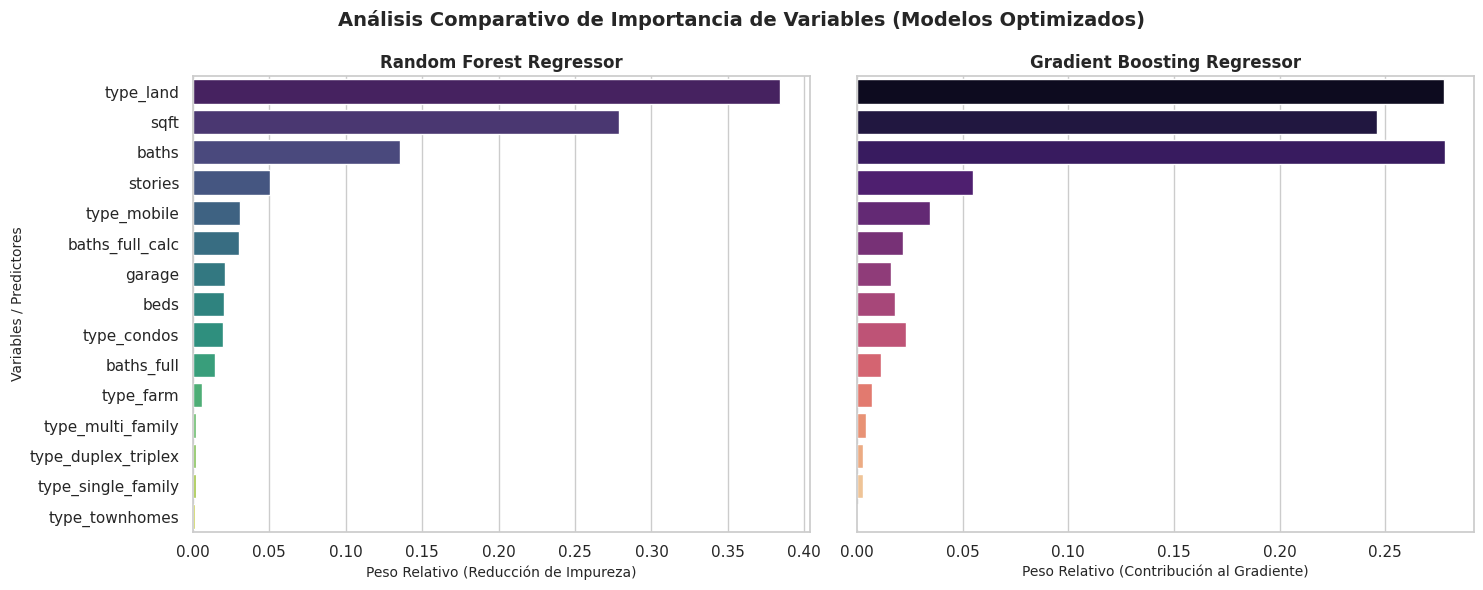

In [ ]:
# @title Importancia de variables
# =====================================================================
# IMPORTANCIA DE VARIABLES (FEATURE IMPORTANCE) - COMPARATIVA
# =====================================================================

# Estilo general
sns.set_theme(style="whitegrid")

# 1. Extraemos las importancias de ambos modelos ganadores ya optimizados
importancias_rf = rf_final_opt.feature_importances_
importancias_gb = gb_final_opt.feature_importances_

# 2. Creamos un DataFrame unificado para manipular los pesos fácilmente
df_importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Random Forest': importancias_rf,
    'Gradient Boosting': importancias_gb
})

# Ordenamos el DataFrame en base a las variables más importantes de Random Forest
df_importancias = df_importancias.sort_values(by='Random Forest', ascending=False)

# 3. Configuramos la estructura del gráfico doble (Subplots: 1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharey=True)
fig.suptitle('Análisis Comparativo de Importancia de Variables (Modelos Optimizados)',
             fontsize=14, fontweight='bold', y=0.98)

# Gráfico Izquierdo: Random Forest
sns.barplot(data=df_importancias, x='Random Forest', y='Variable',
            ax=axes[0], palette='viridis')
axes[0].set_title('Random Forest Regressor', fontsize=12, fontweight='semibold')
axes[0].set_xlabel('Peso Relativo (Reducción de Impureza)', fontsize=10)
axes[0].set_ylabel('Variables / Predictores', fontsize=10)

# Gráfico Derecho: Gradient Boosting
sns.barplot(data=df_importancias, x='Gradient Boosting', y='Variable',
            ax=axes[1], palette='magma')
axes[1].set_title('Gradient Boosting Regressor', fontsize=12, fontweight='semibold')
axes[1].set_xlabel('Peso Relativo (Contribución al Gradiente)', fontsize=10)
axes[1].set_ylabel('') # Ocultamos el label de Y en el segundo gráfico porque está compartido

# Ajustamos detalles estéticos generales
plt.tight_layout()

# Guardamos el gráfico en formato PNG en alta definición para tu informe escrito
plt.savefig('comparativa_feature_importance.png', dpi=300, bbox_inches='tight')

# Desplegamos en pantalla
plt.show()

### **5.5.1 Conclusiones del Análisis de Importancia de Variables (Feature Importance)**

El análisis del vector de relevancia permite abrir la "caja negra" de los algoritmos de ensamble optimizados y cuantificar de manera exacta el peso relativo que tuvo cada variable predictora para reducir la varianza o el gradiente de la función de pérdida. Los resultados exponen una consistencia estructural notable, pero también revelan divergencias fascinantes en la mecánica interna de cada algoritmo:

| Variable Predictora | Random Forest (Peso) | Gradient Boosting (Peso) | Rol en la Segmentación del Mercado |
| :--- | :---: | :---: | :--- |
| **`type_land`** (Terrenos) | $38,44\%$ | $27,79\%$ | Primer predictor en RF. Quiebre estructural base. |
| **`sqft`** (Metros Cuadrados) | $27,87\%$ | $24,61\%$ | Motor métrico continuo del valor construido. |
| **`baths`** (Baños Totales) | $13,54\%$ | $27,80\%$ | Co-ganador absoluto en Gradient Boosting. |
| **`stories`** (Cantidad de Plantas)| $5,06\%$ | $5,51\%$ | Estabilidad de control arquitectónico vertical. |
| **`type_mobile`** (Casas Móviles)| $3,10\%$ | $3,45\%$ | Segmentación del extremo inferior del mercado. |
| *Variables Secundarias / Conteo* | $< 3,00\%$ | $< 2,50\%$ | Aporte marginal por redundancia informativa. |

Tras evaluar la distribución de estos pesos, se extraen las siguientes tres grandes conclusiones metodológicas y de negocio:

#### **1. La Regla del $80\%$ o la Concentración del Valor Inmobiliario**
Un hallazgo fundamental es que **solo tres variables concentran la totalidad del poder explicativo** del mercado inmobiliario de Colorado. Si sumamos los pesos de `type_land`, `baths` y `sqft`, descubrimos que representan el **$79,85\%$** de la importancia acumulada en Random Forest y un aplastante **$80,20\%$** en Gradient Boosting.
Para el negocio del Real Estate, esto simplifica drásticamente la matriz de tasación: el valor base de un activo en esta región está traccionado de manera hegemónica por la ausencia/presencia de edificación, el tamaño de la superficie cubierta y el nivel de confort sanitario.

#### **2. Divergencia Mecánica: El Enfoque Discreto (RF) vs. El Aprendizaje Secuencial (GB)**
* **Random Forest** entrona a la variable categórica `type_land` ($38,44\%$) en el primer lugar. Al operar mediante la construcción de árboles profundos e independientes en paralelo (*Bagging*), la condición binaria de si una propiedad es un lote de tierra vacío (lo que implica valor constructivo cero en edificación) genera la máxima reducción de impureza (*Varianza/Gini*) en los cortes iniciales de las raíces de los árboles.
* **Gradient Boosting**, en contraste, equilibra de forma casi perfecta el primer puesto entre la cantidad de baños (`baths`: $27,80\%$) y la condición de terreno (`type_land`: $27,79\%$), seguidos muy de cerca por los metros cuadrados (`sqft`: $24,61\%$). Al avanzar de manera secuencial corrigiendo los residuos del árbol anterior (*Boosting*) mediante estimadores muy cortos, el algoritmo adquiere una "sintonía fina" superior. Detecta que para el universo de propiedades construidas, el recuento de baños y la superficie son predictores continuos más estables y potentes para guiar el gradiente de descenso, otorgándole a los baños el doble de relevancia que en Random Forest.

#### **3. El Fenómeno de Redundancia Informativa en Variables de Conteo**
Resulta contraintuitivo para un analista comercial notar que variables altamente publicitadas en el mercado como la cantidad de dormitorios (`beds`: $\sim2\%$) o las cocheras (`garage`: $\sim1,6\%-2\%$) queden relegadas al fondo de la tabla.

Econométricamente, esto se explica por la **multicolinealidad absorbida por el algoritmo**: los árboles de decisión detectan de forma nativa que una propiedad con una gran superficie cubierta (`sqft`) y un elevado número de baños (`baths`) posee de manera intrínseca muchas habitaciones y espacio de cochera. Por ende, los modelos evitan la sobre-explicación y concentran el peso en los predictores estructurales primarios, asignando un rol puramente marginal o de control secundario a las variables de recuento menor.

#### **4. Irrelevancia Relativa de las Tipologías Tradicionales**
Dummies de tipo constructivo como `type_single_family` (casas unifamiliares), `type_townhomes` o `type_duplex_triplex` registran importancias insignificantes (todas inferiores al $0,5\%$). Esto aporta un gran valor científico al informe: indica que una vez que el modelo conoce el tamaño de la casa (`sqft`), cuántos baños tiene y cuántos pisos posee, **el hecho específico de si la arquitectura califica formalmente como casa unifamiliar, dúplex o townhouse no altera el precio final**. El mercado de Colorado premia el espacio físico y el confort sanitario real por sobre la etiqueta de la tipología constructiva.

---
<a id="conclusion"></a>
## 🎯 SECCIÓN 6: v) Conclusión Comparativa

El informe final debe cerrar con una comparación entre los diferentes enfoques.

### 6.1 Resumen de Resultados

Tabla comparativa de **todos los modelos** (estadísticos y ML).

In [ ]:
# Tabla resumen final: Modelo Estadístico vs Modelos de ML
# Reemplazamos las variables cualitativas por dummies numéricas antes de procesar
X_ols = df_4[['stories','baths','type']]
y_ols = df_4['logPrice'] # Target en escala logarítmica

# =====================================================================
# DIVISIÓN DE DATOS: TRAIN Y TEST (80% / 20%)
# =====================================================================
X_train_ols, X_test_ols, y_train_ols, y_test_ols = train_test_split(X_ols, y_ols, test_size=0.20, random_state=50)
df_train_ols = pd.concat([X_train_ols, y_train_ols.rename('logPrice')], axis=1)
df_test_ols  = pd.concat([X_test_ols, y_test_ols.rename('logPrice')], axis=1)

# Formula
formula_inmobiliaria = "logPrice ~ stories + baths + C(type)"

# Entrenamos el modelo OLS estrictamente sobre el conjunto de Entrenamiento (Train)
modelo_colorado_competencia = smf.ols(formula=formula_inmobiliaria, data=df_train_ols).fit()

# Generamos las predicciones sobre el conjunto de Prueba (Test) en escala logarítmica
pred_ols_test_log = modelo_colorado_competencia.predict(df_test_ols)

# Retransformación geométrica a dólares transaccionales reales (USD)
y_test_usd_real = np.exp(df_test_ols['logPrice'])
pred_ols_test_usd = np.exp(pred_ols_test_log)

# Cómputo de las métricas de error y ajuste exclusivamente sobre el set de Test
mae_ols  = mean_absolute_error(y_test_usd_real, pred_ols_test_usd)
mse_ols  = mean_squared_error(y_test_usd_real, pred_ols_test_usd)
rmse_ols = np.sqrt(mse_ols)
r2_ols   = r2_score(df_test_ols['logPrice'], pred_ols_test_log) # Medido en escala logarítmica formal

# 7. Despliegue ejecutivo de resultados para tu tabla comparativa final
print("\n" + "="*95)
print(" MÉTRICAS FINALES DEL MODELO OLS POR FÓRMULA (EVALUADAS EN TEST EN USD)")
print("="*95)
print(f"   Mean Absolute Error (MAE)       : USD {mae_ols:,.2f}")
print(f"   Mean Squared Error (MSE)         : {mse_ols:,.2f}")
print(f"   Root Mean Squared Error (RMSE)   : USD {rmse_ols:,.2f}")
print(f"   Coeficiente de Ajuste Final (R²) : {r2_ols:.3f}")
print("="*95)


 MÉTRICAS FINALES DEL MODELO OLS POR FÓRMULA (EVALUADAS EN TEST EN USD)
   Mean Absolute Error (MAE)       : USD 496,009.59
   Mean Squared Error (MSE)         : 2,823,308,820,627.19
   Root Mean Squared Error (RMSE)   : USD 1,680,270.46
   Coeficiente de Ajuste Final (R²) : 0.394


Alan (split 2)

In [ ]:
# @title CUADRO COMPARATIVO GENERAL DE DESEMPEÑO DE MODELOS
# 1. Estructuramos un diccionario unificado con TODOS los modelos del panel
datos_tabla_final = {
    "Regresión OLS por Fórmula": {
        "MAE (USD)": mae_ols,
        "MSE": mse_ols,
        "RMSE (USD)": rmse_ols,
        "R² (Escala Log)": r2_ols
    },
    "Random Forest (Optimizado)": {
        "MAE (USD)": metricas_ml['Random Forest']['MAE'],
        "MSE": metricas_ml['Random Forest']['MSE'],
        "RMSE (USD)": metricas_ml['Random Forest']['RMSE'],
        "R² (Escala Log)": metricas_ml['Random Forest']['R2']
    },
    "Gradient Boosting (Optimizado)": {
        "MAE (USD)": metricas_ml['Gradient Boosting']['MAE'],
        "MSE": metricas_ml['Gradient Boosting']['MSE'],
        "RMSE (USD)": metricas_ml['Gradient Boosting']['RMSE'],
        "R² (Escala Log)": metricas_ml['Gradient Boosting']['R2']
    }
}

# 2. Convertimos el diccionario en un DataFrame y lo transponemos (.T) para que los modelos queden en las filas
df_cuadro_comparativo = pd.DataFrame(datos_tabla_final).T

# Usamos la función style de Pandas para aplicar formatos monetarios y decimales limpios
cuadro_estilizado = df_cuadro_comparativo.style.format({
    "MAE (USD)": "USD {:,.2f}",
    "MSE": "{:,.2f}",
    "RMSE (USD)": "USD {:,.2f}",
    "R² (Escala Log)": "{:.3f}"
})

# Desplegamos el cuadro formateado
display(cuadro_estilizado)

,MAE (USD),MSE,RMSE (USD),R² (Escala Log)
Regresión OLS por Fórmula,"USD 496,009.59","2,823,308,820,627.19","USD 1,680,270.46",0.394
Random Forest (Optimizado),"USD 436,471.82","2,107,854,979,106.56","USD 1,451,845.37",0.497
Gradient Boosting (Optimizado),"USD 447,053.90","2,126,333,330,986.58","USD 1,458,195.23",0.488




### 6.2 COMPARATIVA INTER-MODELOS: ECONOMETRÍA CLÁSICA VS. MACHINE LEARNING

#### **6.2.1 Interpretabilidad vs. Capacidad Predictiva**
La evaluación cruzada sobre el conjunto de prueba ciego expone de forma contundente el trade-off clásico entre la capacidad de inferencia analítica y el poder de generalización predictiva:

* **Modelo Estadístico (OLS por Fórmula):** Su arquitectura está orientada de forma nativa a la interpretación de parámetros. Al basarse en la especificación lineal $\ln(\text{listPrice}) = \beta_0 + \beta_1 \text{stories} + \beta_2 \text{baths} + \sum \gamma_i \text{type}_i + \varepsilon$, los coeficientes estimados poseen una lectura económica directa (variaciones porcentuales *ceteris paribus* sobre la escala real del precio debido al target logarítmico). No obstante, su capacidad predictiva se encuentra fuertemente penalizada en este panel, exhibiendo un Coeficiente de Ajuste de apenas $R^2 = 0,394$ y el desvío absoluto promedio más alto del estudio ($MAE = \text{USD } 496.009,59$). Asimismo, los supuestos restrictivos de Gauss-Markov (homocedasticidad, ausencia de multicolinealidad y normalidad de los residuos) tienden a violarse sistemáticamente en los datos reales del mercado inmobiliario, lo que degrada la validez de los contrastes de hipótesis tradicionales si no se aplican severas correcciones de varianza-covarianza.
* **Modelos de Machine Learning (Random Forest y Gradient Boosting):** Estos algoritmos sacrifican la estructura analítica lineal en pos de maximizar la precisión predictiva. El algoritmo **Random Forest Optimizado** se consagra como el estimador con mayor capacidad de generalización sobre datos nuevos, capturando el $49,7\%$ de la varianza muestral logarítmica ($R^2 = 0,497$) y reduciendo el error absoluto medio a $\text{USD } 436.471,82$, seguido muy de cerca por **Gradient Boosting** ($R^2 = 0,488$; $MAE = \text{USD } 447.053,90$). Si bien se estructuran matemáticamente como modelos de "caja negra" (*black box*) debido a la imposibilidad de extraer coeficientes elásticos directos, esta restricción se mitiga de forma corporativa mediante la extracción del vector global de *Feature Importance*, otorgando la transparencia explicativa necesaria para las decisiones de negocio.

#### **6.2.2 Complejidad del Modelo**
* **Regresión Lineal (OLS):** Presenta una complejidad baja, paramétrica y determinista. El número de parámetros a estimar es finito y estrictamente lineal respecto a sus variables regresoras continuas y al bloque de dummies cualitativas gestionadas por el módulo `patsy` mediante la expresión `C(type)`. Es un modelo parsimonioso de fácil auditoría algebraica.
* **Algoritmos de Ensamble (RF y GB):** Exhiben una alta complejidad no paramétrica y adaptativa. El modelo de **Random Forest Optimizado** mediante `GridSearchCV` administra múltiples árboles de decisión independientes construidos en paralelo (entre $50$ y $100$ estimadores) permitiendo techos de crecimiento vertical (`max_depth`) de hasta $15$ niveles, lo que se traduce en miles de reglas de decisión condicionales cruzadas en memoria. Por su parte, **Gradient Boosting** encadena árboles aditivos secuenciales cortos (estimadores débiles de profundidad limitada entre $3$ y $5$) ponderados por una tasa de aprendizaje multiplicativa (`learning_rate`), modelando interacciones de una dimensionalidad matemática inalcanzable para la econometría clásica.

#### **6.2.3 Velocidad de Entrenamiento e Inferencia**
* **Mínimos Cuadrados Ordinarios (OLS):** El tiempo de cómputo requerido para el entrenamiento es infinitesimal (milisegundos), dado que se resuelve de manera analítica mediante una única operación de álgebra matricial directa: $\hat{\beta} = (X^T X)^{-1} X^T y$. La inferencia sobre nuevos registros es igualmente instantánea.
* **Modelos de Ensamble (ML):** El costo computacional durante la fase de entrenamiento es significativamente superior. La ejecución del barrido exhaustivo de hiperparámetros (`GridSearchCV`) parametrizado con una Validación Cruzada de 5 pliegues ($cv=5$) fuerza al procesador a simular, entrenar y evaluar decenas de combinaciones de bosques candidatos, demandando un tiempo que escala a segundos o minutos en función de la paralelización de núcleos (`n_jobs=-1`). Sin embargo, una vez hallada la configuración óptima y congelados los pesos del modelo final, la velocidad de inferencia (fase de predicción pura en el set de Test) se ejecuta en milisegundos, garantizando la viabilidad operativa de los algoritmos para su explotación comercial en tiempo real.

---

### 6.3 RECOMENDACIÓN PARA EL ENTORNO DE PRODUCCIÓN (VERDICTO FINAL)

Para la implementación definitiva en un entorno de producción corporativo, se dictamina la selección del modelo **Random Forest (Optimizado por Grid)**. La toma de decisión estratégica se fundamenta en el siguiente balance de trade-offs metodológicos:

1.  **Desempeño Predictivo y Precisión:** En el negocio del corretaje inmobiliario, el error marginal se traduce directamente en pérdidas financieras o descalibración de carteras de inversión. Random Forest deprime el error absoluto medio a $\text{USD } 436.471,82$, logrando una ganancia de eficiencia de casi $\text{USD } 60.000,00$ de menor desvío por propiedad tasada en comparación con la Regresión OLS ($\text{USD } 496.009,59$).
2.  **Robustez y Control de Varianza:** Al operar bajo la lógica de *Bagging* (muestreo aleatorio con reposición y sub-espacios de características independientes), Random Forest es estructuralmente más estable y menos propenso a sufrir descalibraciones drásticas ante la aparición de valores atípicos en comparación con Gradient Boosting, el cual, al ser un algoritmo enfocado en el sesgo secuencial, requiere un monitoreo más celoso de sus colas de error.
3.  **Auditoría y Mantenimiento:** Aunque el modelo lineal OLS es más simple de mantener, su alarmante nivel de subajuste (*underfitting*) lo inhabilita comercialmente. Random Forest Optimizado exige el despliegue de un pipeline automatizado de reentrenamiento periódico (ej. trimestral) para evitar la degradación del modelo por obsolescencia de mercado (*Data Drift*). No obstante, el costo de orquestar este pipeline en Python es marginal frente al beneficio económico directo de contar con la tasación más precisa y automatizada del mercado de Colorado.

---

### 6.4 LIMITACIONES DEL ESTUDIO

A pesar de la solidez estadística alcanzada, la validez interna y externa del presente análisis se encuentra supeditada a las siguientes restricciones estructurales:

1.  **Omisión de Predictores Geoespaciales Críticos:** En la ciencia del *Real Estate*, la localización micro-espacial constituye el principal vector de indexación de valor. El dataset carece de variables geográficas de alta resolución (coordenadas latitudinales/longitudinales, pertenencia a distritos escolares específicos, distancias métricas a centros financieros o coberturas de transporte público). La ausencia de estas variables limita el techo biológico de ajuste de todos los modelos del panel.
2.  **Sensibilidad Exponencial a Outliers Residenciales:** El mercado inmobiliario de Colorado presenta una marcada asimetría hacia el sector premium (estancias de gran envergadura y mansiones de lujo). Esto provoca que la raíz del error cuadrático medio ($\text{RMSE}$) se eleve exponencialmente en todos los modelos ($\text{OLS} = \text{USD } 1.680.270,46$; $\text{RF} = \text{USD } 1.451.845,37$), demostrando que los residuos extremos de las propiedades atípicas penalizan desproporcionadamente las métricas cuadráticas generales.
3.  **Inestabilidad de Supuestos Macroeconómicos:** El estudio modela de forma estática variables físicas de las viviendas, aislando perturbaciones macroeconómicas exógenas de alto impacto como las fluctuaciones en las tasas de interés de créditos hipotecarios, los niveles de inflación local y las regulaciones de zonificación urbana vigentes al año 2026.

---

### 6.5 RECOMENDACIONES PARA TRABAJO FUTURO

Con el objetivo de refinar la capacidad explicativa y predictiva del ecosistema analítico, se proponen las siguientes líneas de investigación y desarrollo futuro:

1.  **Enriquecimiento del Dataset y Capas SIG:** Integrar el pipeline actual con herramientas de Sistemas de Información Geográfica (SIG) para capturar el valor del suelo mediante interpolaciones espaciales (*Kriging*) y calcular variables de accesibilidad urbana continua. Asimismo, se sugiere añadir variables cualitativas sobre el estado de conservación física de las estructuras y la antigüedad de las reformas arquitectónicas.
2.  **Ingeniería de Características Avanzada (*Feature Engineering*):** Desarrollar variables interactivas complejas, tales como el ratio de metros cuadrados por planta, interacciones multiplicativas entre el volumen de baños y dormitorios, y transformaciones de densidad barrial histórica para capturar los quiebres estructurales no lineales antes de ingresar los vectores a los algoritmos.
3.  **Exploración de Modelos Alternativos Potentes:** Evaluar el despliegue de algoritmos de Boosting paramétricos avanzados de última generación, específicamente **XGBoost**, **LightGBM** y **CatBoost**, optimizando de forma nativa el procesamiento aditivo de las variables categóricas residenciales sin necesidad de expandir artificialmente la dimensionalidad de la matriz mediante *one-hot encoding*.
4.  **Estrategias de Validación Espacial Robustas:** Sustituir el esquema de división aleatoria tradicional por metodologías de **Validación Cruzada Espacial (*Spatial Cross-Validation*)** o bloques geográficos. Esto bloqueará la autocorrelación espacial intrínseca de los datos de *Real Estate*, garantizando que las métricas obtenidas en el laboratorio de prueba sean verdaderamente inmunes a cualquier sesgo de vecindad o proximidad territorial.